# Sustainable E-commerce Route Planning

## A Data-Driven Analysis of Time, Traffic, Cost and CO2

This notebook is part of a final Data Analysis project focused on e-commerce logistics and sustainable route planning.

The objective is to analyse how different factors such as delivery time, traffic, cost, reliability and CO2 emissions can affect delivery decisions.

This is an educational data analysis project. The goal is not to build a real commercial route optimization system, but to explore how data can support better delivery decisions in an e-commerce logistics context.

# 1. Project Overview and Data Loading

## 1.1 Project structure

The project will be developed step by step.

The main steps are:

1. Load libraries and datasets  
2. Perform a basic inspection of the data  
3. Clean and prepare the datasets  
4. Explore the data through EDA  
5. Calculate operational and sustainability KPIs  
6. Analyse traffic, cost, reliability and CO2 emissions  
7. Create a simple Delivery Option Score  
8. Summarize the main insights, limitations and future work

This structure keeps the analysis simple, clear and easy to explain.

## 1.2 Load libraries
In this step, I import the main Python libraries needed for the project.

I use:

- `pandas` to load, clean and analyse tabular data
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for data visualization
- `LinearSegmentedColormap` to create custom color palettes for score-based scatter plots
- `plotly.express` for interactive charts such as treemaps
- `plotly.graph_objects` for the interactive green fleet transition curve
- `scipy.stats` for statistical validation tests such as Spearman correlation and Kruskal-Wallis
- `pathlib.Path` to check saved output files in the final output summary
- `IPython.display` to show cleaner styled tables inside the notebook
- `os` to check file paths and make sure the datasets are available

At this stage, I keep the library setup simple because the project is focused on clear and explainable data analysis.

In [131]:
import os
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import spearmanr, kruskal
from IPython.display import display

# Basic display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1.3 Define file paths
In this step, I define the file paths for all datasets used in the project.

The project uses four groups of data:

1. E-commerce Logistics Route Planning  
2. Green Logistics Carbon Footprint  
3. Transportation and Logistics Tracking  
4. Barcelona TRAMS Traffic data from January to June 2026

Defining the paths at the beginning makes the notebook easier to maintain. If a file name changes, I only need to update it in one place.

In [132]:
# Project folder setup
# The notebook is expected to be inside the notebooks/ folder.
# The project root is one level above this notebook.

PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"

# Create output folder if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project folders configured successfully.")
print("Raw data folder exists:", RAW_DATA_DIR.exists())
print("Output folder exists:", OUTPUT_DIR.exists())

# Main datasets
route_path = RAW_DATA_DIR / "ecommerce_logistics_route_planning_dataset.csv"
carbon_path = RAW_DATA_DIR / "green ecommerce_logistics_carbon_emissions_v1.csv"
tracking_path = RAW_DATA_DIR / "Transportation and Logistics Tracking Dataset. 2.xlsx"

# Barcelona TRAMS monthly datasets
trams_paths = [
    RAW_DATA_DIR / "2026_01_Gener_TRAMS_TRAMS.csv",
    RAW_DATA_DIR / "2026_02_Febrer_TRAMS_TRAMS.csv",
    RAW_DATA_DIR / "2026_03_Marc_TRAMS_TRAMS.csv",
    RAW_DATA_DIR / "2026_04_Abril_TRAMS_TRAMS.csv",
    RAW_DATA_DIR / "2026_05_Maig_TRAMS_TRAMS.csv",
    RAW_DATA_DIR / "2026_06_Juny_TRAMS_TRAMS.csv",
]

# Check that files exist
all_paths = [route_path, carbon_path, tracking_path] + trams_paths

for path in all_paths:
    print(path.name, "-->", path.exists())

Project folders configured successfully.
Raw data folder exists: True
Output folder exists: True
ecommerce_logistics_route_planning_dataset.csv --> True
green ecommerce_logistics_carbon_emissions_v1.csv --> True
Transportation and Logistics Tracking Dataset. 2.xlsx --> True
2026_01_Gener_TRAMS_TRAMS.csv --> True
2026_02_Febrer_TRAMS_TRAMS.csv --> True
2026_03_Marc_TRAMS_TRAMS.csv --> True
2026_04_Abril_TRAMS_TRAMS.csv --> True
2026_05_Maig_TRAMS_TRAMS.csv --> True
2026_06_Juny_TRAMS_TRAMS.csv --> True


## 1.4 Load main datasets

In this step, I load the three main datasets into pandas DataFrames.

The route planning and carbon footprint datasets are CSV files, so I use `pd.read_csv()`.

The tracking dataset is an Excel file, so I use `pd.read_excel()` and select the sheet named `Primary data`.

Each dataset is stored with a clear name:

- `route_df` for the route planning dataset
- `carbon_df` for the carbon emissions dataset
- `tracking_df` for the transportation tracking dataset

After loading the files, I check the shape of each DataFrame to confirm that the data was imported correctly.

In [133]:
# Load main CSV datasets
route_df = pd.read_csv(route_path)
carbon_df = pd.read_csv(carbon_path)

# Load Excel dataset
tracking_df = pd.read_excel(tracking_path, sheet_name="Primary data")

print("Main datasets loaded successfully.")
print("route_df shape:", route_df.shape)
print("carbon_df shape:", carbon_df.shape)
print("tracking_df shape:", tracking_df.shape)

Main datasets loaded successfully.
route_df shape: (1000, 18)
carbon_df shape: (12000, 11)
tracking_df shape: (6880, 32)


## 1.5 Load Barcelona TRAMS traffic data

The Barcelona TRAMS traffic data is divided into six monthly CSV files, from January to June 2026.

To avoid repeating the same code several times, I store all file paths in a list and use a loop to load them.

For each monthly file, I also add a `source_file` column. This column helps identify the original file or month of each row after all files are combined.

Finally, I concatenate all monthly files into a single DataFrame called `trams_df`.

This dataset is much larger than the others, so in the next steps it will mainly be used as urban traffic context and may be summarized before visualization.

In [134]:
trams_list = []

for path in trams_paths:
    temp_df = pd.read_csv(path)
    temp_df["source_file"] = path
    trams_list.append(temp_df)

trams_df = pd.concat(trams_list, ignore_index=True)

print("TRAMS data loaded successfully.")
print("trams_df shape:", trams_df.shape)

TRAMS data loaded successfully.
trams_df shape: (11662504, 5)


## 1.6 Basic inspection function

Before cleaning the data, I create a reusable function to inspect each dataset.

The function shows:

- the number of rows and columns
- the column names
- the data types
- the number of missing values
- the number of duplicated rows
- the first five rows of the dataset

Using a function avoids repeating the same code for each dataset and makes the notebook more organized.

In [135]:
def basic_inspection(df, name):
    print("=" * 80)
    print(f"Dataset: {name}")
    print("=" * 80)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    display(df.dtypes)

    print("\nMissing values:")
    display(df.isna().sum())

    print("\nDuplicated rows:")
    print(df.duplicated().sum())

    print("\nFirst 5 rows:")
    display(df.head())

## 1.7 Inspect E-commerce Logistics Route Planning dataset

This is the main operational dataset of the project.

It will be used to analyse:

- delivery distance
- delivery time
- traffic density
- average speed
- route cost
- route efficiency
- route reliability

The first inspection helps identify whether the dataset has missing values, duplicated rows or columns that need type conversion.

In [136]:
basic_inspection(route_df, "E-commerce Logistics Route Planning")

Dataset: E-commerce Logistics Route Planning

Shape:
(1000, 18)

Columns:
['order_latitude', 'order_longitude', 'distance_km', 'delivery_time_window_hrs', 'order_priority', 'vehicle_capacity_kg', 'order_weight_kg', 'vehicle_utilization_ratio', 'traffic_density_index', 'average_speed_kmph', 'weather_impact_index', 'time_of_day', 'fuel_cost_per_km', 'driver_cost_per_hour', 'optimized_route_time_min', 'optimized_route_cost', 'delivery_efficiency_score', 'route_reliability_index']

Data types:


order_latitude               float64
order_longitude              float64
distance_km                  float64
delivery_time_window_hrs     float64
order_priority                 int64
vehicle_capacity_kg            int64
order_weight_kg              float64
vehicle_utilization_ratio    float64
traffic_density_index        float64
average_speed_kmph           float64
weather_impact_index         float64
time_of_day                    int64
fuel_cost_per_km             float64
driver_cost_per_hour         float64
optimized_route_time_min     float64
optimized_route_cost         float64
delivery_efficiency_score    float64
route_reliability_index      float64
dtype: object


Missing values:


order_latitude               0
order_longitude              0
distance_km                  0
delivery_time_window_hrs     0
order_priority               0
vehicle_capacity_kg          0
order_weight_kg              0
vehicle_utilization_ratio    0
traffic_density_index        0
average_speed_kmph           0
weather_impact_index         0
time_of_day                  0
fuel_cost_per_km             0
driver_cost_per_hour         0
optimized_route_time_min     0
optimized_route_cost         0
delivery_efficiency_score    0
route_reliability_index      0
dtype: int64


Duplicated rows:
0

First 5 rows:


,order_latitude,order_longitude,distance_km,delivery_time_window_hrs,order_priority,vehicle_capacity_kg,order_weight_kg,vehicle_utilization_ratio,traffic_density_index,average_speed_kmph,weather_impact_index,time_of_day,fuel_cost_per_km,driver_cost_per_hour,optimized_route_time_min,optimized_route_cost,delivery_efficiency_score,route_reliability_index
0,12.949816,77.474053,13.823579,16.472169,2,500,42.944053,0.538677,0.910270,27.918127,0.357785,12,6.161808,279.703791,43.23,286.70,0.0452,0.529
1,13.180286,77.616760,13.101961,19.323672,1,127,37.747730,0.863826,0.564099,19.159912,0.941633,15,10.550185,356.880296,52.60,451.09,0.0187,0.492
2,13.092798,77.749178,45.406474,6.760762,4,636,40.450726,0.537028,0.644730,42.138683,0.711130,21,7.872126,135.238622,85.49,550.14,0.0462,0.529
3,13.039463,77.692890,13.227764,15.372104,1,157,7.705413,0.338803,0.523181,26.388560,0.295638,1,14.401761,306.869323,37.94,384.55,0.0257,0.702
4,12.862407,77.722624,14.325537,14.150158,3,597,4.416252,0.687931,0.568094,53.003676,0.581046,18,12.620717,222.653099,20.82,258.06,0.1375,0.598


### Initial observation

The route planning dataset has 1,000 rows and 18 columns.  
It does not contain missing values or duplicated rows.

This makes it a strong main dataset for the operational part of the project, especially for analysing time, cost, traffic, efficiency and reliability.

## 1.8 Inspect Green Logistics Carbon Footprint dataset

This dataset is used for the sustainability part of the project.

It contains information about:

- vehicle type
- route type
- distance
- package weight
- traffic conditions
- CO2 emissions
- eco-friendly deliveries

The goal of this inspection is to check whether the dataset is ready for CO2 analysis or needs cleaning first.

In [137]:
basic_inspection(carbon_df, "Green Logistics Carbon Footprint")

Dataset: Green Logistics Carbon Footprint

Shape:
(12000, 11)

Columns:
['Transaction_ID', 'Date', 'Origin_Facility', 'Destination_City', 'Vehicle_Type', 'Route_Type', 'Distance_KM', 'Package_Weight_KG', 'Traffic_Conditions', 'Carbon_Emission_kgCO2e', 'Is_Eco_Friendly']

Data types:


Transaction_ID                str
Date                          str
Origin_Facility               str
Destination_City              str
Vehicle_Type                  str
Route_Type                    str
Distance_KM               float64
Package_Weight_KG         float64
Traffic_Conditions            str
Carbon_Emission_kgCO2e    float64
Is_Eco_Friendly             int64
dtype: object


Missing values:


Transaction_ID            0
Date                      0
Origin_Facility           0
Destination_City          0
Vehicle_Type              0
Route_Type                0
Distance_KM               0
Package_Weight_KG         0
Traffic_Conditions        0
Carbon_Emission_kgCO2e    0
Is_Eco_Friendly           0
dtype: int64


Duplicated rows:
0

First 5 rows:


,Transaction_ID,Date,Origin_Facility,Destination_City,Vehicle_Type,Route_Type,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e,Is_Eco_Friendly
0,TRX-F775953B,2025-02-18,Jakarta Fulfillment Center,Waynehaven,Electric Van (EV),Mixed Route,80.4,15.6,Normal,4.100,1
1,TRX-B4C50003,2025-09-11,Jakarta Fulfillment Center,East Patriciaside,Diesel Van (Euro 6),Mixed Route,135.3,18.8,Low,23.130,0
2,TRX-F7C71F39,2025-06-15,Semarang Depot,Pottershire,Drone Delivery,Urban Last Mile,9.0,25.4,Normal,0.091,1
3,TRX-A60E6AAA,2025-06-23,Semarang Depot,North Christina,Drone Delivery,Urban Last Mile,11.8,13.5,High,0.101,1
4,TRX-D0CFAF87,2025-02-15,Jakarta Fulfillment Center,Lisamouth,Heavy Truck,Inter-City,156.5,1792.6,Normal,128.004,0


### Initial observation

The carbon emissions dataset has 12,000 rows and 11 columns.  
It does not contain missing values or duplicated rows.

This dataset is suitable for analysing CO2 emissions by vehicle type, route type and traffic condition.

In the cleaning step, the `Date` column should be converted to datetime format and the column names should be standardized.

## 1.9 Inspect Transportation and Logistics Tracking dataset

This is a complementary dataset for delivery performance and reliability.

It can help analyse:

- planned ETA
- actual ETA
- on-time delivery
- delays
- transportation distance
- vehicle type
- origin and destination locations

This dataset is useful, but it needs more cleaning than the others because some columns contain many missing values.

In [138]:
basic_inspection(tracking_df, "Transportation and Logistics Tracking")

Dataset: Transportation and Logistics Tracking

Shape:
(6880, 32)

Columns:
['GpsProvider', 'BookingID', 'Market/Regular ', 'BookingID_Date', 'vehicle_no', 'Origin_Location', 'Destination_Location', 'Org_lat_lon', 'Des_lat_lon', 'Data_Ping_time', 'Planned_ETA', 'Current_Location', 'DestinationLocation', 'actual_eta', 'Curr_lat', 'Curr_lon', 'ontime', 'delay', 'OriginLocation_Code', 'DestinationLocation_Code', 'trip_start_date', 'trip_end_date', 'TRANSPORTATION_DISTANCE_IN_KM', 'vehicleType', 'Minimum_kms_to_be_covered_in_a_day', 'Driver_Name', 'Driver_MobileNo', 'customerID', 'customerNameCode', 'supplierID', 'supplierNameCode', 'Material Shipped']

Data types:


GpsProvider                                      str
BookingID                                        str
Market/Regular                                   str
BookingID_Date                        datetime64[us]
vehicle_no                                       str
Origin_Location                                  str
Destination_Location                             str
Org_lat_lon                                      str
Des_lat_lon                                      str
Data_Ping_time                        datetime64[us]
Planned_ETA                                   object
Current_Location                                 str
DestinationLocation                              str
actual_eta                                    object
Curr_lat                                     float64
Curr_lon                                     float64
ontime                                           str
delay                                            str
OriginLocation_Code                           


Missing values:


GpsProvider                            953
BookingID                                0
Market/Regular                           0
BookingID_Date                           0
vehicle_no                               0
Origin_Location                          0
Destination_Location                     0
Org_lat_lon                              0
Des_lat_lon                              0
Data_Ping_time                         953
Planned_ETA                              0
Current_Location                       964
DestinationLocation                      0
actual_eta                              37
Curr_lat                               953
Curr_lon                               953
ontime                                4332
delay                                 2538
OriginLocation_Code                      3
DestinationLocation_Code                27
trip_start_date                          0
trip_end_date                          194
TRANSPORTATION_DISTANCE_IN_KM          712
vehicleType


Duplicated rows:
0

First 5 rows:


,GpsProvider,BookingID,Market/Regular,BookingID_Date,vehicle_no,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Data_Ping_time,Planned_ETA,Current_Location,DestinationLocation,actual_eta,Curr_lat,Curr_lon,ontime,delay,OriginLocation_Code,DestinationLocation_Code,trip_start_date,trip_end_date,TRANSPORTATION_DISTANCE_IN_KM,vehicleType,Minimum_kms_to_be_covered_in_a_day,Driver_Name,Driver_MobileNo,customerID,customerNameCode,supplierID,supplierNameCode,Material Shipped
0,CONSENT TRACK,MVCV0000927/082021,Market,2020-08-17 14:59:01.000,KA590408,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA","13.1550,80.1960","12.7400,77.8200",2020-08-24 00:05:09,2020-08-21 18:59:01,"Vaniyambadi Rd, Valayambattu, Tamil Nadu 63575...","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA",2020-08-28 14:38:04.447000,12.663500,78.649870,NaN,R,CHEPUZTVSHUA1,HOSHOSALLCCA2,2020-08-17 14:59:01,NaN,320.0,32 FT Single-Axle 7MT - HCV,NaN,NaN,NaN,ALLEXCHE45,Ashok leyland limited,VIJEXHOSR7,VIJAY TRANSPORT,BRACKET / GRAB HANDLE
1,VAMOSYS,VCV00014271/082021,Regular,2020-08-27 16:22:22.827,TN30BC5917,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:28,2020-08-31 20:22:22.827000,"Unnamed Road, Oragadam Industrial Corridor, Va...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-08-28 12:46:17.007000,12.836757,79.954428,G,NaN,CHEORADMRCCB1,CHEMATDMROPA7,2020-08-27 16:21:52,NaN,103.0,32 FT Multi-Axle 14MT - HCV,NaN,RAMESH,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,VJLEXSHE09,VJ LOGISTICS,ZB MODEL PLATE / 3143
2,CONSENT TRACK,VCV00014382/082021,Regular,2020-08-27 17:59:24.987,TN22AR2748,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8710,79.7390","11.8710,79.7390",2020-08-28 09:05:09,2020-08-31 21:59:24.987000,"570, National Hwy 48, Shenoy Nagar, Chennai, T...","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-08-28 16:03:30.793000,13.073956,80.225780,G,NaN,CHEPONLUTCCA4,CHEPONLUTCCA4,2020-08-27 17:57:04,NaN,300.0,1 MT Tata Ace (Open Body),NaN,GIRI,NaN,LUTGCCHE06,Lucas tvs ltd,GSTEXLAK1Q,G.S. TRANSPORT,LETTERING / FUSO
3,VAMOSYS,VCV00014743/082021,Regular,2020-08-28 00:48:24.503,TN28AQ0781,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:31,2020-09-01 04:48:24.503000,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-08-28 12:50:27.997000,12.836686,79.950560,G,NaN,CHEORADMRCCB1,CHEMATDMROPA7,2020-08-28 00:47:45,NaN,61.0,32 FT Multi-Axle 14MT - HCV,NaN,RAVI,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,ARVEXNAM09,ARVINTH TRANSPORT,LU STRUT RA / RADIUS ROD
4,VAMOSYS,VCV00014744/082021,Regular,2020-08-28 01:23:19.243,TN68F1722,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8720,79.6320","11.8720,79.6320",2020-08-28 12:40:29,2020-09-01 05:23:19.243000,"Melmaruvathur, Tamil Nadu 603319, India","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-08-28 14:22:50.127000,12.429501,79.831556,G,NaN,CHENETLUTCCA1,CHENETLUTCCA1,2020-08-28 01:13:48,NaN,240.0,32 FT Multi-Axle 14MT - HCV,NaN,TAMIL,NaN,LUTGCCHE06,Lucas tvs ltd,SRTEXKOR96,SR TRANSPORTS,WISHBONE / V ROD/HDT


### Initial observation

The tracking dataset has 6,880 rows and 32 columns.  
It does not contain duplicated rows, but it has several missing values.

Some columns, such as `Driver_Name` and `Driver_MobileNo`, are not useful for this project, so I will remove them during the cleaning step.

For this analysis, the most useful columns are the ones related to planned ETA, actual ETA, delay, on-time delivery, transportation distance and vehicle type.

## 1.10 Inspect Barcelona TRAMS Traffic dataset

This dataset provides real urban traffic context from Barcelona.

It contains traffic status information from January to June 2026.

In this project, the TRAMS data is not used as the main route optimization dataset. Instead, it helps contextualize the analysis with real traffic patterns from an urban environment.

Because the dataset is very large, it will be summarized in the next steps before being used for visualization.

In [139]:
basic_inspection(trams_df, "Barcelona TRAMS Traffic 2026 Jan-Jun")

Dataset: Barcelona TRAMS Traffic 2026 Jan-Jun

Shape:
(11662504, 5)

Columns:
['idTram', 'data', 'estatActual', 'estatPrevist', 'source_file']

Data types:


idTram           int64
data             int64
estatActual      int64
estatPrevist     int64
source_file     object
dtype: object


Missing values:


idTram          0
data            0
estatActual     0
estatPrevist    0
source_file     0
dtype: int64


Duplicated rows:
1064

First 5 rows:


,idTram,data,estatActual,estatPrevist,source_file
0,1,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...
1,2,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...
2,3,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...
3,4,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...
4,5,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...


### Initial observation

The Barcelona TRAMS dataset has more than 11 million rows and 5 columns.

It does not contain missing values, but it has some duplicated rows.

Because of its size, it is better to aggregate this dataset by date, month or hour instead of using all rows directly in every analysis.

This dataset will mainly be used to describe real traffic patterns in Barcelona.

## 1.11 Dataset summary
After inspecting each dataset separately, I create a summary table.

This table shows:

- the name of each dataset
- the number of rows
- the number of columns
- the total number of missing values
- the number of duplicated rows

This summary gives a quick overview of the data quality and helps decide what needs to be cleaned in the next step.

In [140]:
# Quick summary table for all datasets
summary = pd.DataFrame({
    "dataset": ["route_df", "carbon_df", "tracking_df", "trams_df"],
    "rows": [route_df.shape[0], carbon_df.shape[0], tracking_df.shape[0], trams_df.shape[0]],
    "columns": [route_df.shape[1], carbon_df.shape[1], tracking_df.shape[1], trams_df.shape[1]],
    "missing_values": [
        route_df.isna().sum().sum(),
        carbon_df.isna().sum().sum(),
        tracking_df.isna().sum().sum(),
        trams_df.isna().sum().sum()
    ],
    "duplicated_rows": [
        route_df.duplicated().sum(),
        carbon_df.duplicated().sum(),
        tracking_df.duplicated().sum(),
        trams_df.duplicated().sum()
    ]
})

summary

,dataset,rows,columns,missing_values,duplicated_rows
0,route_df,1000,18,0,0
1,carbon_df,12000,11,0,0
2,tracking_df,6880,32,25066,0
3,trams_df,11662504,5,0,1064


### Summary interpretation

The route planning and carbon emissions datasets are clean and do not contain missing values or duplicated rows.

The tracking dataset has several missing values and will require more cleaning.

The Barcelona TRAMS dataset is very large and contains a small number of duplicated rows. It should be summarized before detailed visualization.

Based on this first inspection, the next step is to clean and prepare the datasets for KPI calculation and exploratory analysis.

## 1.12 Next step: Data cleaning

The next step is data cleaning.

The cleaning process will include:

- standardizing column names
- converting date columns to datetime format
- checking and handling missing values
- removing unnecessary columns
- checking duplicated rows
- preparing useful columns for KPI calculation

Each dataset will be cleaned separately because each one has a different role in the project.

# 2. Data Cleaning and Preparation

In this step, I clean and prepare the datasets before starting the analysis.

The main goal is to make the data easier to work with.  
I will standardize column names, convert date columns, remove unnecessary columns, check duplicated rows and prepare the most useful columns for the next steps.

Each dataset is cleaned separately because each one has a different role in the project.

## 2.1 Create copies of the original datasets

Before cleaning the data, I create copies of the original DataFrames.

This is useful because I can clean and modify the data without changing the original imported datasets.

In [141]:
route_clean = route_df.copy()
carbon_clean = carbon_df.copy()
tracking_clean = tracking_df.copy()
trams_clean = trams_df.copy()

print("Copies created successfully.")

Copies created successfully.


## 2.2 Standardize column names

In this step, I standardize the column names.

Some datasets have column names with uppercase letters, spaces or special characters.  
To make the analysis easier, I convert all column names to lowercase and replace spaces or special characters with underscores.

In [142]:
def clean_column_names(df):
    df = df.copy()
    
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("__", "_", regex=False)
    )
    
    return df

In [143]:
route_clean = clean_column_names(route_clean)
carbon_clean = clean_column_names(carbon_clean)
tracking_clean = clean_column_names(tracking_clean)
trams_clean = clean_column_names(trams_clean)

print("Column names standardized.")

Column names standardized.


In [144]:
print("Route columns:")
print(route_clean.columns.tolist())

print("\nCarbon columns:")
print(carbon_clean.columns.tolist())

print("\nTracking columns:")
print(tracking_clean.columns.tolist())

print("\nTRAMS columns:")
print(trams_clean.columns.tolist())

Route columns:
['order_latitude', 'order_longitude', 'distance_km', 'delivery_time_window_hrs', 'order_priority', 'vehicle_capacity_kg', 'order_weight_kg', 'vehicle_utilization_ratio', 'traffic_density_index', 'average_speed_kmph', 'weather_impact_index', 'time_of_day', 'fuel_cost_per_km', 'driver_cost_per_hour', 'optimized_route_time_min', 'optimized_route_cost', 'delivery_efficiency_score', 'route_reliability_index']

Carbon columns:
['transaction_id', 'date', 'origin_facility', 'destination_city', 'vehicle_type', 'route_type', 'distance_km', 'package_weight_kg', 'traffic_conditions', 'carbon_emission_kgco2e', 'is_eco_friendly']

Tracking columns:
['gpsprovider', 'bookingid', 'market_regular', 'bookingid_date', 'vehicle_no', 'origin_location', 'destination_location', 'org_lat_lon', 'des_lat_lon', 'data_ping_time', 'planned_eta', 'current_location', 'destinationlocation', 'actual_eta', 'curr_lat', 'curr_lon', 'ontime', 'delay', 'originlocation_code', 'destinationlocation_code', 'trip_

## 2.3 Clean route planning dataset

The route planning dataset is already quite clean.  
It does not have missing values or duplicated rows.

In this step, I mainly check the structure again after standardizing the column names and prepare it for later KPI calculation.

In [145]:
print("Shape:", route_clean.shape)

print("\nMissing values:")
display(route_clean.isna().sum())

print("\nDuplicated rows:")
print(route_clean.duplicated().sum())

display(route_clean.head())

Shape: (1000, 18)

Missing values:


order_latitude               0
order_longitude              0
distance_km                  0
delivery_time_window_hrs     0
order_priority               0
vehicle_capacity_kg          0
order_weight_kg              0
vehicle_utilization_ratio    0
traffic_density_index        0
average_speed_kmph           0
weather_impact_index         0
time_of_day                  0
fuel_cost_per_km             0
driver_cost_per_hour         0
optimized_route_time_min     0
optimized_route_cost         0
delivery_efficiency_score    0
route_reliability_index      0
dtype: int64


Duplicated rows:
0


,order_latitude,order_longitude,distance_km,delivery_time_window_hrs,order_priority,vehicle_capacity_kg,order_weight_kg,vehicle_utilization_ratio,traffic_density_index,average_speed_kmph,weather_impact_index,time_of_day,fuel_cost_per_km,driver_cost_per_hour,optimized_route_time_min,optimized_route_cost,delivery_efficiency_score,route_reliability_index
0,12.949816,77.474053,13.823579,16.472169,2,500,42.944053,0.538677,0.910270,27.918127,0.357785,12,6.161808,279.703791,43.23,286.70,0.0452,0.529
1,13.180286,77.616760,13.101961,19.323672,1,127,37.747730,0.863826,0.564099,19.159912,0.941633,15,10.550185,356.880296,52.60,451.09,0.0187,0.492
2,13.092798,77.749178,45.406474,6.760762,4,636,40.450726,0.537028,0.644730,42.138683,0.711130,21,7.872126,135.238622,85.49,550.14,0.0462,0.529
3,13.039463,77.692890,13.227764,15.372104,1,157,7.705413,0.338803,0.523181,26.388560,0.295638,1,14.401761,306.869323,37.94,384.55,0.0257,0.702
4,12.862407,77.722624,14.325537,14.150158,3,597,4.416252,0.687931,0.568094,53.003676,0.581046,18,12.620717,222.653099,20.82,258.06,0.1375,0.598


### Cleaning observation

The route planning dataset does not need major cleaning.

The column names are now standardized, and the dataset is ready to be used for analysing delivery time, cost, traffic density, route efficiency and reliability.

## 2.4 Clean carbon emissions dataset

The carbon emissions dataset is used for the sustainability part of the project.

In this step, I convert the date column to datetime format and create simple time-based columns that can be useful for later analysis.

In [146]:
carbon_clean["date"] = pd.to_datetime(carbon_clean["date"], errors="coerce")

carbon_clean["year"] = carbon_clean["date"].dt.year
carbon_clean["month"] = carbon_clean["date"].dt.month
carbon_clean["month_name"] = carbon_clean["date"].dt.month_name()

carbon_clean.head()

,transaction_id,date,origin_facility,destination_city,vehicle_type,route_type,distance_km,package_weight_kg,traffic_conditions,carbon_emission_kgco2e,is_eco_friendly,year,month,month_name
0,TRX-F775953B,2025-02-18,Jakarta Fulfillment Center,Waynehaven,Electric Van (EV),Mixed Route,80.4,15.6,Normal,4.100,1,2025,2,February
1,TRX-B4C50003,2025-09-11,Jakarta Fulfillment Center,East Patriciaside,Diesel Van (Euro 6),Mixed Route,135.3,18.8,Low,23.130,0,2025,9,September
2,TRX-F7C71F39,2025-06-15,Semarang Depot,Pottershire,Drone Delivery,Urban Last Mile,9.0,25.4,Normal,0.091,1,2025,6,June
3,TRX-A60E6AAA,2025-06-23,Semarang Depot,North Christina,Drone Delivery,Urban Last Mile,11.8,13.5,High,0.101,1,2025,6,June
4,TRX-D0CFAF87,2025-02-15,Jakarta Fulfillment Center,Lisamouth,Heavy Truck,Inter-City,156.5,1792.6,Normal,128.004,0,2025,2,February


In [147]:
print("Data types after cleaning:")
display(carbon_clean.dtypes)

print("\nMissing values:")
display(carbon_clean.isna().sum())

print("\nDuplicated rows:")
print(carbon_clean.duplicated().sum())

Data types after cleaning:


transaction_id                       str
date                      datetime64[us]
origin_facility                      str
destination_city                     str
vehicle_type                         str
route_type                           str
distance_km                      float64
package_weight_kg                float64
traffic_conditions                   str
carbon_emission_kgco2e           float64
is_eco_friendly                    int64
year                               int32
month                              int32
month_name                           str
dtype: object


Missing values:


transaction_id            0
date                      0
origin_facility           0
destination_city          0
vehicle_type              0
route_type                0
distance_km               0
package_weight_kg         0
traffic_conditions        0
carbon_emission_kgco2e    0
is_eco_friendly           0
year                      0
month                     0
month_name                0
dtype: int64


Duplicated rows:
0


### Cleaning observation

The `date` column was converted to datetime format.

I also created `year`, `month` and `month_name` columns.  
These columns will make it easier to analyse CO2 emissions over time.

The carbon dataset is now ready for sustainability analysis.

## 2.5 Clean tracking dataset

The tracking dataset needs more cleaning than the other datasets.

It has several columns that are not useful for this project, such as driver information.  
For this analysis, I keep only the columns related to ETA, delay, on-time delivery, distance, vehicle type, origin and destination.

In [148]:
tracking_columns_to_keep = [
    "bookingid",
    "origin_location",
    "destination_location",
    "planned_eta",
    "actual_eta",
    "ontime",
    "delay",
    "trip_start_date",
    "trip_end_date",
    "transportation_distance_in_km",
    "vehicletype"
]

tracking_clean = tracking_clean[tracking_columns_to_keep].copy()

tracking_clean.head()

,bookingid,origin_location,destination_location,planned_eta,actual_eta,ontime,delay,trip_start_date,trip_end_date,transportation_distance_in_km,vehicletype
0,MVCV0000927/082021,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA",2020-08-21 18:59:01,2020-08-28 14:38:04.447000,NaN,R,2020-08-17 14:59:01,NaN,320.0,32 FT Single-Axle 7MT - HCV
1,VCV00014271/082021,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-08-31 20:22:22.827000,2020-08-28 12:46:17.007000,G,NaN,2020-08-27 16:21:52,NaN,103.0,32 FT Multi-Axle 14MT - HCV
2,VCV00014382/082021,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-08-31 21:59:24.987000,2020-08-28 16:03:30.793000,G,NaN,2020-08-27 17:57:04,NaN,300.0,1 MT Tata Ace (Open Body)
3,VCV00014743/082021,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-09-01 04:48:24.503000,2020-08-28 12:50:27.997000,G,NaN,2020-08-28 00:47:45,NaN,61.0,32 FT Multi-Axle 14MT - HCV
4,VCV00014744/082021,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-09-01 05:23:19.243000,2020-08-28 14:22:50.127000,G,NaN,2020-08-28 01:13:48,NaN,240.0,32 FT Multi-Axle 14MT - HCV


In [149]:
date_columns = [
    "planned_eta",
    "actual_eta",
    "trip_start_date",
    "trip_end_date"
]

for col in date_columns:
    tracking_clean[col] = pd.to_datetime(tracking_clean[col], errors="coerce")

tracking_clean.dtypes

bookingid                                   str
origin_location                             str
destination_location                        str
planned_eta                      datetime64[us]
actual_eta                       datetime64[us]
ontime                                      str
delay                                       str
trip_start_date                  datetime64[us]
trip_end_date                    datetime64[us]
transportation_distance_in_km           float64
vehicletype                                 str
dtype: object

In [150]:
tracking_clean["is_on_time"] = tracking_clean["ontime"].notna().astype(int)
tracking_clean["is_delayed"] = tracking_clean["delay"].notna().astype(int)

tracking_clean[["ontime", "delay", "is_on_time", "is_delayed"]].head(10)

,ontime,delay,is_on_time,is_delayed
0,NaN,R,0,1
1,G,NaN,1,0
2,G,NaN,1,0
3,G,NaN,1,0
4,G,NaN,1,0
5,G,NaN,1,0
6,G,NaN,1,0
7,G,NaN,1,0
8,G,NaN,1,0
9,G,NaN,1,0


In [151]:
tracking_clean["vehicletype"] = tracking_clean["vehicletype"].fillna("Unknown")

tracking_clean[[
    "actual_eta",
    "trip_end_date",
    "transportation_distance_in_km",
    "vehicletype",
    "is_on_time",
    "is_delayed"
]].isna().sum()

actual_eta                        37
trip_end_date                    194
transportation_distance_in_km    712
vehicletype                        0
is_on_time                         0
is_delayed                         0
dtype: int64

### Missing values decision

The tracking dataset still contains some missing values after cleaning.

I decided not to remove all rows with missing values because many of them are in columns such as `ontime` and `delay`, which were used to create the new columns `is_on_time` and `is_delayed`.

Removing all rows with missing values would reduce the dataset too much and could affect the reliability analysis.

For the `vehicletype` column, I replaced missing values with `Unknown` because the vehicle type is not always available, but the row can still be useful for the analysis.

For distance and date columns, I keep the missing values for now and will handle them only when needed in the specific analysis.

In [152]:
print("Shape after selecting useful columns:", tracking_clean.shape)

print("\nMissing values:")
display(tracking_clean.isna().sum())

print("\nDuplicated rows:")
print(tracking_clean.duplicated().sum())

display(tracking_clean.head())

Shape after selecting useful columns: (6880, 13)

Missing values:


bookingid                           0
origin_location                     0
destination_location                0
planned_eta                         0
actual_eta                         37
ontime                           4332
delay                            2538
trip_start_date                     0
trip_end_date                     194
transportation_distance_in_km     712
vehicletype                         0
is_on_time                          0
is_delayed                          0
dtype: int64


Duplicated rows:
3


,bookingid,origin_location,destination_location,planned_eta,actual_eta,ontime,delay,trip_start_date,trip_end_date,transportation_distance_in_km,vehicletype,is_on_time,is_delayed
0,MVCV0000927/082021,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA",2020-08-21 18:59:01.000,2020-08-28 14:38:04.447,NaN,R,2020-08-17 14:59:01,NaT,320.0,32 FT Single-Axle 7MT - HCV,0,1
1,VCV00014271/082021,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-08-31 20:22:22.827,2020-08-28 12:46:17.007,G,NaN,2020-08-27 16:21:52,NaT,103.0,32 FT Multi-Axle 14MT - HCV,1,0
2,VCV00014382/082021,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-08-31 21:59:24.987,2020-08-28 16:03:30.793,G,NaN,2020-08-27 17:57:04,NaT,300.0,1 MT Tata Ace (Open Body),1,0
3,VCV00014743/082021,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-09-01 04:48:24.503,2020-08-28 12:50:27.997,G,NaN,2020-08-28 00:47:45,NaT,61.0,32 FT Multi-Axle 14MT - HCV,1,0
4,VCV00014744/082021,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-09-01 05:23:19.243,2020-08-28 14:22:50.127,G,NaN,2020-08-28 01:13:48,NaT,240.0,32 FT Multi-Axle 14MT - HCV,1,0


In [153]:
tracking_clean = tracking_clean.drop_duplicates().copy()

print("Shape after removing duplicated rows:", tracking_clean.shape)
print("Duplicated rows after cleaning:", tracking_clean.duplicated().sum())

Shape after removing duplicated rows: (6877, 13)
Duplicated rows after cleaning: 0


### Cleaning observation

For the tracking dataset, I kept only the columns that are useful for this project.

I removed unnecessary columns such as driver information because they are not needed for the analysis.

The date columns were converted to datetime format.  
I also created two simple columns: `is_on_time` and `is_delayed`.

After selecting the useful columns, a few duplicated rows appeared, so I removed them to keep the cleaned dataset consistent.

These columns will help later when calculating delivery reliability and delay-related KPIs.

## 2.6 Clean and prepare Barcelona TRAMS dataset

The Barcelona TRAMS dataset is very large, so I do not want to use all rows directly in every analysis.

In this step, I convert the `data` column to datetime format, remove duplicated rows and create time-based columns.

Then I create a smaller summary table that can be used later to analyse traffic patterns by month, day and hour.

In [154]:
trams_clean = trams_clean.drop_duplicates().copy()

trams_clean["datetime"] = pd.to_datetime(
    trams_clean["data"].astype(str),
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

trams_clean["date"] = trams_clean["datetime"].dt.date
trams_clean["month"] = trams_clean["datetime"].dt.month
trams_clean["day"] = trams_clean["datetime"].dt.day
trams_clean["hour"] = trams_clean["datetime"].dt.hour

trams_clean.head()

,idtram,data,estatactual,estatprevist,source_file,datetime,date,month,day,hour
0,1,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
1,2,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
2,3,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
3,4,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
4,5,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0


In [155]:
trams_summary = (
    trams_clean
    .groupby(["month", "hour", "estatactual"])
    .size()
    .reset_index(name="records")
)

trams_summary.head()

,month,hour,estatactual,records
0,1,0,0,56731
1,1,0,1,24486
2,1,0,2,6071
3,1,0,3,600
4,1,0,4,248


In [156]:
print("TRAMS original cleaned shape:", trams_clean.shape)
print("TRAMS summary shape:", trams_summary.shape)

print("\nMissing values in datetime:")
print(trams_clean["datetime"].isna().sum())

print("\nDuplicated rows after cleaning:")
print(trams_clean.duplicated().sum())

TRAMS original cleaned shape: (11661440, 10)
TRAMS summary shape: (1008, 4)

Missing values in datetime:
0

Duplicated rows after cleaning:
0


### Cleaning observation

The TRAMS dataset was cleaned by removing duplicated rows and converting the `data` column into a datetime format.

I created new columns for date, month, day and hour.  
Because this dataset is very large, I also created a smaller summary table called `trams_summary`.

This summary table will be easier to use later for visualizing traffic patterns in Barcelona.

## 2.7 Cleaning summary

After cleaning the datasets, I create a summary table to compare the cleaned versions.

This helps me check the final number of rows, columns, missing values and duplicated rows before moving to the EDA step.

In [157]:
cleaning_summary = pd.DataFrame({
    "dataset": [
        "route_clean",
        "carbon_clean",
        "tracking_clean",
        "trams_clean",
        "trams_summary"
    ],
    "rows": [
        route_clean.shape[0],
        carbon_clean.shape[0],
        tracking_clean.shape[0],
        trams_clean.shape[0],
        trams_summary.shape[0]
    ],
    "columns": [
        route_clean.shape[1],
        carbon_clean.shape[1],
        tracking_clean.shape[1],
        trams_clean.shape[1],
        trams_summary.shape[1]
    ],
    "missing_values": [
        route_clean.isna().sum().sum(),
        carbon_clean.isna().sum().sum(),
        tracking_clean.isna().sum().sum(),
        trams_clean.isna().sum().sum(),
        trams_summary.isna().sum().sum()
    ],
    "duplicated_rows": [
        route_clean.duplicated().sum(),
        carbon_clean.duplicated().sum(),
        tracking_clean.duplicated().sum(),
        trams_clean.duplicated().sum(),
        trams_summary.duplicated().sum()
    ]
})

cleaning_summary

,dataset,rows,columns,missing_values,duplicated_rows
0,route_clean,1000,18,0,0
1,carbon_clean,12000,14,0,0
2,tracking_clean,6877,13,7810,0
3,trams_clean,11661440,10,0,0
4,trams_summary,1008,4,0,0


### Final cleaning observation

The main datasets are now cleaner and easier to use.

The route planning and carbon datasets did not need major changes.  
The tracking dataset was reduced to the most useful columns for this project.  
The TRAMS dataset was cleaned and summarized because it is too large to use directly in every analysis.

The project is now ready for the next step: Exploratory Data Analysis.

# 3. Exploratory Data Analysis (EDA)

In this step, I explore the cleaned datasets to understand the main patterns in the data.

The goal of this section is not to build a final model, but to better understand the variables that can affect e-commerce delivery decisions, such as distance, time, cost, traffic, reliability and CO2 emissions.

I will start with simple descriptive statistics and visualizations.  
Then, I will use these findings later for KPI calculation and the Delivery Option Score.

## 3.0 Visualization style

Before creating the charts, I define a simple visual style for the project.

I use a blue, green and neutral gray color palette.  
The goal is to keep the charts clean, consistent and easy to read across the notebook.

In [158]:
project_palette = {
    "navy": "#0B1F3A",
    "blue": "#1E5AA8",
    "green": "#2EAD6B",
    "light_green": "#A8DDB5",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
    "white": "#FFFFFF"
}

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

### Styled table helper

Some outputs are easier to read as formatted tables instead of raw DataFrame outputs.

I use this small helper function for the most important summary tables.  
It keeps the notebook cleaner and makes key tables easier to use later in the presentation or README.

In [159]:
# Helper function for styled tables

def display_styled_table(df, caption=None, max_rows=20, format_dict=None):
    table_df = df.head(max_rows).copy()

    styled_table = (
        table_df.style
        .hide(axis="index")
        .format(format_dict or {}, na_rep="")
        .set_caption(caption)
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", project_palette["navy"]),
                    ("text-align", "left"),
                    ("padding", "8px 0")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", project_palette["navy"]),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "8px"),
                    ("border-bottom", "1px solid #E5E7EB"),
                    ("text-align", "left")
                ]
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#F8FAFC")]
            }
        ])
    )

    display(styled_table)
    return table_df

## 3.1 Route Planning EDA

I start the EDA with the route planning dataset because it is the main operational dataset of the project.

This dataset includes useful variables related to delivery distance, time, traffic, cost, route efficiency and reliability.

In this section, I first check the numerical summary of the main columns.  
Then I create simple visualizations to understand the distribution of distance, route time, cost, traffic density, efficiency and reliability.

In [160]:
route_main_columns = [
    "distance_km",
    "delivery_time_window_hrs",
    "traffic_density_index",
    "average_speed_kmph",
    "fuel_cost_per_km",
    "driver_cost_per_hour",
    "optimized_route_time_min",
    "optimized_route_cost",
    "delivery_efficiency_score",
    "route_reliability_index"
]

route_clean[route_main_columns].describe()

,distance_km,delivery_time_window_hrs,traffic_density_index,average_speed_kmph,fuel_cost_per_km,driver_cost_per_hour,optimized_route_time_min,optimized_route_cost,delivery_efficiency_score,route_reliability_index
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25.617881,12.278626,0.611589,34.867481,10.057417,249.196624,74.245730,565.857910,0.083146,0.604461
std,14.243036,6.589255,0.231795,14.613193,2.874737,88.218142,65.795744,413.913715,0.127374,0.123128
min,1.000570,1.015028,0.204063,10.067776,5.024546,100.047323,1.430000,15.290000,0.003100,0.303000
25%,13.806198,6.563718,0.417745,22.183272,7.675153,171.788562,28.337500,255.315000,0.020100,0.517000
50%,25.530082,12.138424,0.617943,34.857293,10.024662,246.952021,56.510000,482.320000,0.041250,0.604000
75%,38.196073,17.963439,0.815317,47.893843,12.589813,327.332654,99.072500,776.875000,0.083900,0.692000
max,49.893222,23.989827,0.999793,59.985382,14.996732,399.609545,401.740000,3309.330000,1.234600,0.896000


### Initial numerical summary

The numerical summary gives a first overview of the main operational variables.

At this stage, I mainly want to understand the general range of distance, delivery time, route cost, traffic density, efficiency and reliability.

This helps me decide which variables are more useful for the next steps of the analysis.

### Distribution of delivery distance

In this chart, I check how delivery distances are distributed in the route planning dataset.

This is useful because distance can affect delivery time, cost and CO2 emissions.

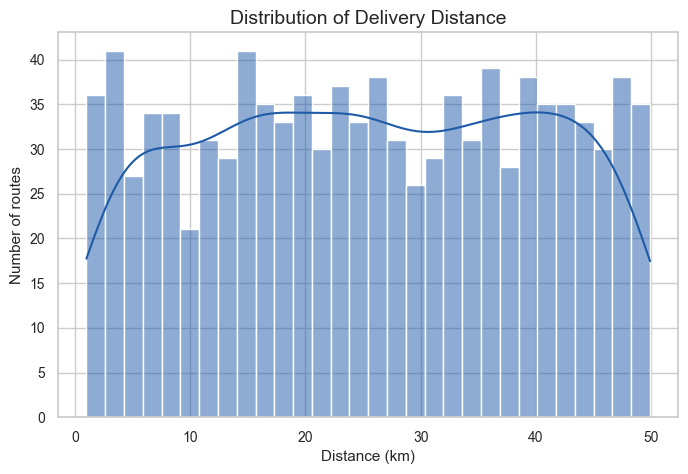

In [161]:
plt.figure(figsize=(8, 5))

sns.histplot(
    route_clean["distance_km"],
    bins=30,
    kde=True,
    color=project_palette["blue"]
)

plt.title("Distribution of Delivery Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of routes")
plt.show()

### Distance observation

The delivery distances are spread between around 1 km and almost 50 km.

The average distance is about 25.6 km, and the median is also close to 25.5 km.  
This shows that the dataset includes a good mix of short, medium and longer delivery routes.

Distance is an important variable because it can affect route time, cost and also CO2 emissions in the next parts of the project.

### Distribution of optimized route time

Here I check the distribution of optimized route time in minutes.

This is one of the key variables of the project because delivery time is an important factor in e-commerce logistics.

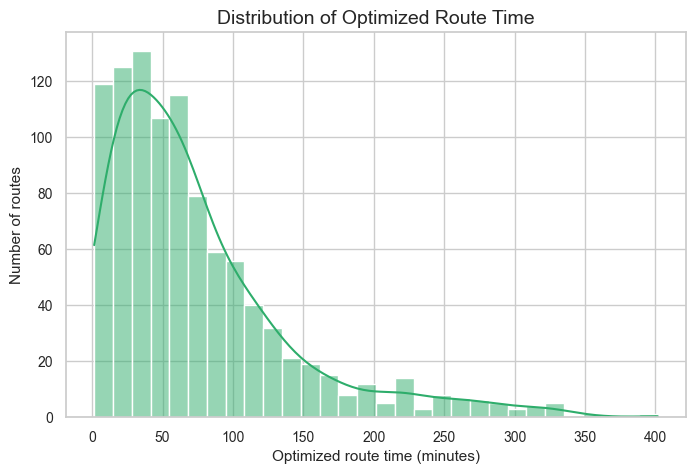

In [162]:
plt.figure(figsize=(8, 5))

sns.histplot(
    route_clean["optimized_route_time_min"],
    bins=30,
    kde=True,
    color=project_palette["green"]
)

plt.title("Distribution of Optimized Route Time")
plt.xlabel("Optimized route time (minutes)")
plt.ylabel("Number of routes")
plt.show()

### Route time observation

Most optimized route times are concentrated in the lower and middle ranges, but there are also some much longer routes.

The average optimized route time is about 74 minutes, while the median is around 56 minutes.  
This means that some long routes increase the average.

This is useful for the project because delivery time is one of the main factors when comparing delivery options.

### Distribution of optimized route cost

In this chart, I explore the distribution of optimized route cost.

Cost is important because a delivery option should not only be fast, but also economically reasonable.

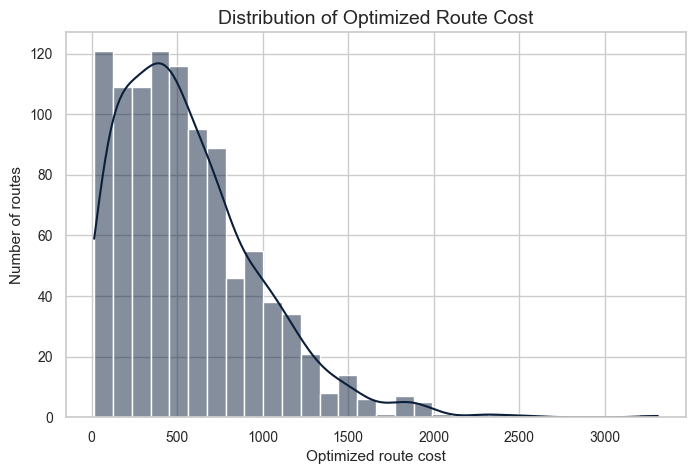

In [163]:
plt.figure(figsize=(8, 5))

sns.histplot(
    route_clean["optimized_route_cost"],
    bins=30,
    kde=True,
    color=project_palette["navy"]
)

plt.title("Distribution of Optimized Route Cost")
plt.xlabel("Optimized route cost")
plt.ylabel("Number of routes")
plt.show()

### Route cost observation

Most optimized route costs are in the lower and middle ranges, but there are some routes with much higher costs.

The average route cost is around 566, while the median is around 482.  
This shows that a few expensive routes increase the average cost.

For this reason, cost should be analysed together with distance and route time, not as an isolated variable.

### Distance vs optimized route time

In this scatter plot, I compare delivery distance with optimized route time.

Usually, longer distances are expected to take more time, but traffic, speed and other factors can also affect the final route time.

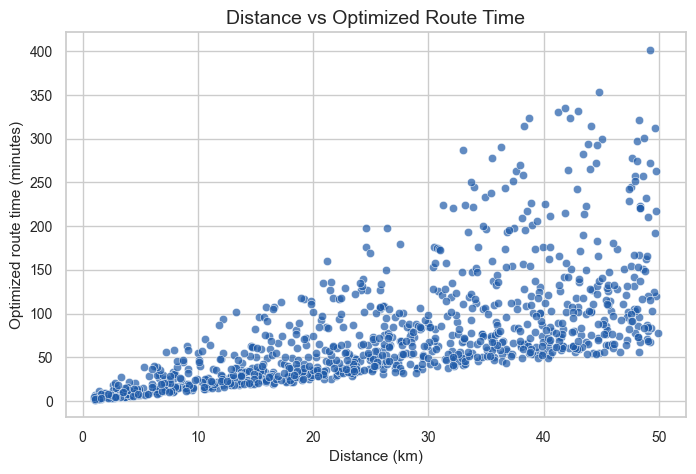

In [164]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=route_clean,
    x="distance_km",
    y="optimized_route_time_min",
    color=project_palette["blue"],
    alpha=0.7
)

plt.title("Distance vs Optimized Route Time")
plt.xlabel("Distance (km)")
plt.ylabel("Optimized route time (minutes)")
plt.show()

### Distance and time observation

The scatter plot shows a positive relationship between delivery distance and optimized route time.

In general, longer routes tend to take more time.  
This is also supported by the correlation between `distance_km` and `optimized_route_time_min`, which is around 0.66.

However, the relationship is not perfect because route time can also be affected by traffic, speed and other operational factors.

### Traffic density vs optimized route time

In this chart, I compare traffic density with optimized route time.

This helps me see whether routes with higher traffic density usually take more time.

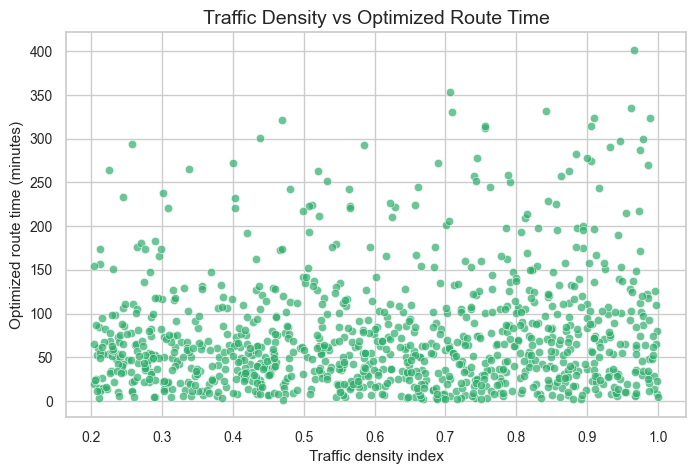

In [165]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=route_clean,
    x="traffic_density_index",
    y="optimized_route_time_min",
    color=project_palette["green"],
    alpha=0.7
)

plt.title("Traffic Density vs Optimized Route Time")
plt.xlabel("Traffic density index")
plt.ylabel("Optimized route time (minutes)")
plt.show()

### Traffic and time observation

The relationship between traffic density and optimized route time is not very strong in this dataset.

The correlation between `traffic_density_index` and `optimized_route_time_min` is around 0.13.  
This means that traffic may have some effect on route time, but it is not the only factor.

Distance and average speed seem to explain route time more clearly in this dataset.

### Route efficiency vs reliability

In this scatter plot, I compare route efficiency with route reliability.

This helps me understand whether more efficient routes also tend to be more reliable.

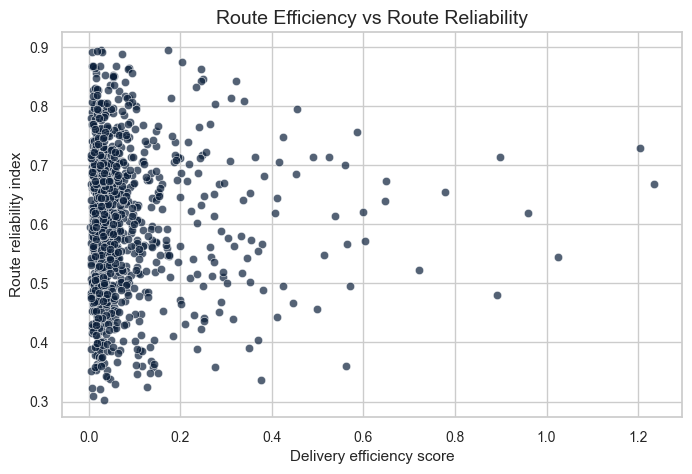

In [166]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=route_clean,
    x="delivery_efficiency_score",
    y="route_reliability_index",
    color=project_palette["navy"],
    alpha=0.7
)

plt.title("Route Efficiency vs Route Reliability")
plt.xlabel("Delivery efficiency score")
plt.ylabel("Route reliability index")
plt.show()

### Efficiency and reliability observation

The scatter plot does not show a strong relationship between route efficiency and route reliability.

The correlation between `delivery_efficiency_score` and `route_reliability_index` is very close to zero.

This means that, in this dataset, a more efficient route is not necessarily more reliable.  
For the next steps, it is better to keep efficiency and reliability as separate criteria.

### Correlation between route planning variables

Finally, I use a correlation heatmap to see the relationships between the main numerical variables.

This helps me identify which variables move together and which ones may be more important for the next analysis steps.

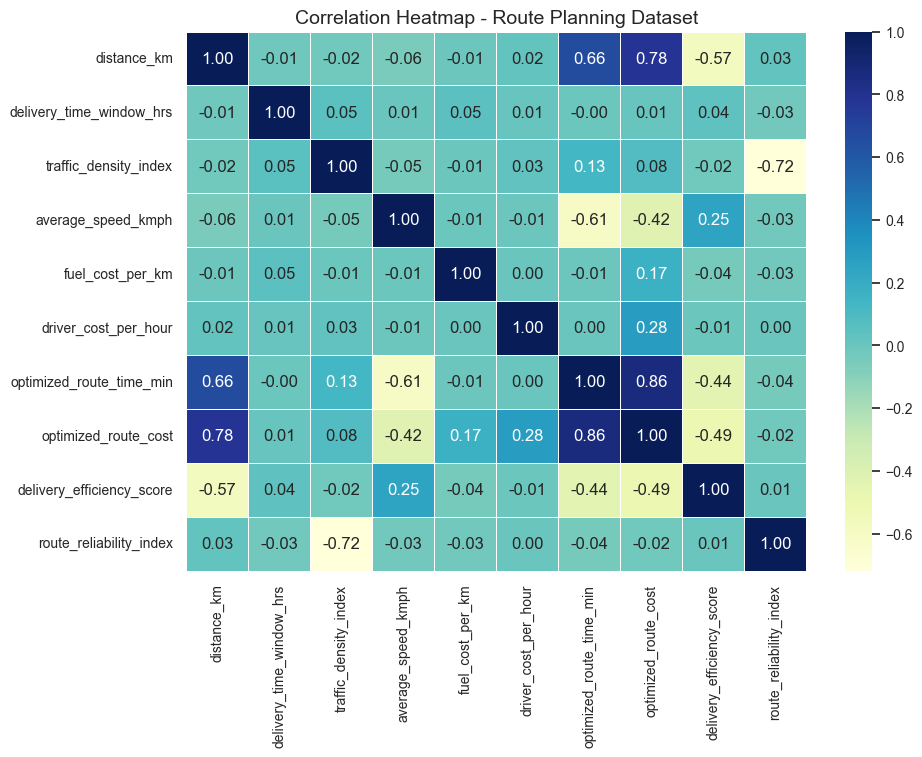

In [167]:
route_corr = route_clean[route_main_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    route_corr,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Route Planning Dataset")
plt.show()

### Correlation observation

The correlation heatmap shows some useful relationships between the main route planning variables.

`distance_km` has a positive correlation with `optimized_route_time_min` and `optimized_route_cost`.  
This means that longer routes usually take more time and cost more.

`optimized_route_time_min` also has a strong positive correlation with `optimized_route_cost`, around 0.86.  
This makes sense because longer delivery times usually increase the total route cost.

Another important point is that `traffic_density_index` has a strong negative correlation with `route_reliability_index`, around -0.72.  
This suggests that routes with higher traffic density are usually less reliable.

These findings will be useful later when I calculate KPIs and build the Delivery Option Score.

### Route planning EDA summary

In this first EDA section, I explored the main operational variables of the route planning dataset.

The analysis shows that distance is clearly related to both route time and route cost.  
Longer routes usually take more time and are more expensive.

The relationship between traffic density and route time is not very strong, but traffic density has a clear negative relationship with route reliability.  
This means that traffic seems to affect reliability more than route duration in this dataset.

Another important point is that route efficiency and route reliability do not have a strong direct relationship.  
For this reason, I will treat them as separate factors in the next steps of the project.

## 3.2 CO2 and Sustainability EDA

In this section, I explore the carbon emissions dataset.

This dataset is important for the sustainability part of the project because it includes information about vehicle type, route type, distance, package weight, traffic conditions and CO2 emissions.

The goal is to understand which factors are related to higher or lower emissions.

### Numerical summary of carbon emissions data

Before creating charts, I first check the main numerical columns of the carbon emissions dataset.

This helps me understand the general range of distance, package weight and CO2 emissions.

In [168]:
carbon_main_columns = [
    "distance_km",
    "package_weight_kg",
    "carbon_emission_kgco2e"
]

carbon_clean[carbon_main_columns].describe()

,distance_km,package_weight_kg,carbon_emission_kgco2e
count,12000.000000,12000.000000,12000.000000
mean,102.851408,396.355458,71.994260
std,163.538763,1064.274964,180.524361
min,1.000000,0.500000,0.000000
25%,11.600000,8.800000,0.093000
50%,37.500000,17.300000,4.150000
75%,114.600000,26.100000,24.091250
max,799.900000,4985.500000,1280.173000


### Carbon data numerical observation

The carbon emissions dataset has 12,000 records.

The average delivery distance is around 103 km, but the median is only 37.5 km.  
This means that many deliveries are short or medium distance, but there are also some very long routes that increase the average.

The same pattern appears in package weight and carbon emissions.  
The median carbon emission is around 4.15 kgCO2e, while the average is about 71.99 kgCO2e. This shows that some deliveries have much higher emissions than the majority.

For this reason, I should not look only at the average.  
It is also important to check the distribution and compare emissions by vehicle type, route type and traffic conditions.

### Distribution of CO2 emissions

In this chart, I check how CO2 emissions are distributed in the dataset.

This is useful because CO2 is one of the main sustainability indicators in the project.

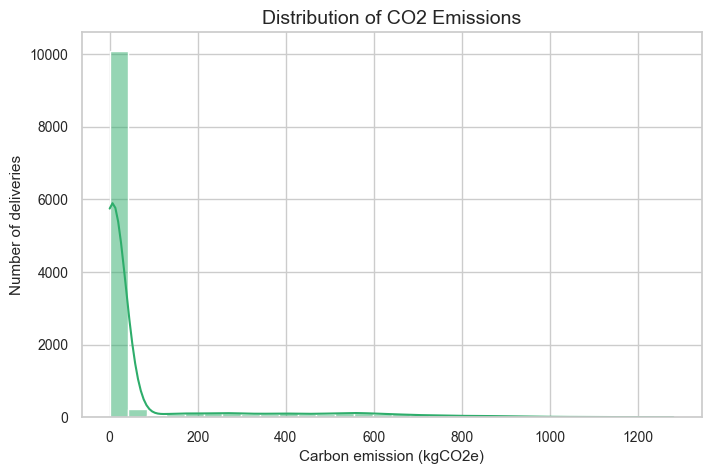

In [169]:
plt.figure(figsize=(8, 5))

sns.histplot(
    carbon_clean["carbon_emission_kgco2e"],
    bins=30,
    kde=True,
    color=project_palette["green"]
)

plt.title("Distribution of CO2 Emissions")
plt.xlabel("Carbon emission (kgCO2e)")
plt.ylabel("Number of deliveries")
plt.show()

### CO2 emissions observation

Most deliveries have relatively low carbon emissions, but there are also some deliveries with much higher emissions.

This matches the numerical summary, where the median emission is much lower than the average.  
So the dataset is not balanced around one typical value; a smaller number of high-emission deliveries increases the average.

This is important for the project because high-emission deliveries can have a strong impact on the sustainability analysis.

### Average CO2 emissions by vehicle type

In this chart, I compare the average CO2 emissions by vehicle type.

This helps me understand which types of vehicles are more or less sustainable in the dataset.

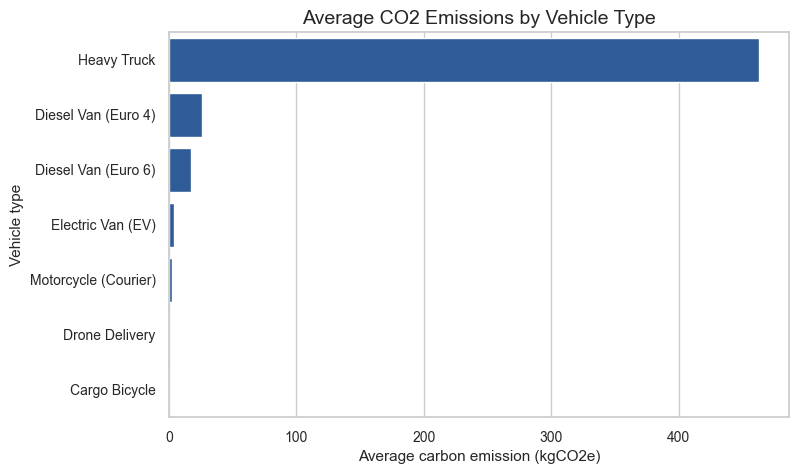

In [170]:
vehicle_emissions = (
    carbon_clean
    .groupby("vehicle_type")["carbon_emission_kgco2e"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=vehicle_emissions,
    x="carbon_emission_kgco2e",
    y="vehicle_type",
    color=project_palette["blue"]
)

plt.title("Average CO2 Emissions by Vehicle Type")
plt.xlabel("Average carbon emission (kgCO2e)")
plt.ylabel("Vehicle type")
plt.show()

### Vehicle type observation

The chart shows a clear difference between vehicle types.

Heavy Truck has the highest average carbon emissions by far, around 463 kgCO2e.  
Diesel vans have lower emissions than heavy trucks, but they are still higher than electric vans, motorcycles, drones and cargo bicycles.

Cargo Bicycle has zero emissions in this dataset, and Drone Delivery also has very low average emissions.

This shows that vehicle type is one of the most important factors in the sustainability part of the project.

### Average CO2 emissions by route type

In this chart, I compare average CO2 emissions by route type.

This helps me see whether some route types are linked to higher emissions than others.

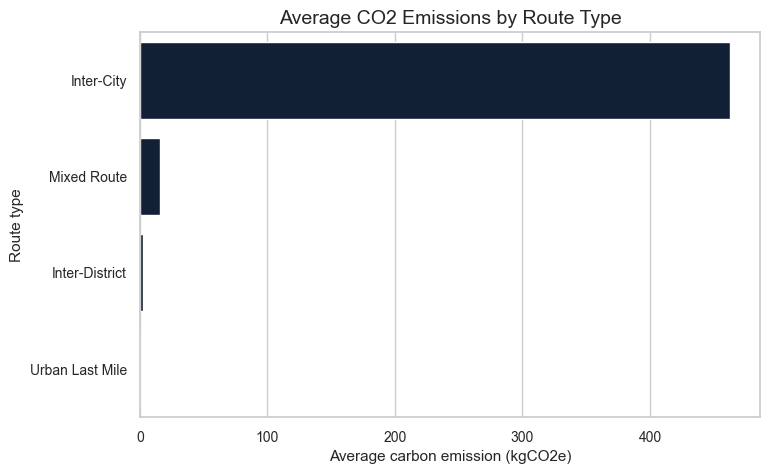

In [171]:
route_type_emissions = (
    carbon_clean
    .groupby("route_type")["carbon_emission_kgco2e"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=route_type_emissions,
    x="carbon_emission_kgco2e",
    y="route_type",
    color=project_palette["navy"]
)

plt.title("Average CO2 Emissions by Route Type")
plt.xlabel("Average carbon emission (kgCO2e)")
plt.ylabel("Route type")
plt.show()

### Route type observation

The chart shows that route type has a strong effect on average carbon emissions.

Inter-City routes have the highest average emissions by far, around 463 kgCO2e.  
Mixed Route has much lower emissions, while Inter-District and Urban Last Mile routes have very low average emissions.

This makes sense because longer routes usually need more distance, heavier transport or more fuel consumption.

For this project, this means that route type should be considered as an important sustainability factor.

### Average CO2 emissions by traffic conditions

In this chart, I compare average CO2 emissions under different traffic conditions.

This helps me understand whether traffic conditions are related to higher emissions.

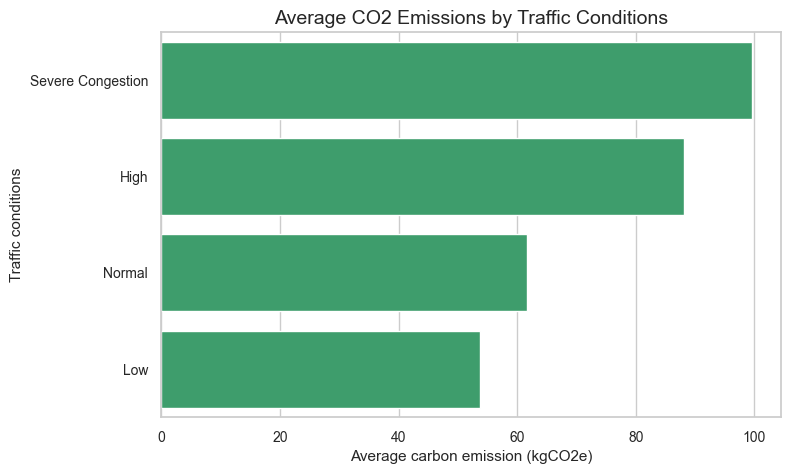

In [172]:
traffic_emissions = (
    carbon_clean
    .groupby("traffic_conditions")["carbon_emission_kgco2e"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=traffic_emissions,
    x="carbon_emission_kgco2e",
    y="traffic_conditions",
    color=project_palette["green"]
)

plt.title("Average CO2 Emissions by Traffic Conditions")
plt.xlabel("Average carbon emission (kgCO2e)")
plt.ylabel("Traffic conditions")
plt.show()

### Traffic conditions observation

The chart shows that average carbon emissions increase when traffic conditions get worse.

Severe Congestion has the highest average emissions, followed by High traffic conditions.  
Normal and Low traffic conditions have lower average emissions.

This suggests that traffic conditions can affect sustainability, not only delivery time.  
When traffic is worse, vehicles may spend more time on the road or operate less efficiently, which can increase emissions.

### Eco-friendly deliveries

In this chart, I check the number of eco-friendly and non-eco-friendly deliveries.

This gives a simple overview of how many deliveries are marked as more sustainable in the dataset.

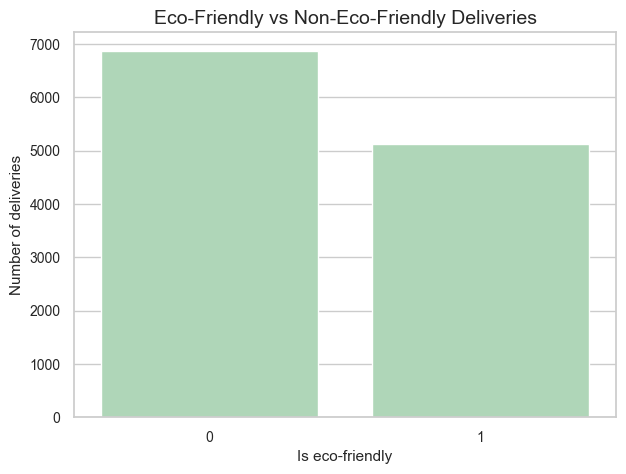

In [173]:
eco_counts = carbon_clean["is_eco_friendly"].value_counts().reset_index()
eco_counts.columns = ["is_eco_friendly", "count"]

plt.figure(figsize=(7, 5))

sns.barplot(
    data=eco_counts,
    x="is_eco_friendly",
    y="count",
    color=project_palette["light_green"]
)

plt.title("Eco-Friendly vs Non-Eco-Friendly Deliveries")
plt.xlabel("Is eco-friendly")
plt.ylabel("Number of deliveries")
plt.show()

### Eco-friendly deliveries observation

The dataset has more non-eco-friendly deliveries than eco-friendly ones.

There are 6,876 non-eco-friendly deliveries and 5,124 eco-friendly deliveries.  
So the difference is not extreme, but non-eco-friendly deliveries are still the majority.

This column is useful as a simple sustainability label, but I will not use it alone.  
For a better analysis, I also need to look at actual carbon emissions, vehicle type, route type and traffic conditions.

### Distance vs CO2 emissions

In this scatter plot, I compare delivery distance with CO2 emissions.

Normally, longer distances are expected to produce more emissions, but vehicle type, package weight and traffic conditions can also affect the result.

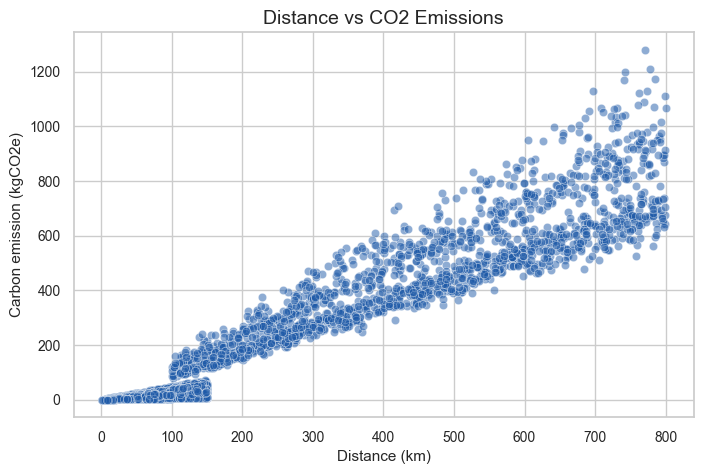

In [174]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=carbon_clean,
    x="distance_km",
    y="carbon_emission_kgco2e",
    color=project_palette["blue"],
    alpha=0.5
)

plt.title("Distance vs CO2 Emissions")
plt.xlabel("Distance (km)")
plt.ylabel("Carbon emission (kgCO2e)")
plt.show()

### Distance and CO2 observation

The scatter plot shows a strong positive relationship between delivery distance and carbon emissions.

In general, longer distances are linked to higher emissions.  
This is also confirmed by the correlation heatmap, where the correlation between `distance_km` and `carbon_emission_kgco2e` is around 0.95.

This means that distance is one of the most important variables for the sustainability analysis.

### Correlation between carbon emissions variables

Finally, I use a correlation heatmap to check the relationship between the main numerical variables in the carbon emissions dataset.

This helps me see how distance, package weight and CO2 emissions are related.

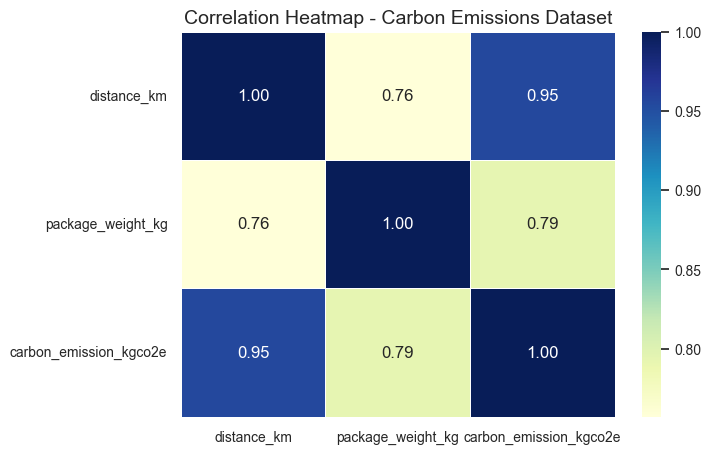

In [175]:
carbon_corr = carbon_clean[carbon_main_columns].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    carbon_corr,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Carbon Emissions Dataset")
plt.show()

### Carbon correlation observation

The correlation heatmap shows strong relationships between the main numerical variables.

`distance_km` has a very strong positive correlation with `carbon_emission_kgco2e`, around 0.95.  
This means that longer deliveries usually create higher emissions.

`package_weight_kg` also has a strong positive correlation with carbon emissions, around 0.79.  
This suggests that heavier packages are also linked to higher emissions.

There is also a positive relationship between distance and package weight, around 0.76.  
This may mean that longer routes in this dataset are often connected with heavier deliveries.

These findings show that distance and package weight are both important for defining sustainability KPIs.

### CO2 and sustainability EDA summary

In this section, I explored the sustainability side of the project using the carbon emissions dataset.

The analysis shows that carbon emissions are not evenly distributed.  
Most deliveries have relatively low emissions, but some deliveries have much higher emissions and increase the average.

Vehicle type and route type are very important.  
Heavy Truck and Inter-City routes have the highest average emissions by far.

Traffic conditions also matter.  
Deliveries under Severe Congestion and High traffic conditions have higher average emissions than deliveries under Normal or Low traffic conditions.

The correlation analysis shows that distance has the strongest relationship with carbon emissions, followed by package weight.

These findings will be useful later when I create sustainability KPIs and include CO2 emissions in the Delivery Option Score.

## 3.3 Tracking and Reliability EDA

In this section, I explore the tracking dataset.

This dataset is useful for understanding delivery reliability because it includes information about planned ETA, actual ETA, delays, on-time delivery, transportation distance and vehicle type.

The goal of this section is to understand how many deliveries were on time, how many were delayed, and how distance or vehicle type may be related to delivery performance.

### Basic summary of tracking data

Before creating charts, I first check the basic structure of the cleaned tracking dataset.

This helps me confirm how many records are available and which columns are useful for the reliability analysis.

In [176]:
print("Tracking clean shape:", tracking_clean.shape)

print("\nColumns:")
print(tracking_clean.columns.tolist())

print("\nMissing values:")
display(tracking_clean.isna().sum())

display(tracking_clean.head())

Tracking clean shape: (6877, 13)

Columns:
['bookingid', 'origin_location', 'destination_location', 'planned_eta', 'actual_eta', 'ontime', 'delay', 'trip_start_date', 'trip_end_date', 'transportation_distance_in_km', 'vehicletype', 'is_on_time', 'is_delayed']

Missing values:


bookingid                           0
origin_location                     0
destination_location                0
planned_eta                         0
actual_eta                         37
ontime                           4329
delay                            2538
trip_start_date                     0
trip_end_date                     194
transportation_distance_in_km     712
vehicletype                         0
is_on_time                          0
is_delayed                          0
dtype: int64

,bookingid,origin_location,destination_location,planned_eta,actual_eta,ontime,delay,trip_start_date,trip_end_date,transportation_distance_in_km,vehicletype,is_on_time,is_delayed
0,MVCV0000927/082021,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA",2020-08-21 18:59:01.000,2020-08-28 14:38:04.447,NaN,R,2020-08-17 14:59:01,NaT,320.0,32 FT Single-Axle 7MT - HCV,0,1
1,VCV00014271/082021,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-08-31 20:22:22.827,2020-08-28 12:46:17.007,G,NaN,2020-08-27 16:21:52,NaT,103.0,32 FT Multi-Axle 14MT - HCV,1,0
2,VCV00014382/082021,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-08-31 21:59:24.987,2020-08-28 16:03:30.793,G,NaN,2020-08-27 17:57:04,NaT,300.0,1 MT Tata Ace (Open Body),1,0
3,VCV00014743/082021,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-09-01 04:48:24.503,2020-08-28 12:50:27.997,G,NaN,2020-08-28 00:47:45,NaT,61.0,32 FT Multi-Axle 14MT - HCV,1,0
4,VCV00014744/082021,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-09-01 05:23:19.243,2020-08-28 14:22:50.127,G,NaN,2020-08-28 01:13:48,NaT,240.0,32 FT Multi-Axle 14MT - HCV,1,0


### Tracking data initial observation

The cleaned tracking dataset has 6,877 records and 13 columns.

It keeps only the columns that are useful for this project, such as planned ETA, actual ETA, delay, on-time delivery, transportation distance and vehicle type.

Some missing values still exist, especially in `ontime`, `delay`, `trip_end_date` and `transportation_distance_in_km`.  
I do not remove all of them because some columns were already transformed into useful indicator columns such as `is_on_time` and `is_delayed`.

For the distance analysis, I only use the records where transportation distance is available.

### On-time delivery count

In this chart, I check how many deliveries are marked as on-time and not on-time.

This is useful because on-time delivery is one of the most important indicators of reliability in logistics.

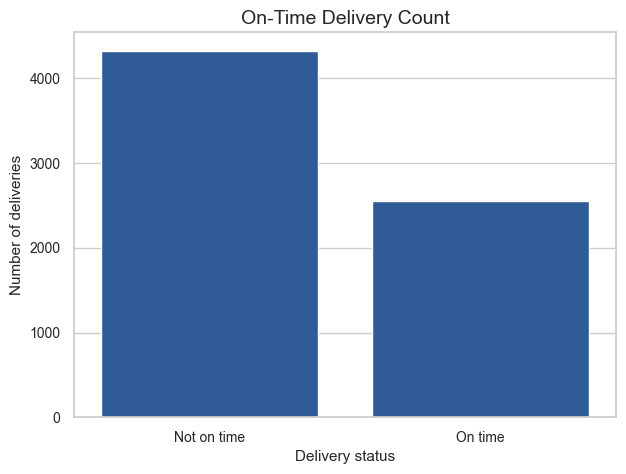

In [177]:
on_time_counts = tracking_clean["is_on_time"].value_counts().reset_index()
on_time_counts.columns = ["is_on_time", "count"]

on_time_counts["status"] = on_time_counts["is_on_time"].map({
    1: "On time",
    0: "Not on time"
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=on_time_counts,
    x="status",
    y="count",
    color=project_palette["blue"]
)

plt.title("On-Time Delivery Count")
plt.xlabel("Delivery status")
plt.ylabel("Number of deliveries")
plt.show()

### On-time delivery observation

The chart shows that most deliveries are not marked as on-time.

There are 2,548 on-time deliveries and 4,329 not-on-time deliveries.  
This means that only around 37.05% of the records are marked as on-time.

This is an important finding for the reliability part of the project because on-time delivery will be one of the main KPIs.

### Delayed delivery count

In this chart, I check how many deliveries are marked as delayed.

This helps me understand the delay situation in the tracking dataset.

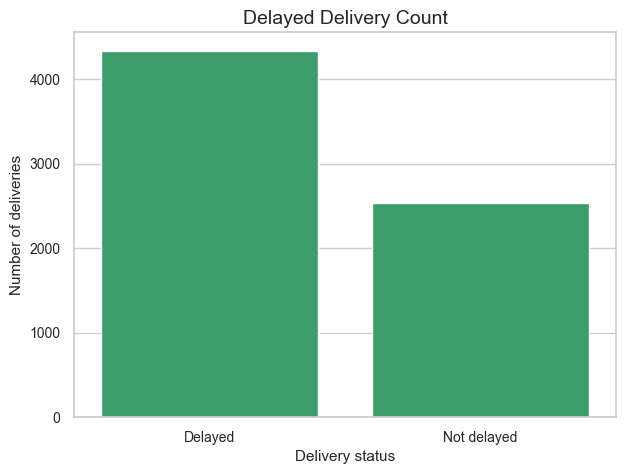

In [178]:
delay_counts = tracking_clean["is_delayed"].value_counts().reset_index()
delay_counts.columns = ["is_delayed", "count"]

delay_counts["status"] = delay_counts["is_delayed"].map({
    1: "Delayed",
    0: "Not delayed"
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=delay_counts,
    x="status",
    y="count",
    color=project_palette["green"]
)

plt.title("Delayed Delivery Count")
plt.xlabel("Delivery status")
plt.ylabel("Number of deliveries")
plt.show()

### Delayed delivery observation

The chart shows that delayed deliveries are the majority in this dataset.

There are 4,339 delayed deliveries and 2,538 not-delayed deliveries.  
This gives a delay rate of around 63.09%.

This confirms that delivery reliability is an important issue in this dataset and should be included in the KPI section.

### Vehicle type distribution

The tracking dataset has many vehicle type categories, and some of their names are very long.

To keep the main chart readable, I group the most common vehicle types as the top 10 categories and combine the rest into `Other`.

I also create a treemap after this chart to show more vehicle type categories in a more visual way.

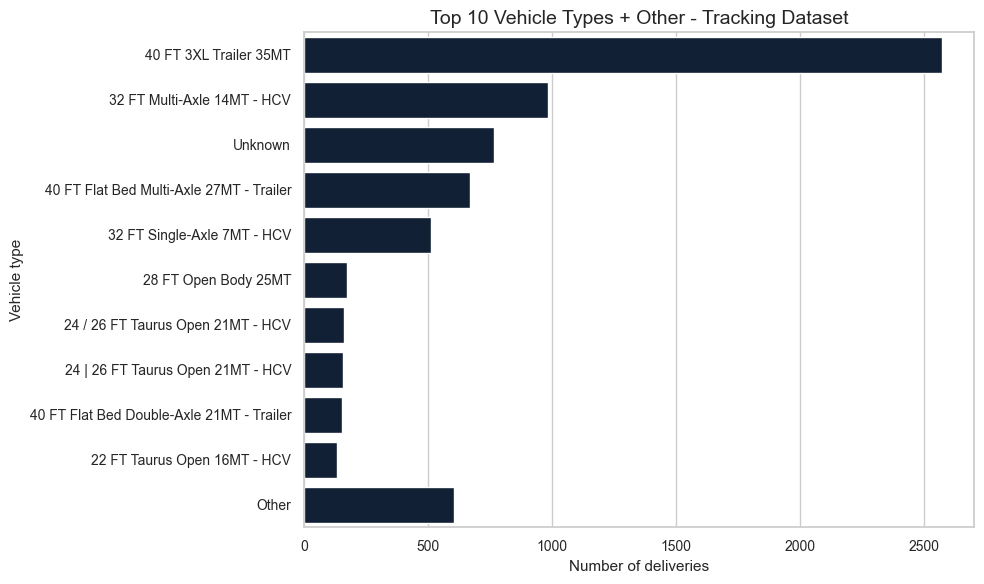

In [179]:
vehicle_counts = tracking_clean["vehicletype"].value_counts()

top_n = 10

top_vehicle_counts = vehicle_counts.head(top_n)
other_count = vehicle_counts.iloc[top_n:].sum()

vehicle_counts_grouped = pd.concat([
    top_vehicle_counts,
    pd.Series({"Other": other_count})
]).reset_index()

vehicle_counts_grouped.columns = ["vehicletype", "count"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=vehicle_counts_grouped,
    x="count",
    y="vehicletype",
    color=project_palette["navy"]
)

plt.title("Top 10 Vehicle Types + Other - Tracking Dataset")
plt.xlabel("Number of deliveries")
plt.ylabel("Vehicle type")

plt.tight_layout()
plt.show()

### Vehicle type tracking observation

The chart shows that the tracking dataset is highly concentrated around a few vehicle types.

The most common vehicle type is `40 FT 3XL Trailer 35MT`, with 2,574 records.  
The next most frequent categories are `32 FT Multi-Axle 14MT - HCV`, `Unknown`, and `40 FT Flat Bed Multi-Axle 27MT - Trailer`.

I grouped the less frequent vehicle types into `Other` to keep the chart readable.  
This is useful because the original dataset contains many vehicle type categories with long names.

The presence of `Unknown` also shows that some records did not have a clear vehicle type in the original data.

### Vehicle type treemap

To show more vehicle type categories without making the chart too crowded, I use a treemap.

In a treemap, each rectangle represents a vehicle type, and the size of the rectangle shows how many deliveries belong to that type.

For readability, I use the top 30 vehicle types in this chart.

In [180]:
if "tracking_clean" in globals():
    tracking_treemap_df = tracking_clean.copy()
else:
    tracking_treemap_df = tracking_df.copy()
    tracking_treemap_df = clean_column_names(tracking_treemap_df)

# Fill missing vehicle types
tracking_treemap_df["vehicletype"] = (
    tracking_treemap_df["vehicletype"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

tracking_treemap_df.loc[
    tracking_treemap_df["vehicletype"] == "",
    "vehicletype"
] = "Unknown"

# Prepare the top 30 vehicle categories
top_vehicle_treemap = (
    tracking_treemap_df["vehicletype"]
    .value_counts()
    .head(30)
    .reset_index()
)

top_vehicle_treemap.columns = ["vehicletype", "count"]

# Create treemap
fig = px.treemap(
    top_vehicle_treemap,
    path=["vehicletype"],
    values="count",
    title="Vehicle Type Treemap - Top 30 Vehicle Categories",
    color="count",
    color_continuous_scale=[
        project_palette["light_green"],
        project_palette["green"],
        project_palette["navy"]
    ]
)

fig.update_layout(
    width=1100,
    height=550,
    margin=dict(t=50, l=25, r=25, b=25),
    font=dict(size=12)
)

fig.show()

### Vehicle type treemap observation

The treemap shows the top 30 vehicle type categories in a compact way.

The largest category is `40 FT 3XL Trailer 35MT`, which has the highest number of delivery records in this dataset.  
Other important categories include `32 FT Multi-Axle 14MT - HCV`, `Unknown`, and `40 FT Flat Bed Multi-Axle 27MT - Trailer`.

The `Unknown` category is also visible in the treemap, which means that some records did not have a clear vehicle type in the original data.

This chart is useful because it shows more vehicle type detail than the top 10 bar chart, while still keeping the visualization readable.

### Distribution of transportation distance

In this chart, I check how transportation distances are distributed in the tracking dataset.

I also add the mean and median lines to better understand whether the distribution is balanced or affected by long-distance deliveries.

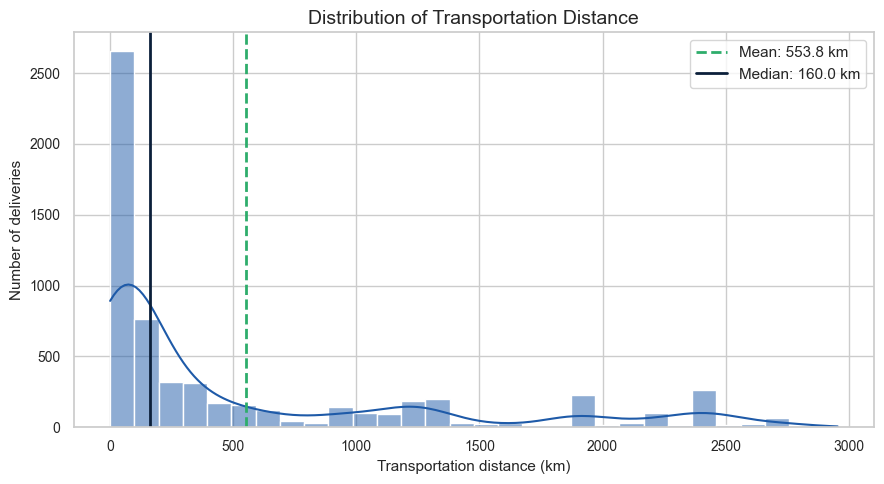

In [181]:
distance_data = tracking_clean["transportation_distance_in_km"].dropna()

mean_distance = distance_data.mean()
median_distance = distance_data.median()

plt.figure(figsize=(9, 5))

sns.histplot(
    distance_data,
    bins=30,
    kde=True,
    color=project_palette["blue"]
)

plt.axvline(
    mean_distance,
    color=project_palette["green"],
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_distance:.1f} km"
)

plt.axvline(
    median_distance,
    color=project_palette["navy"],
    linestyle="-",
    linewidth=2,
    label=f"Median: {median_distance:.1f} km"
)

plt.title("Distribution of Transportation Distance")
plt.xlabel("Transportation distance (km)")
plt.ylabel("Number of deliveries")
plt.legend()

plt.tight_layout()
plt.show()

### Transportation distance observation

The chart shows that transportation distance is not evenly distributed.

The median distance is around 160 km, while the average is much higher, around 553.8 km.  
This means that some very long-distance deliveries increase the average.

The maximum transportation distance is around 2,954.7 km, so the dataset includes some long-haul deliveries.

For this reason, it is important to look at both the mean and the median when analysing transportation distance.

### Transportation distance by delivery status

In this chart, I compare transportation distance between on-time and not-on-time deliveries.

I use a boxplot because it shows more information than only the average.  
It helps me see the median, spread and possible long-distance outliers for each delivery status.

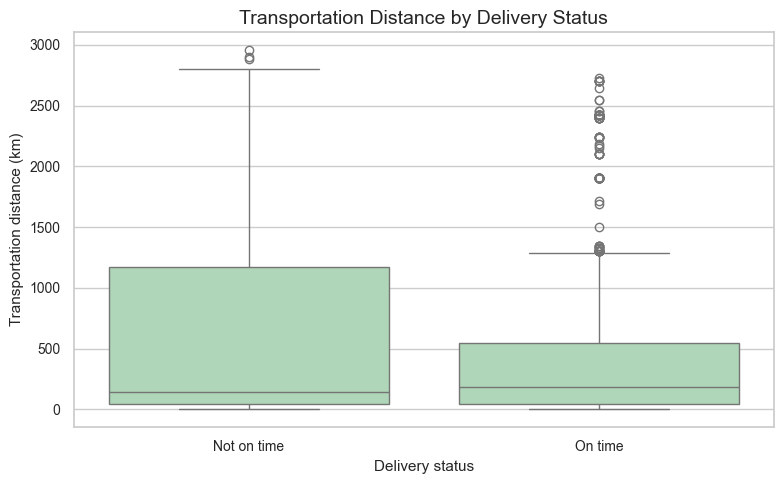

In [182]:
distance_status_data = tracking_clean.dropna(
    subset=["transportation_distance_in_km"]
).copy()

distance_status_data["delivery_status"] = distance_status_data["is_on_time"].map({
    1: "On time",
    0: "Not on time"
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=distance_status_data,
    x="delivery_status",
    y="transportation_distance_in_km",
    color=project_palette["light_green"]
)

plt.title("Transportation Distance by Delivery Status")
plt.xlabel("Delivery status")
plt.ylabel("Transportation distance (km)")

plt.tight_layout()
plt.show()

### Distance by delivery status observation

The boxplot compares transportation distance for on-time and not-on-time deliveries.

Not-on-time deliveries have a higher average distance, around 613 km, compared with around 429 km for on-time deliveries.  
This suggests that longer distances may increase the risk of not being on time.

However, the median distance is not higher for not-on-time deliveries.  
The median is around 145 km for not-on-time deliveries and around 180 km for on-time deliveries.

This means that the difference is mainly influenced by long-distance records and outliers.  
So distance may be related to reliability, but it should not be interpreted alone.

### Reliability indicators summary

In this step, I calculate simple reliability indicators from the tracking dataset.

These values give a first overview of on-time and delayed deliveries before building the final KPI section.

In [183]:
total_tracking_deliveries = len(tracking_clean)

on_time_deliveries = tracking_clean["is_on_time"].sum()
delayed_deliveries = tracking_clean["is_delayed"].sum()

on_time_rate = on_time_deliveries / total_tracking_deliveries * 100
delay_rate = delayed_deliveries / total_tracking_deliveries * 100

tracking_reliability_summary = pd.DataFrame({
    "metric": [
        "Total deliveries",
        "On-time deliveries",
        "Delayed deliveries",
        "On-time delivery rate (%)",
        "Delay rate (%)"
    ],
    "value": [
        total_tracking_deliveries,
        on_time_deliveries,
        delayed_deliveries,
        round(on_time_rate, 2),
        round(delay_rate, 2)
    ]
})

tracking_reliability_summary

,metric,value
0,Total deliveries,6877.00
1,On-time deliveries,2548.00
2,Delayed deliveries,4339.00
3,On-time delivery rate (%),37.05
4,Delay rate (%),63.09


### Reliability summary observation

The reliability summary shows that the dataset has 6,877 delivery records.

There are 2,548 on-time deliveries and 4,339 delayed deliveries.  
The on-time delivery rate is around 37.05%, while the delay rate is around 63.09%.

This means that delays are more common than on-time deliveries in this dataset.

These indicators will be useful later in the KPI calculation section, especially for comparing delivery performance and reliability.

### Tracking and reliability EDA summary

In this section, I explored the tracking dataset from a reliability perspective.

The dataset shows that delayed deliveries are more common than on-time deliveries.  
The on-time delivery rate is around 37.05%, while the delay rate is around 63.09%.

For vehicle types, I used a top 10 + Other bar chart and a treemap because the original list had many long category names.  
The most common vehicle type is `40 FT 3XL Trailer 35MT`, and there is also a visible `Unknown` category.

For transportation distance, the distribution shows that some long-distance deliveries increase the average distance.  
The boxplot also suggests that not-on-time deliveries have a higher average distance, but the difference is influenced by long-distance records and outliers.

The main outputs from this section will be useful later when I calculate KPIs such as On-Time Delivery Rate and Delay Rate.

## 3.4 Barcelona TRAMS Traffic Context

In this section, I explore the Barcelona TRAMS traffic data.

This dataset is not used as the main route planning dataset.  
I use it as real urban traffic context to understand traffic patterns in Barcelona from January to June 2026.

The goal is to analyse traffic status by month and hour, and to see how actual and predicted traffic status are distributed.

### Basic summary of TRAMS data

Before creating charts, I first check the cleaned TRAMS dataset and the summary table created during the cleaning step.

The original TRAMS dataset is very large, so I mainly use the summarized version for visualization.

In [184]:
print("TRAMS clean shape:", trams_clean.shape)
print("TRAMS summary shape:", trams_summary.shape)

print("\nTRAMS clean columns:")
print(trams_clean.columns.tolist())

print("\nTRAMS summary columns:")
print(trams_summary.columns.tolist())

display(trams_clean.head())
display(trams_summary.head())

TRAMS clean shape: (11661440, 10)
TRAMS summary shape: (1008, 4)

TRAMS clean columns:
['idtram', 'data', 'estatactual', 'estatprevist', 'source_file', 'datetime', 'date', 'month', 'day', 'hour']

TRAMS summary columns:
['month', 'hour', 'estatactual', 'records']


,idtram,data,estatactual,estatprevist,source_file,datetime,date,month,day,hour
0,1,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
1,2,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
2,3,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
3,4,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0
4,5,20260101001143,0,0,/Users/naktasamipoor/Documents/1-work/business...,2026-01-01 00:11:43,2026-01-01,1,1,0


,month,hour,estatactual,records
0,1,0,0,56731
1,1,0,1,24486
2,1,0,2,6071
3,1,0,3,600
4,1,0,4,248


### TRAMS data initial observation

The TRAMS dataset is much larger than the other datasets in this project.

For this reason, I use the summarized table `trams_summary` for most visualizations instead of using all rows directly.

This keeps the notebook lighter and makes the charts easier to create and understand.

### Prepare traffic status labels

The TRAMS dataset uses numeric codes for actual and predicted traffic status.

In this version, I map the traffic status codes to readable labels:

- `0`: No data
- `1`: Very fluid
- `2`: Fluid
- `3`: Dense
- `4`: Very dense
- `5`: Congestion
- `6`: Section closed

For the main traffic insights, I also create a valid TRAMS subset that excludes `Status 0` because it represents missing traffic information, not a real traffic condition.


In [185]:
traffic_status_map = {
    0: "No data",
    1: "Very fluid",
    2: "Fluid",
    3: "Dense",
    4: "Very dense",
    5: "Congestion",
    6: "Section closed"
}

trams_clean["actual_status_label"] = trams_clean["estatactual"].map(traffic_status_map)
trams_clean["predicted_status_label"] = trams_clean["estatprevist"].map(traffic_status_map)

trams_summary["actual_status_label"] = trams_summary["estatactual"].map(traffic_status_map)

# Valid traffic records exclude Status 0, because 0 means "No data"
trams_valid = trams_clean[trams_clean["estatactual"] != 0].copy()
trams_valid_prediction = trams_clean[
    (trams_clean["estatactual"] != 0) &
    (trams_clean["estatprevist"] != 0)
].copy()

trams_clean[[
    "estatactual",
    "actual_status_label",
    "estatprevist",
    "predicted_status_label"
]].head()


,estatactual,actual_status_label,estatprevist,predicted_status_label
0,0,No data,0,No data
1,0,No data,0,No data
2,0,No data,0,No data
3,0,No data,0,No data
4,0,No data,0,No data


### Actual traffic status distribution

In this chart, I check how often each actual traffic status appears in the TRAMS dataset.

This helps me understand the general traffic situation recorded in Barcelona.

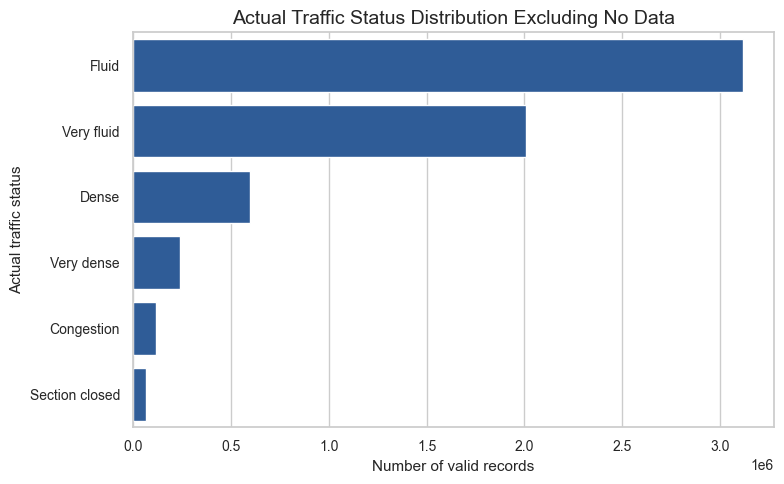

In [186]:
traffic_status_counts = (
    trams_valid["actual_status_label"]
    .value_counts()
    .reset_index()
)

traffic_status_counts.columns = ["traffic_status", "count"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=traffic_status_counts,
    x="count",
    y="traffic_status",
    color=project_palette["blue"]
)

plt.title("Actual Traffic Status Distribution Excluding No Data")
plt.xlabel("Number of valid records")
plt.ylabel("Actual traffic status")

plt.tight_layout()
plt.show()


### Actual traffic status observation

After excluding `No data` records, the valid traffic status distribution is mainly concentrated in the `Fluid` and `Very fluid` categories.

This is a more accurate interpretation than using `Status 0`, because `0` does not represent a real traffic condition.  
For the final presentation, I use the valid traffic subset to describe Barcelona traffic patterns.

The key point is that the TRAMS dataset provides a real urban traffic context, but missing/no-data records need to be handled carefully.


### Traffic records by month

In this chart, I check how many TRAMS records are available for each month.

This helps me see whether the data is balanced across the period from January to June 2026.

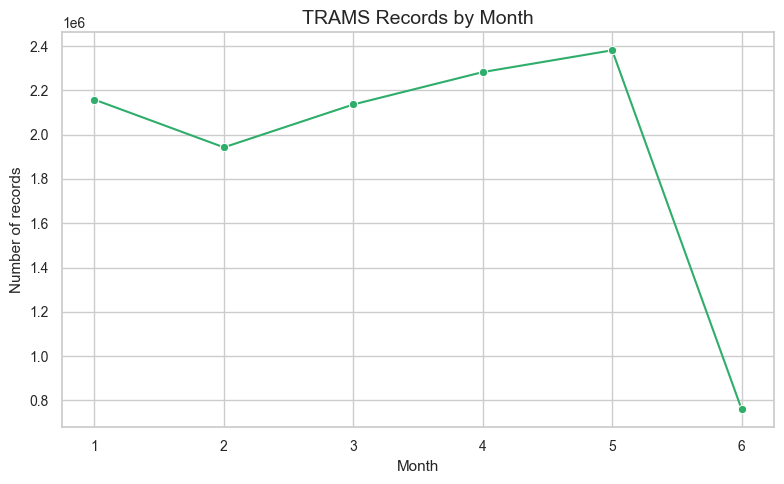

In [187]:
monthly_trams_records = (
    trams_clean
    .groupby("month")
    .size()
    .reset_index(name="records")
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=monthly_trams_records,
    x="month",
    y="records",
    marker="o",
    color=project_palette["green"]
)

plt.title("TRAMS Records by Month")
plt.xlabel("Month")
plt.ylabel("Number of records")

plt.xticks(monthly_trams_records["month"])

plt.tight_layout()
plt.show()

### Monthly TRAMS records observation

The number of TRAMS records is not exactly the same across all months.

May has the highest number of records, followed by April and January.  
June has the lowest number of records because the available June dataset is smaller than the other months.

This is important because monthly comparisons should be interpreted carefully.  
A lower number of records in June does not necessarily mean less traffic; it may simply reflect that less data is available for that month.

### Traffic records by hour

In this chart, I check how TRAMS records are distributed across the hours of the day.

This can help identify whether some hours have more traffic records than others.

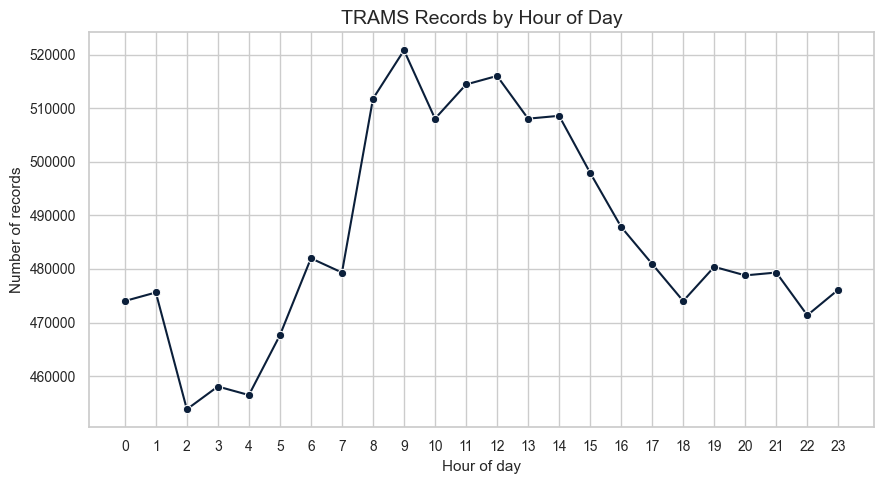

In [188]:
hourly_trams_records = (
    trams_clean
    .groupby("hour")
    .size()
    .reset_index(name="records")
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=hourly_trams_records,
    x="hour",
    y="records",
    marker="o",
    color=project_palette["navy"]
)

plt.title("TRAMS Records by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Number of records")

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

### Hourly TRAMS records observation

The number of TRAMS records is relatively stable across the hours of the day.

Some hours, such as 9, 11 and 12, have slightly higher record counts, while early morning hours such as 2, 3 and 4 have lower counts.

The differences are not extreme, but the chart gives a useful first view of how the traffic records are distributed during the day.

### Traffic status by hour

In this heatmap, I compare actual traffic status across different hours of the day.

This chart is useful because it shows traffic patterns in a compact way.

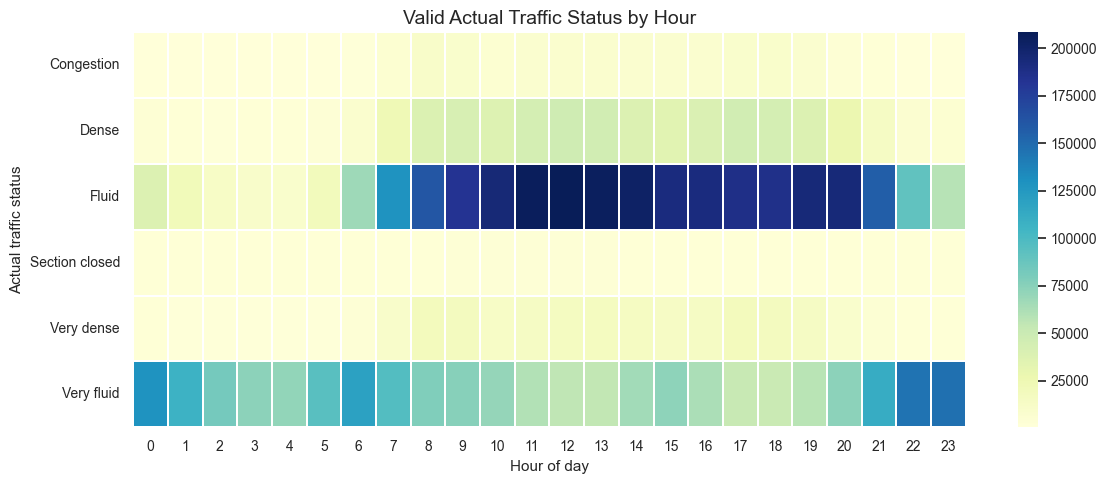

In [189]:
traffic_hour_status = (
    trams_valid
    .groupby(["hour", "actual_status_label"])
    .size()
    .reset_index(name="records")
)

traffic_hour_pivot = traffic_hour_status.pivot(
    index="actual_status_label",
    columns="hour",
    values="records"
).fillna(0)

plt.figure(figsize=(12, 5))

sns.heatmap(
    traffic_hour_pivot,
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Valid Actual Traffic Status by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Actual traffic status")

plt.tight_layout()
plt.show()


### Traffic status by hour observation

The heatmap shows the distribution of valid traffic statuses across the hours of the day.

By excluding `No data`, the chart focuses only on meaningful traffic conditions such as `Very fluid`, `Fluid`, `Dense`, `Very dense` and `Congestion`.

This makes the Barcelona traffic context more reliable for the project storytelling.


### Actual vs predicted traffic status

In this chart, I compare the distribution of actual traffic status and predicted traffic status.

This helps me understand whether the predicted traffic status follows a similar pattern to the actual recorded status.

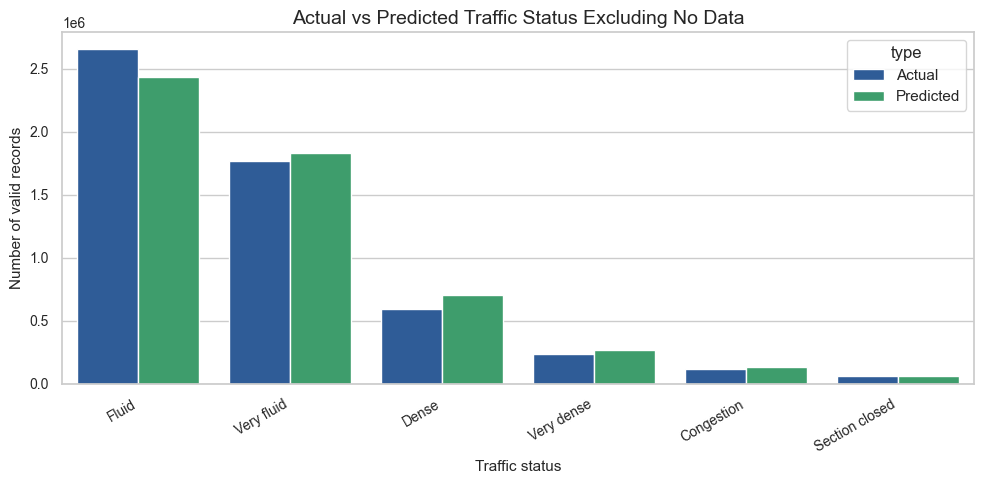

In [190]:
actual_status_counts = (
    trams_valid_prediction["actual_status_label"]
    .value_counts()
    .reset_index()
)

actual_status_counts.columns = ["traffic_status", "count"]
actual_status_counts["type"] = "Actual"

predicted_status_counts = (
    trams_valid_prediction["predicted_status_label"]
    .value_counts()
    .reset_index()
)

predicted_status_counts.columns = ["traffic_status", "count"]
predicted_status_counts["type"] = "Predicted"

actual_predicted_status = pd.concat(
    [actual_status_counts, predicted_status_counts],
    ignore_index=True
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=actual_predicted_status,
    x="traffic_status",
    y="count",
    hue="type",
    palette=[project_palette["blue"], project_palette["green"]]
)

plt.title("Actual vs Predicted Traffic Status Excluding No Data")
plt.xlabel("Traffic status")
plt.ylabel("Number of valid records")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


### Actual vs predicted traffic status observation

After excluding `No data`, the actual and predicted traffic status distributions still follow a similar general pattern.

This comparison is more useful for interpretation because it focuses on real traffic conditions instead of missing information.

The prediction is not perfect, but it gives a reasonable city-level view of expected traffic status.


### Barcelona TRAMS traffic context summary

In this section, I used the Barcelona TRAMS dataset as real urban traffic context.

The dataset is much larger than the other datasets, so I used summarized views to keep the analysis clear and readable.

A key cleaning decision was to separate `No data` records from valid traffic records.  
This avoids treating missing traffic information as if it were a real traffic condition.

The valid traffic analysis shows that most meaningful records are concentrated in the `Fluid` and `Very fluid` categories, with a smaller but important share of `Dense`, `Very dense` and `Congestion` statuses.

This part of the project helps connect the logistics analysis with a real urban traffic context in Barcelona.


# 4. KPI Calculation and KPI Dashboard

In this section, I calculate the main KPIs of the project.

The goal is to move from exploratory analysis to a more structured view of performance.  
I use KPIs to summarize the most important parts of the project: route performance, cost, sustainability, reliability and Barcelona traffic context.

I use three types of outputs:

1. KPI cards for a quick overview  
2. KPI tables for exact values  
3. Supporting charts to make the results easier to understand and present  

This section will also prepare the project for the next step: the educational Delivery Option Score.


## 4.0 KPI logic

Before calculating the KPIs, I define the logic behind them.

I do not want to calculate too many disconnected numbers.  
Instead, I select KPIs that answer the main questions of the project:

- How fast are the delivery options?
- How expensive are they?
- How sustainable are they?
- How reliable are the deliveries?
- What does the Barcelona traffic context show?

This makes the KPI section easier to explain and connects it directly with the final Delivery Option Score.


In [191]:
# 4.0 KPI logic map

kpi_design = pd.DataFrame({
    "Project question": [
        "How fast are the delivery options?",
        "How expensive are the delivery options?",
        "How sustainable are the delivery options?",
        "How reliable are the deliveries?",
        "What is the Barcelona traffic context?"
    ],
    "KPI area": [
        "Route Planning",
        "Route Planning",
        "CO2 and Sustainability",
        "Tracking and Reliability",
        "Barcelona Traffic Context"
    ],
    "Main KPIs": [
        "Average route time, minimum route time",
        "Average route cost, minimum route cost",
        "Average CO2 emissions, eco-friendly rate, lowest CO2 vehicle type",
        "On-time rate, delayed rate, tracking quality check",
        "Most common traffic status, peak month, peak hour"
    ],
    "Why it matters": [
        "Speed is one of the most important factors in e-commerce delivery.",
        "Cost is important for both businesses and customers.",
        "Sustainability connects logistics decisions with environmental impact.",
        "Reliability shows whether the delivery process can be trusted.",
        "Traffic context helps connect the project with real urban mobility data."
    ]
})

kpi_design


,Project question,KPI area,Main KPIs,Why it matters
0,How fast are the delivery options?,Route Planning,"Average route time, minimum route time",Speed is one of the most important factors in ...
1,How expensive are the delivery options?,Route Planning,"Average route cost, minimum route cost",Cost is important for both businesses and cust...
2,How sustainable are the delivery options?,CO2 and Sustainability,"Average CO2 emissions, eco-friendly rate, lowe...",Sustainability connects logistics decisions wi...
3,How reliable are the deliveries?,Tracking and Reliability,"On-time rate, delayed rate, tracking quality c...",Reliability shows whether the delivery process...
4,What is the Barcelona traffic context?,Barcelona Traffic Context,"Most common traffic status, peak month, peak hour",Traffic context helps connect the project with...


### KPI logic observation

The KPI logic table helps organize the project around five main areas: route planning, cost, sustainability, reliability and traffic context.

This is useful because the final score should not depend on only one metric.  
A delivery option can be fast but expensive, sustainable but slower, or reliable but not the cheapest.

For this reason, I use the KPIs as separate decision signals before combining them later in the Delivery Option Score.

## 4.1 Helper functions for visual KPI cards

In this step, I create small helper functions to display KPI cards.

The KPI tables keep the exact values, but the cards make the main numbers easier to read quickly.

I use the cards only as a visual summary.  
The interpretation still comes from the tables and supporting charts.

In [192]:
# 4.1 Helper functions for KPI cards and simple comparisons

from IPython.display import display, HTML

def format_kpi_value(value):
    if isinstance(value, (int, float, np.number)):
        return f"{value:,.2f}"
    return str(value)


def show_kpi_cards(cards):
    html = '''
    <div style="
        display: grid;
        grid-template-columns: repeat(4, 1fr);
        gap: 12px;
        margin: 10px 0 20px 0;
    ">
    '''

    for title, value, unit, note in cards:
        html += f'''
        <div style="
            border: 1px solid #E5E7EB;
            border-radius: 12px;
            padding: 14px;
            background-color: #FFFFFF;
            box-shadow: 0 1px 4px rgba(0,0,0,0.06);
        ">
            <div style="font-size: 13px; color: #6B7280; margin-bottom: 8px;">{title}</div>
            <div style="font-size: 24px; font-weight: 700; color: #0B1F3A;">
                {format_kpi_value(value)}
            </div>
            <div style="font-size: 12px; color: #2EAD6B; margin-top: 2px;">{unit}</div>
            <div style="font-size: 12px; color: #6B7280; margin-top: 8px;">{note}</div>
        </div>
        '''

    html += "</div>"
    display(HTML(html))


def normalize_series(series, higher_is_better=True):
    values = pd.to_numeric(series, errors="coerce")
    min_value = values.min()
    max_value = values.max()

    if max_value == min_value:
        return pd.Series(1, index=series.index)

    normalized = (values - min_value) / (max_value - min_value)

    if higher_is_better == False:
        normalized = 1 - normalized

    return normalized


## 4.2 Route Planning KPIs

The route planning KPIs summarize the operational side of the project.

This dataset has 1,000 route options.  
The average route distance is around 25.62 km, the average optimized route time is around 74.25 minutes, and the average optimized route cost is around 565.86 cost units.

I also include traffic density, delivery efficiency and route reliability because route planning is not only about speed or cost.

These KPIs help me understand the basic trade-off between time, cost, traffic and reliability.

In [193]:
# 4.2 Route Planning KPIs

route_kpis = pd.DataFrame({
    "Area": [
        "Route Planning",
        "Route Planning",
        "Route Planning",
        "Route Planning",
        "Route Planning",
        "Route Planning",
        "Route Planning",
        "Route Planning",
        "Route Planning"
    ],
    "KPI": [
        "Total route options",
        "Average distance",
        "Average optimized route time",
        "Minimum optimized route time",
        "Average optimized route cost",
        "Minimum optimized route cost",
        "Average traffic density index",
        "Average delivery efficiency score",
        "Average route reliability index"
    ],
    "Value": [
        len(route_clean),
        round(route_clean["distance_km"].mean(), 2),
        round(route_clean["optimized_route_time_min"].mean(), 2),
        round(route_clean["optimized_route_time_min"].min(), 2),
        round(route_clean["optimized_route_cost"].mean(), 2),
        round(route_clean["optimized_route_cost"].min(), 2),
        round(route_clean["traffic_density_index"].mean(), 3),
        round(route_clean["delivery_efficiency_score"].mean(), 3),
        round(route_clean["route_reliability_index"].mean(), 3)
    ],
    "Unit": [
        "routes",
        "km",
        "minutes",
        "minutes",
        "cost units",
        "cost units",
        "index",
        "score",
        "index"
    ],
    "Interpretation": [
        "Number of available route options in the dataset",
        "Typical route distance",
        "Typical optimized delivery time",
        "Fastest route option in the dataset",
        "Typical optimized delivery cost",
        "Cheapest route option in the dataset",
        "Average traffic pressure in the route data",
        "Average efficiency score already available in the dataset",
        "Average reliability index already available in the dataset"
    ]
})

route_cards = [
    ("Route options", len(route_clean), "routes", "Available delivery route options"),
    ("Avg. route time", round(route_clean["optimized_route_time_min"].mean(), 2), "minutes", "Typical optimized delivery time"),
    ("Avg. route cost", round(route_clean["optimized_route_cost"].mean(), 2), "cost units", "Typical optimized delivery cost"),
    ("Avg. reliability", round(route_clean["route_reliability_index"].mean(), 3), "index", "Higher means more reliable")
]

show_kpi_cards(route_cards)

route_kpis


,Area,KPI,Value,Unit,Interpretation
0,Route Planning,Total route options,1000.000,routes,Number of available route options in the dataset
1,Route Planning,Average distance,25.620,km,Typical route distance
2,Route Planning,Average optimized route time,74.250,minutes,Typical optimized delivery time
3,Route Planning,Minimum optimized route time,1.430,minutes,Fastest route option in the dataset
4,Route Planning,Average optimized route cost,565.860,cost units,Typical optimized delivery cost
5,Route Planning,Minimum optimized route cost,15.290,cost units,Cheapest route option in the dataset
6,Route Planning,Average traffic density index,0.612,index,Average traffic pressure in the route data
7,Route Planning,Average delivery efficiency score,0.083,score,Average efficiency score already available in ...
8,Route Planning,Average route reliability index,0.604,index,Average reliability index already available in...


### Route Planning KPI observation

The route planning KPIs show that the average optimized route takes around 74.25 minutes and costs around 565.86 cost units.

The average route reliability index is around 0.604.  
This means that reliability should be considered together with time and cost, not as a separate detail.

This is important for the next step because a good delivery option should not be selected only because it is the fastest or the cheapest.

### Best route examples

To make the KPI section more practical, I compare three route examples:

- the fastest route
- the cheapest route
- the most reliable route

This is not the final scoring model.  
It is a simple way to show that different priorities can lead to different route choices.


In [194]:
# Best route examples from the route planning dataset

route_example_columns = [
    "distance_km",
    "optimized_route_time_min",
    "optimized_route_cost",
    "traffic_density_index",
    "delivery_efficiency_score",
    "route_reliability_index"
]

fastest_route = route_clean.loc[
    route_clean["optimized_route_time_min"].idxmin(),
    route_example_columns
]

cheapest_route = route_clean.loc[
    route_clean["optimized_route_cost"].idxmin(),
    route_example_columns
]

most_reliable_route = route_clean.loc[
    route_clean["route_reliability_index"].idxmax(),
    route_example_columns
]

route_examples = pd.DataFrame([
    fastest_route,
    cheapest_route,
    most_reliable_route
])

route_examples.index = [
    "Fastest route",
    "Cheapest route",
    "Most reliable route"
]

route_examples = route_examples.round(3)

route_examples


,distance_km,optimized_route_time_min,optimized_route_cost,traffic_density_index,delivery_efficiency_score,route_reliability_index
Fastest route,1.066,1.43,16.70,0.471,1.235,0.669
Cheapest route,1.496,2.32,15.29,0.668,1.205,0.729
Most reliable route,18.049,22.26,143.37,0.257,0.172,0.896


### Best route examples observation

The fastest route and the cheapest route are not exactly the same option.

The fastest route takes around 1.43 minutes and costs around 16.70 cost units.  
The cheapest route costs around 15.29 cost units, but it takes around 2.32 minutes.

The most reliable route is different again.  
It has a reliability index of around 0.896, but it is not the fastest or the cheapest route.

This shows why a multi-criteria score is useful.  
Choosing a delivery option based on only one KPI can miss important trade-offs.

### Route trade-off comparison

This chart makes the route examples easier to explain.

Because time, cost, reliability and efficiency have different units, I normalize them between 0 and 1 only for comparison.  
In this chart, a higher value means a better result for that criterion.


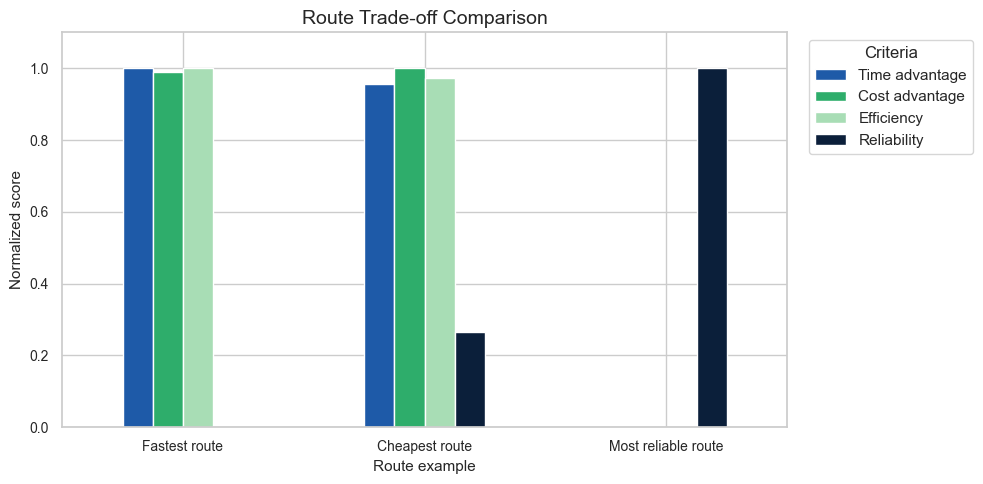

In [195]:
# Route trade-off comparison chart

route_tradeoff = pd.DataFrame(index=route_examples.index)

route_tradeoff["Time advantage"] = normalize_series(
    route_examples["optimized_route_time_min"],
    higher_is_better=False
)

route_tradeoff["Cost advantage"] = normalize_series(
    route_examples["optimized_route_cost"],
    higher_is_better=False
)

route_tradeoff["Efficiency"] = normalize_series(
    route_examples["delivery_efficiency_score"],
    higher_is_better=True
)

route_tradeoff["Reliability"] = normalize_series(
    route_examples["route_reliability_index"],
    higher_is_better=True
)

ax = route_tradeoff.plot(
    kind="bar",
    figsize=(10, 5),
    color=[
        project_palette["blue"],
        project_palette["green"],
        project_palette["light_green"],
        project_palette["navy"]
    ]
)

plt.title("Route Trade-off Comparison")
plt.xlabel("Route example")
plt.ylabel("Normalized score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Criteria", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Route KPI landscape

This chart compares route time, route cost, traffic density and reliability in one view.

I use this chart because route decisions are multi-dimensional.  
A route can be fast, but not necessarily cheap or reliable.

This chart helps prepare the logic for the Delivery Option Score, where several criteria will be considered together.

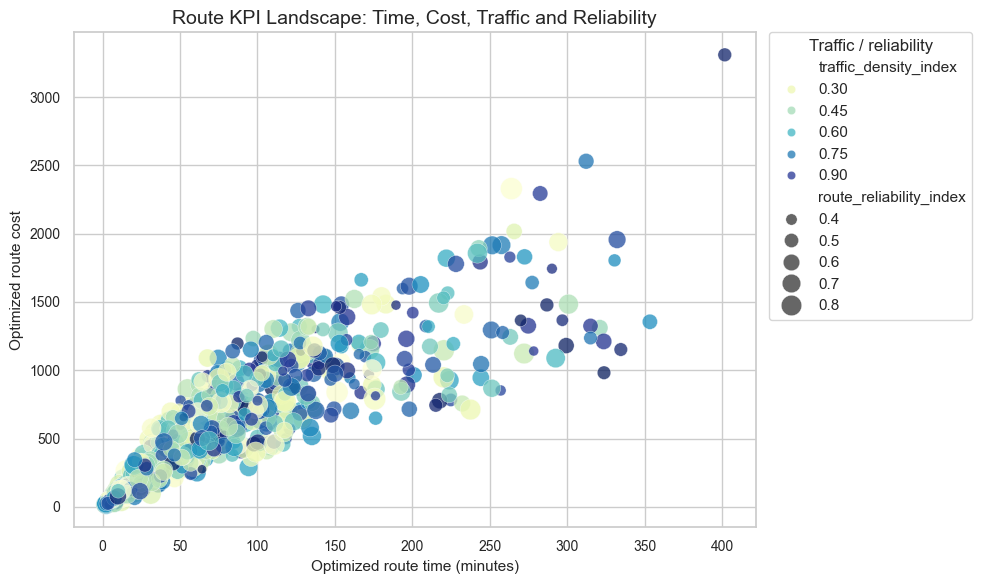

In [196]:
# Route KPI landscape: time, cost, traffic and reliability

route_kpi_landscape = route_clean.copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=route_kpi_landscape,
    x="optimized_route_time_min",
    y="optimized_route_cost",
    hue="traffic_density_index",
    size="route_reliability_index",
    sizes=(30, 250),
    palette="YlGnBu",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3
)

plt.title("Route KPI Landscape: Time, Cost, Traffic and Reliability")
plt.xlabel("Optimized route time (minutes)")
plt.ylabel("Optimized route cost")
plt.legend(
    title="Traffic / reliability",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### Route KPI landscape observation

The route KPI landscape shows that route options are spread across different combinations of time and cost.

Some routes are short and low-cost, while others are more expensive and take longer.  
The bubble size adds another layer by showing reliability, and the color shows traffic density.

This chart is useful because it makes the trade-off visible.  
Route planning is not just about minimizing one value; it is about balancing time, cost, reliability and traffic.


## 4.3 CO2 and Sustainability KPIs

The sustainability KPIs summarize the environmental side of the project.

The carbon emissions dataset has 12,000 records.  
The average CO2 emission is around 71.99 kgCO2e, but the maximum value is much higher, around 1,280.17 kgCO2e.

This means that emissions are not evenly distributed.  
Some deliveries have a much higher environmental impact than the majority.

For this reason, I analyse average emissions, eco-friendly delivery rate, vehicle type, route type and traffic conditions.

In [197]:
# 4.3 CO2 and Sustainability KPIs

eco_friendly_rate = carbon_clean["is_eco_friendly"].mean() * 100

avg_co2_by_vehicle = (
    carbon_clean
    .groupby("vehicle_type")["carbon_emission_kgco2e"]
    .mean()
    .sort_values()
    .reset_index()
)

lowest_co2_vehicle = avg_co2_by_vehicle.iloc[0]["vehicle_type"]

avg_co2_by_route_type = (
    carbon_clean
    .groupby("route_type")["carbon_emission_kgco2e"]
    .mean()
    .sort_values()
    .reset_index()
)

lowest_co2_route_type = avg_co2_by_route_type.iloc[0]["route_type"]

carbon_kpis = pd.DataFrame({
    "Area": [
        "CO2 and Sustainability",
        "CO2 and Sustainability",
        "CO2 and Sustainability",
        "CO2 and Sustainability",
        "CO2 and Sustainability",
        "CO2 and Sustainability",
        "CO2 and Sustainability",
        "CO2 and Sustainability",
        "CO2 and Sustainability"
    ],
    "KPI": [
        "Total carbon records",
        "Average distance",
        "Average package weight",
        "Average CO2 emissions",
        "Minimum CO2 emissions",
        "Maximum CO2 emissions",
        "Eco-friendly delivery rate",
        "Lowest average CO2 vehicle type",
        "Lowest average CO2 route type"
    ],
    "Value": [
        len(carbon_clean),
        round(carbon_clean["distance_km"].mean(), 2),
        round(carbon_clean["package_weight_kg"].mean(), 2),
        round(carbon_clean["carbon_emission_kgco2e"].mean(), 2),
        round(carbon_clean["carbon_emission_kgco2e"].min(), 2),
        round(carbon_clean["carbon_emission_kgco2e"].max(), 2),
        round(eco_friendly_rate, 2),
        lowest_co2_vehicle,
        lowest_co2_route_type
    ],
    "Unit": [
        "records",
        "km",
        "kg",
        "kgCO2e",
        "kgCO2e",
        "kgCO2e",
        "%",
        "category",
        "category"
    ],
    "Interpretation": [
        "Number of records in the carbon emissions dataset",
        "Typical route distance in the sustainability dataset",
        "Typical package weight",
        "Typical CO2 emissions per record",
        "Lowest emissions observed",
        "Highest emissions observed",
        "Share of records marked as eco-friendly",
        "Vehicle type with the lowest average CO2 emissions",
        "Route type with the lowest average CO2 emissions"
    ]
})

carbon_cards = [
    ("Carbon records", len(carbon_clean), "records", "Sustainability dataset size"),
    ("Avg. CO2", round(carbon_clean["carbon_emission_kgco2e"].mean(), 2), "kgCO2e", "Typical emission level"),
    ("Eco-friendly rate", round(eco_friendly_rate, 2), "%", "Share marked as eco-friendly"),
    ("Lowest CO2 vehicle", lowest_co2_vehicle, "category", "Best vehicle type by average CO2")
]

show_kpi_cards(carbon_cards)

carbon_kpis


,Area,KPI,Value,Unit,Interpretation
0,CO2 and Sustainability,Total carbon records,12000,records,Number of records in the carbon emissions dataset
1,CO2 and Sustainability,Average distance,102.85,km,Typical route distance in the sustainability d...
2,CO2 and Sustainability,Average package weight,396.36,kg,Typical package weight
3,CO2 and Sustainability,Average CO2 emissions,71.99,kgCO2e,Typical CO2 emissions per record
4,CO2 and Sustainability,Minimum CO2 emissions,0.0,kgCO2e,Lowest emissions observed
5,CO2 and Sustainability,Maximum CO2 emissions,1280.17,kgCO2e,Highest emissions observed
6,CO2 and Sustainability,Eco-friendly delivery rate,42.7,%,Share of records marked as eco-friendly
7,CO2 and Sustainability,Lowest average CO2 vehicle type,Cargo Bicycle,category,Vehicle type with the lowest average CO2 emiss...
8,CO2 and Sustainability,Lowest average CO2 route type,Urban Last Mile,category,Route type with the lowest average CO2 emissions


### CO2 and Sustainability KPI observation

The average CO2 emission is around 71.99 kgCO2e.

The eco-friendly delivery rate is around 42.70%, which means that non-eco-friendly deliveries are still the majority in this dataset.

The lowest-emission vehicle type is `Cargo Bicycle`, while `Heavy Truck` has the highest average emissions.  
This shows that vehicle type is one of the most important sustainability factors.

These KPIs will be useful later when I add the sustainability component to the Delivery Option Score.

### Average CO2 emissions by vehicle type

This chart compares average CO2 emissions by vehicle type.

I use a horizontal bar chart because vehicle names can be long, and this format is easier to read.

This chart helps show which vehicle types are more sustainable and which ones create higher emissions.

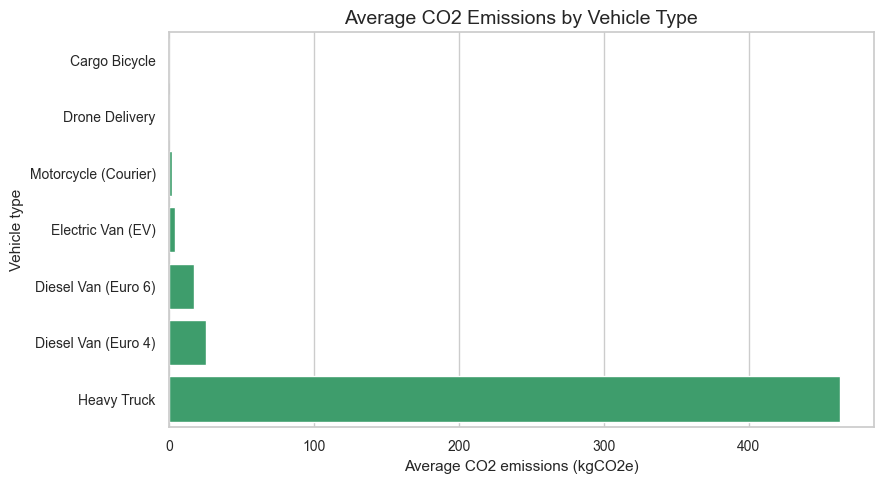

,vehicle_type,carbon_emission_kgco2e
0,Cargo Bicycle,0.000000
1,Drone Delivery,0.064592
2,Motorcycle (Courier),2.505052
3,Electric Van (EV),4.059115
4,Diesel Van (Euro 6),17.115735
5,Diesel Van (Euro 4),25.913168
6,Heavy Truck,463.138771


In [198]:
# Average CO2 emissions by vehicle type

plt.figure(figsize=(9, 5))

sns.barplot(
    data=avg_co2_by_vehicle,
    x="carbon_emission_kgco2e",
    y="vehicle_type",
    color=project_palette["green"]
)

plt.title("Average CO2 Emissions by Vehicle Type")
plt.xlabel("Average CO2 emissions (kgCO2e)")
plt.ylabel("Vehicle type")

plt.tight_layout()
plt.show()

avg_co2_by_vehicle


### Vehicle CO2 KPI observation

The chart shows a very clear difference between vehicle types.

`Cargo Bicycle` has zero emissions in this dataset, and `Drone Delivery` also has very low average emissions.  
On the other side, `Heavy Truck` has the highest average emissions by far, around 463.14 kgCO2e.

This makes vehicle type a strong factor for sustainability decisions.

### Average CO2 emissions by route type

This chart compares average CO2 emissions by route type.

Route type is important because longer or more complex routes can create much higher emissions than urban last-mile routes.

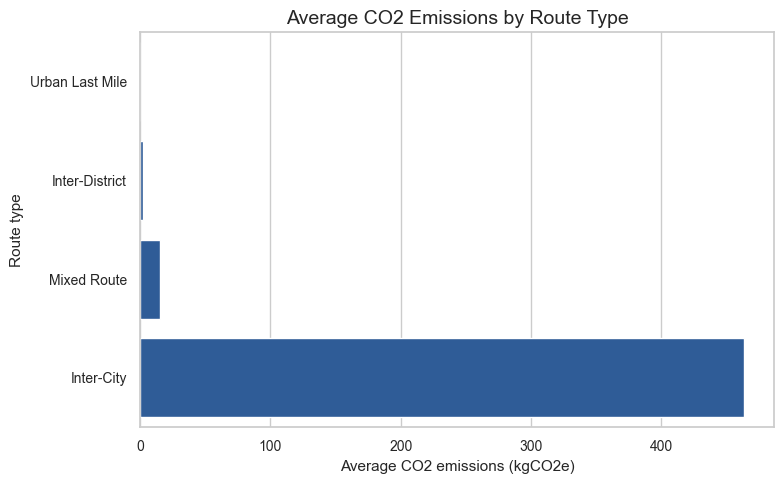

,route_type,carbon_emission_kgco2e
0,Urban Last Mile,0.031856
1,Inter-District,2.505052
2,Mixed Route,15.677152
3,Inter-City,463.138771


In [199]:
# Average CO2 emissions by route type

plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_co2_by_route_type,
    x="carbon_emission_kgco2e",
    y="route_type",
    color=project_palette["blue"]
)

plt.title("Average CO2 Emissions by Route Type")
plt.xlabel("Average CO2 emissions (kgCO2e)")
plt.ylabel("Route type")

plt.tight_layout()
plt.show()

avg_co2_by_route_type


### Route type CO2 KPI observation

The chart shows that `Inter-City` routes have the highest average CO2 emissions, around 463.14 kgCO2e.

`Urban Last Mile` has the lowest average emissions, while `Inter-District` and `Mixed Route` are in the middle.

This is important because route planning should not only compare time and cost.  
It should also consider the environmental impact of different route types.

### Eco-friendly delivery mix

This donut chart shows the share of eco-friendly and non-eco-friendly deliveries.

I use a donut chart here because this is a part-to-whole comparison.

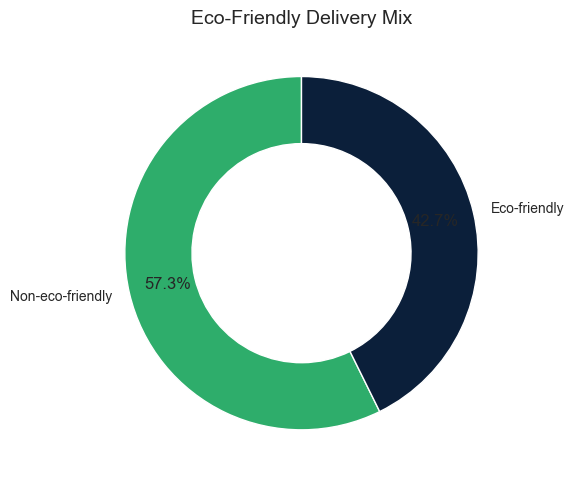

,delivery_type,count
0,Non-eco-friendly,6876
1,Eco-friendly,5124


In [200]:
# Eco-friendly delivery mix donut chart

eco_mix = pd.DataFrame({
    "delivery_type": np.where(
        carbon_clean["is_eco_friendly"] == 1,
        "Eco-friendly",
        "Non-eco-friendly"
    )
})

eco_mix_counts = (
    eco_mix["delivery_type"]
    .value_counts()
    .reset_index()
)

eco_mix_counts.columns = ["delivery_type", "count"]

plt.figure(figsize=(7, 5))

plt.pie(
    eco_mix_counts["count"],
    labels=eco_mix_counts["delivery_type"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    colors=[project_palette["green"], project_palette["navy"]],
    wedgeprops=dict(width=0.38, edgecolor="white")
)

plt.title("Eco-Friendly Delivery Mix")
plt.tight_layout()
plt.show()

eco_mix_counts

### Eco-friendly delivery mix observation

The eco-friendly rate is around 42.70%.

This means that eco-friendly deliveries are a significant part of the dataset, but they are not the majority.

This KPI is useful as a simple sustainability label, but it should be interpreted together with actual CO2 emissions, vehicle type and route type.

### CO2 spread by traffic conditions

This boxplot compares the distribution of CO2 emissions under different traffic conditions.

I use a boxplot instead of only comparing averages because CO2 values are not evenly distributed.  
This chart helps show the spread and extreme values for each traffic condition.

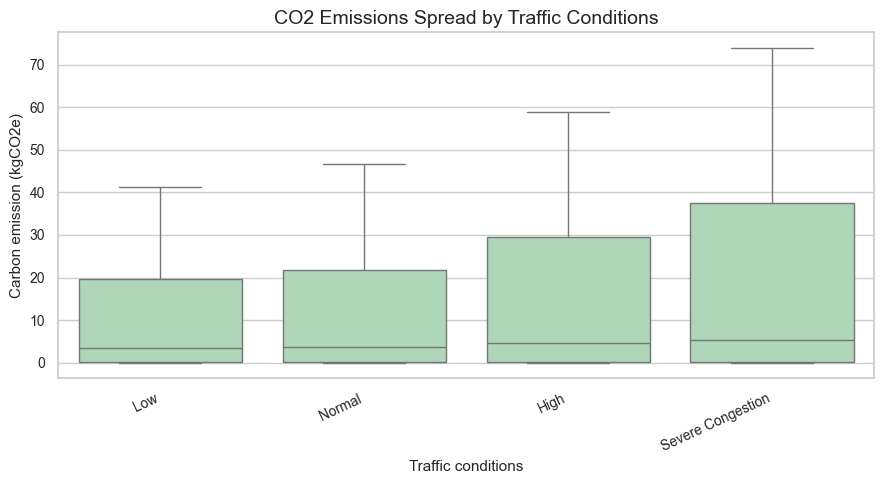

In [201]:
# CO2 emissions spread by traffic conditions

traffic_condition_order = (
    carbon_clean
    .groupby("traffic_conditions")["carbon_emission_kgco2e"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=carbon_clean,
    x="traffic_conditions",
    y="carbon_emission_kgco2e",
    order=traffic_condition_order,
    color=project_palette["light_green"],
    showfliers=False
)

plt.title("CO2 Emissions Spread by Traffic Conditions")
plt.xlabel("Traffic conditions")
plt.ylabel("Carbon emission (kgCO2e)")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

### CO2 spread by traffic conditions observation

The boxplot shows that traffic conditions are connected with differences in CO2 emissions.

From the earlier EDA and KPI results, Severe Congestion and High traffic conditions have higher average emissions than Normal or Low traffic conditions.

The boxplot is useful because it also shows that emissions can vary a lot inside each traffic category.  
This means traffic condition matters, but it is not the only factor affecting emissions.

### Sustainability KPI takeaway

The sustainability KPIs show how delivery decisions can be connected with environmental impact.

For the final project, this is important because it makes the analysis more useful than a simple route comparison.  
The project does not only ask which option is faster or cheaper, but also which option may be more sustainable.


## 4.4 Tracking and Reliability KPIs

The tracking KPIs add the reliability perspective to the project.

Before calculating the final reliability rates, I clean the delivery status logic.  
This is necessary because a few records are marked as both on-time and delayed, and a few records have neither status.

After cleaning this logic, I calculate on-time and delayed rates only from valid delivery status records.

### Tracking flag quality check

The tracking status fields are not perfectly clean.

There are 24 records marked as both on-time and delayed, and 14 records with unknown status.  
To avoid using inconsistent records in the main reliability rates, I create a cleaned delivery status column.

After this cleaning step, there are 6,839 valid status records.  
Among these valid records, 2,524 are on time and 4,315 are delayed.

In [202]:
# Create a cleaner delivery status column before calculating reliability KPIs

tracking_clean["delivery_status_clean"] = np.select(
    [
        (tracking_clean["is_on_time"] == 1) & (tracking_clean["is_delayed"] == 1),
        (tracking_clean["is_on_time"] == 1) & (tracking_clean["is_delayed"] == 0),
        (tracking_clean["is_on_time"] == 0) & (tracking_clean["is_delayed"] == 1)
    ],
    [
        "Conflict",
        "On time",
        "Delayed"
    ],
    default="Unknown"
)

delivery_status_clean_counts = (
    tracking_clean["delivery_status_clean"]
    .value_counts()
    .reset_index()
)

delivery_status_clean_counts.columns = ["delivery_status", "records"]

valid_tracking_status = tracking_clean[
    ~tracking_clean["delivery_status_clean"].isin(["Conflict", "Unknown"])
].copy()

on_time_rate_clean = (
    valid_tracking_status["delivery_status_clean"]
    .eq("On time")
    .mean() * 100
)

delayed_rate_clean = (
    valid_tracking_status["delivery_status_clean"]
    .eq("Delayed")
    .mean() * 100
)

print("Clean on-time rate:", round(on_time_rate_clean, 2))
print("Clean delayed rate:", round(delayed_rate_clean, 2))

delivery_status_clean_counts


Clean on-time rate: 36.91
Clean delayed rate: 63.09


,delivery_status,records
0,Delayed,4315
1,On time,2524
2,Conflict,24
3,Unknown,14


In [203]:
# 4.4 Tracking and Reliability KPIs

on_time_rate = on_time_rate_clean
delayed_rate = delayed_rate_clean

most_common_vehicle_tracking = tracking_clean["vehicletype"].mode()[0]
conflict_status_records = (tracking_clean["delivery_status_clean"] == "Conflict").sum()
unknown_status_records = (tracking_clean["delivery_status_clean"] == "Unknown").sum()
valid_status_records = len(valid_tracking_status)

tracking_kpis = pd.DataFrame({
    "Area": [
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability",
        "Tracking and Reliability"
    ],
    "KPI": [
        "Total tracked deliveries",
        "Valid status records",
        "Clean on-time delivery rate",
        "Clean delayed delivery rate",
        "Conflicting status records",
        "Unknown status records",
        "Average transportation distance",
        "Median transportation distance",
        "Most common vehicle type",
        "Unique origin locations"
    ],
    "Value": [
        len(tracking_clean),
        valid_status_records,
        round(on_time_rate, 2),
        round(delayed_rate, 2),
        conflict_status_records,
        unknown_status_records,
        round(tracking_clean["transportation_distance_in_km"].mean(), 2),
        round(tracking_clean["transportation_distance_in_km"].median(), 2),
        most_common_vehicle_tracking,
        tracking_clean["origin_location"].nunique()
    ],
    "Unit": [
        "deliveries",
        "deliveries",
        "%",
        "%",
        "records",
        "records",
        "km",
        "km",
        "category",
        "locations"
    ],
    "Interpretation": [
        "Number of cleaned tracking records",
        "Records used for clean on-time and delayed rate calculation",
        "Share of valid delivery records marked as on-time",
        "Share of valid delivery records marked as delayed",
        "Records marked as both on-time and delayed",
        "Records with neither on-time nor delayed flag",
        "Average transport distance",
        "Median transport distance, useful because distances can be very spread out",
        "Most frequent vehicle type in the tracking data",
        "Number of different origin locations"
    ]
})

tracking_cards = [
    ("Tracked deliveries", len(tracking_clean), "deliveries", "Cleaned tracking records"),
    ("Valid status records", valid_status_records, "deliveries", "Used for clean reliability rates"),
    ("Clean on-time rate", round(on_time_rate, 2), "%", "Higher is better"),
    ("Clean delayed rate", round(delayed_rate, 2), "%", "Lower is better")
]

show_kpi_cards(tracking_cards)

tracking_kpis


,Area,KPI,Value,Unit,Interpretation
0,Tracking and Reliability,Total tracked deliveries,6877,deliveries,Number of cleaned tracking records
1,Tracking and Reliability,Valid status records,6839,deliveries,Records used for clean on-time and delayed rat...
2,Tracking and Reliability,Clean on-time delivery rate,36.91,%,Share of valid delivery records marked as on-time
3,Tracking and Reliability,Clean delayed delivery rate,63.09,%,Share of valid delivery records marked as delayed
4,Tracking and Reliability,Conflicting status records,24,records,Records marked as both on-time and delayed
5,Tracking and Reliability,Unknown status records,14,records,Records with neither on-time nor delayed flag
6,Tracking and Reliability,Average transportation distance,553.82,km,Average transport distance
7,Tracking and Reliability,Median transportation distance,160.0,km,"Median transport distance, useful because dist..."
8,Tracking and Reliability,Most common vehicle type,40 FT 3XL Trailer 35MT,category,Most frequent vehicle type in the tracking data
9,Tracking and Reliability,Unique origin locations,180,locations,Number of different origin locations


### Tracking and Reliability KPI observation

The clean on-time delivery rate is around 36.91%, while the clean delayed delivery rate is around 63.09%.

This means that delays are more common than on-time deliveries in the valid tracking records.

The average transportation distance is around 553.82 km, while the median distance is 160 km.  
This shows that some long-distance deliveries increase the average.

Reliability is an important part of the final score because a delivery option is not useful if it has a high delay risk.

### Clean on-time vs delayed deliveries

This chart makes the reliability situation easier to understand after cleaning the delivery status flags.

It is useful for the presentation because the audience can immediately see the balance between clean on-time and delayed delivery rates.


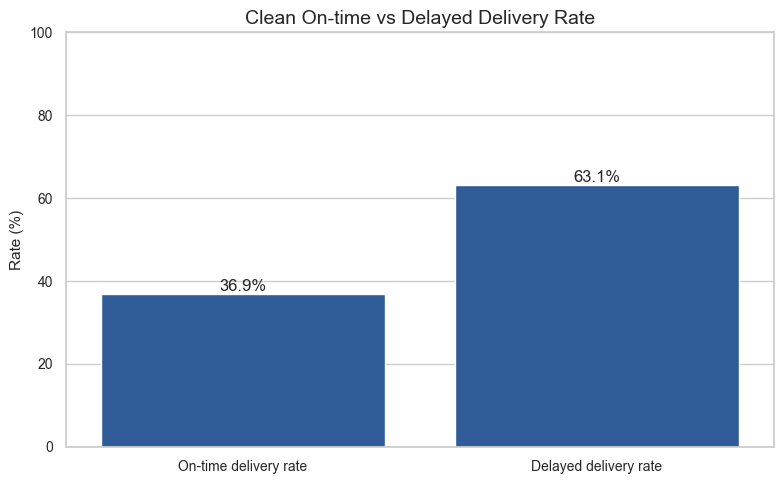

In [204]:
# Clean on-time vs delayed delivery rate

clean_status_rate_chart = pd.DataFrame({
    "Metric": ["On-time delivery rate", "Delayed delivery rate"],
    "Rate": [on_time_rate_clean, delayed_rate_clean]
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=clean_status_rate_chart,
    x="Metric",
    y="Rate",
    color=project_palette["blue"]
)

plt.title("Clean On-time vs Delayed Delivery Rate")
plt.xlabel("")
plt.ylabel("Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()


### Clean delivery status mix

This donut chart shows the share of on-time and delayed deliveries after cleaning the delivery status logic.

I use the cleaned status because it avoids the conflict caused by records that were both on-time and delayed.

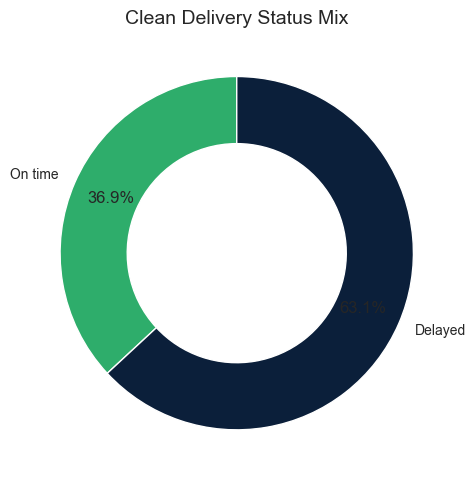

,delivery_status,records
0,On time,2524
1,Delayed,4315


In [205]:
# Clean delivery status mix donut chart

clean_delivery_mix = (
    valid_tracking_status["delivery_status_clean"]
    .value_counts()
    .reindex(["On time", "Delayed"])
    .reset_index()
)

clean_delivery_mix.columns = ["delivery_status", "records"]

plt.figure(figsize=(7, 5))

plt.pie(
    clean_delivery_mix["records"],
    labels=clean_delivery_mix["delivery_status"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    colors=[project_palette["green"], project_palette["navy"]],
    wedgeprops=dict(width=0.38, edgecolor="white")
)

plt.title("Clean Delivery Status Mix")
plt.tight_layout()
plt.show()

clean_delivery_mix

### Clean delivery status mix observation

The donut chart shows that delayed deliveries are the majority.

The clean delayed rate is around 63.09%, while the clean on-time rate is around 36.91%.

This confirms that reliability is one of the main issues in the tracking dataset and should be included in the Delivery Option Score.

### Reliability KPI takeaway

The tracking KPIs add an operational quality perspective to the project.

Before calculating the final reliability rates, I cleaned the delivery status logic because a few records had conflicting or unknown status values.  
The clean on-time and delayed rates are calculated only from valid status records.

This is useful because a delivery option that looks good on paper may not be good enough if it has a high delay risk.  
For that reason, reliability should be included in the final Delivery Option Score.


## 4.5 Barcelona TRAMS Traffic Context KPIs

The TRAMS KPIs add real urban traffic context from Barcelona.

This dataset is not directly linked to each delivery route, so I do not use it as a direct optimization input.

Instead, I use it to understand the city-level traffic context and to make the project more connected to a real urban environment.

In [206]:
# 4.5 Barcelona TRAMS Traffic Context KPIs

traffic_status_map = {
    0: "No data",
    1: "Very fluid",
    2: "Fluid",
    3: "Dense",
    4: "Very dense",
    5: "Congestion",
    6: "Section closed"
}

trams_clean["actual_status_label"] = trams_clean["estatactual"].map(traffic_status_map)
trams_clean["predicted_status_label"] = trams_clean["estatprevist"].map(traffic_status_map)

trams_valid = trams_clean[trams_clean["estatactual"] != 0].copy()
trams_valid_prediction = trams_clean[
    (trams_clean["estatactual"] != 0) &
    (trams_clean["estatprevist"] != 0)
].copy()

monthly_trams_records = (
    trams_clean
    .groupby("month")
    .size()
    .reset_index(name="records")
)

hourly_trams_records = (
    trams_clean
    .groupby("hour")
    .size()
    .reset_index(name="records")
)

valid_status_records = (
    trams_valid["actual_status_label"]
    .value_counts()
    .reset_index()
)
valid_status_records.columns = ["actual_status_label", "records"]

peak_month = monthly_trams_records.loc[
    monthly_trams_records["records"].idxmax(),
    "month"
]

peak_hour = hourly_trams_records.loc[
    hourly_trams_records["records"].idxmax(),
    "hour"
]

most_common_valid_status = valid_status_records.iloc[0]["actual_status_label"]

no_data_share = (trams_clean["estatactual"] == 0).mean() * 100

valid_actual_predicted_match_rate = (
    trams_valid_prediction["estatactual"] == trams_valid_prediction["estatprevist"]
).mean() * 100

high_congestion_share = trams_valid["estatactual"].isin([4, 5]).mean() * 100

trams_kpis = pd.DataFrame({
    "Area": [
        "Barcelona Traffic Context",
        "Barcelona Traffic Context",
        "Barcelona Traffic Context",
        "Barcelona Traffic Context",
        "Barcelona Traffic Context",
        "Barcelona Traffic Context",
        "Barcelona Traffic Context",
        "Barcelona Traffic Context"
    ],
    "KPI": [
        "Total TRAMS records",
        "Valid TRAMS records",
        "No data share",
        "Most common valid traffic status",
        "High congestion share",
        "Peak record month",
        "Peak record hour",
        "Valid actual-predicted status match rate"
    ],
    "Value": [
        int(trams_clean.shape[0]),
        int(trams_valid.shape[0]),
        round(no_data_share, 2),
        most_common_valid_status,
        round(high_congestion_share, 2),
        peak_month,
        peak_hour,
        round(valid_actual_predicted_match_rate, 2)
    ],
    "Unit": [
        "records",
        "records",
        "%",
        "category",
        "%",
        "month number",
        "hour",
        "%"
    ],
    "Interpretation": [
        "Total number of Barcelona TRAMS traffic records",
        "Records with a meaningful traffic status, excluding No data",
        "Share of records where traffic status is not available",
        "Most frequent actual traffic status after excluding No data",
        "Share of valid records classified as Very dense or Congestion",
        "Month with the highest number of available records",
        "Hour with the highest number of available records",
        "Share of valid records where predicted and actual status are equal"
    ]
})

trams_cards = [
    ("Valid TRAMS records", int(trams_valid.shape[0]), "records", "Real Barcelona traffic context"),
    ("Common valid status", most_common_valid_status, "category", "Most frequent valid traffic status"),
    ("High congestion share", round(high_congestion_share, 2), "%", "Very dense or congestion"),
    ("Valid prediction match", round(valid_actual_predicted_match_rate, 2), "%", "Actual and predicted equality")
]

show_kpi_cards(trams_cards)

trams_kpis


,Area,KPI,Value,Unit,Interpretation
0,Barcelona Traffic Context,Total TRAMS records,11661440,records,Total number of Barcelona TRAMS traffic records
1,Barcelona Traffic Context,Valid TRAMS records,6150264,records,"Records with a meaningful traffic status, excl..."
2,Barcelona Traffic Context,No data share,47.26,%,Share of records where traffic status is not a...
3,Barcelona Traffic Context,Most common valid traffic status,Fluid,category,Most frequent actual traffic status after excl...
4,Barcelona Traffic Context,High congestion share,5.8,%,Share of valid records classified as Very dens...
5,Barcelona Traffic Context,Peak record month,5,month number,Month with the highest number of available rec...
6,Barcelona Traffic Context,Peak record hour,9,hour,Hour with the highest number of available records
7,Barcelona Traffic Context,Valid actual-predicted status match rate,77.21,%,Share of valid records where predicted and act...


### Barcelona TRAMS KPI observation

The TRAMS dataset has more than 11.6 million records after cleaning.

A key improvement in this version is that `No data` records are separated from valid traffic records.  
After excluding `No data`, the most common valid traffic status is `Fluid`.

The high congestion share measures the percentage of valid records classified as `Very dense` or `Congestion`.  
This gives a cleaner and more meaningful city-level traffic context for the project.

These KPIs are useful as urban traffic context, not as direct delivery-route KPIs.


### Most common actual TRAMS traffic status

This chart shows the most common actual TRAMS traffic status labels.

It gives a simple visual summary of the Barcelona traffic context used in the project.

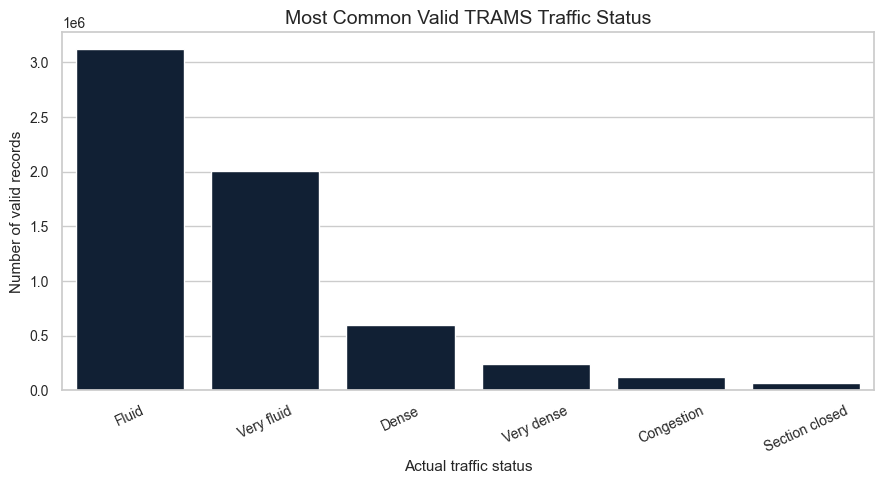

,actual_status_label,records
0,Fluid,3119539
1,Very fluid,2009204
2,Dense,599815
3,Very dense,238407
4,Congestion,118459
5,Section closed,64840


In [207]:
# TRAMS valid traffic status distribution

top_actual_status_records = valid_status_records.head(8)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_actual_status_records,
    x="actual_status_label",
    y="records",
    color=project_palette["navy"]
)

plt.title("Most Common Valid TRAMS Traffic Status")
plt.xlabel("Actual traffic status")
plt.ylabel("Number of valid records")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

top_actual_status_records


### TRAMS traffic status observation

After removing `No data`, `Fluid` is the most common actual traffic status, followed by `Very fluid`.

This gives a more accurate interpretation of the Barcelona traffic dataset than using all records without filtering.

The remaining categories, including `Dense`, `Very dense` and `Congestion`, are still important because they represent the traffic conditions that can affect urban delivery planning.


### TRAMS actual vs predicted match rate

This donut chart shows how often the actual and predicted TRAMS traffic status are the same.

I use it as a simple KPI-style view of prediction alignment in the Barcelona traffic context.

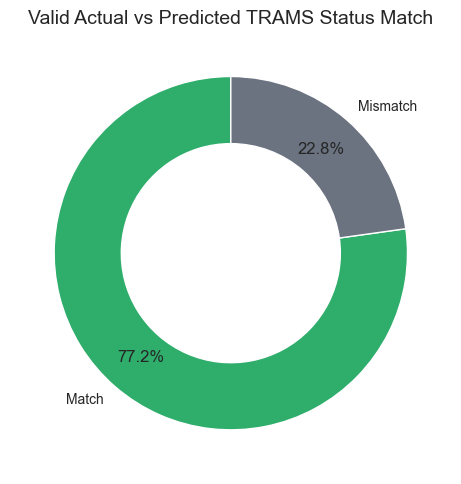

,status,percentage
0,Match,77.210393
1,Mismatch,22.789607


In [208]:
# Actual vs predicted TRAMS traffic status match rate for valid records

match_rate = valid_actual_predicted_match_rate
mismatch_rate = 100 - valid_actual_predicted_match_rate

match_mix = pd.DataFrame({
    "status": ["Match", "Mismatch"],
    "percentage": [match_rate, mismatch_rate]
})

plt.figure(figsize=(7, 5))

plt.pie(
    match_mix["percentage"],
    labels=match_mix["status"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    colors=[project_palette["green"], project_palette["gray"]],
    wedgeprops=dict(width=0.38, edgecolor="white")
)

plt.title("Valid Actual vs Predicted TRAMS Status Match")
plt.tight_layout()
plt.show()

match_mix


### Actual vs predicted match observation

The actual and predicted TRAMS traffic statuses match in around 77.21% of the valid records.

This means that the predicted traffic status follows the actual traffic status in many cases, but it is not perfect.

There is still around 22.79% mismatch between actual and predicted valid traffic records.

This is useful for the project because predicted traffic information can support route planning, but it should not be treated as fully reliable or exact.

### TRAMS traffic intensity by month and hour

For the urban traffic context, I use a heatmap to show how TRAMS records are distributed by month and hour.

This chart combines two time dimensions in one view: month and hour of day.

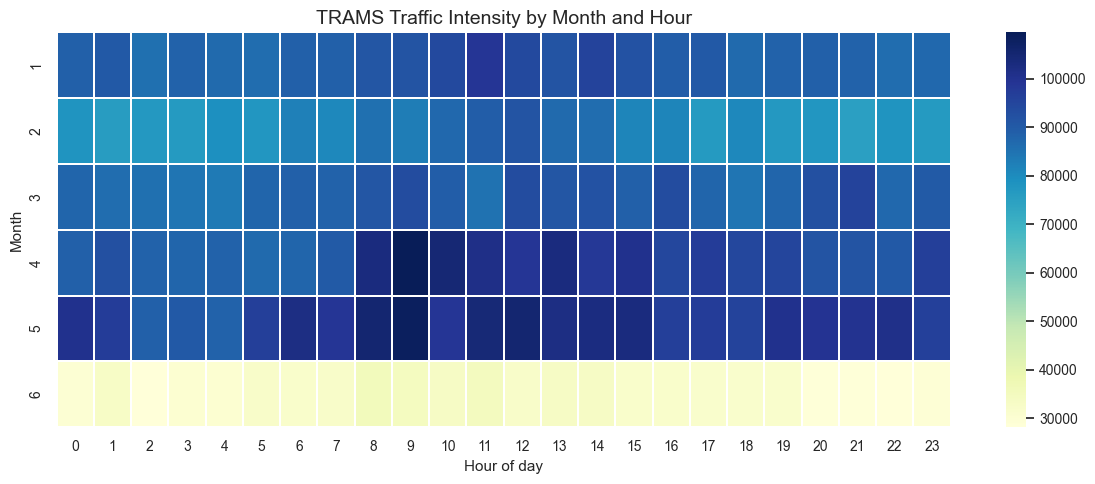

In [209]:
# TRAMS traffic intensity by month and hour

trams_month_hour = (
    trams_summary
    .groupby(["month", "hour"])["records"]
    .sum()
    .reset_index()
)

trams_month_hour_pivot = trams_month_hour.pivot(
    index="month",
    columns="hour",
    values="records"
).fillna(0)

plt.figure(figsize=(12, 5))

sns.heatmap(
    trams_month_hour_pivot,
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("TRAMS Traffic Intensity by Month and Hour")
plt.xlabel("Hour of day")
plt.ylabel("Month")

plt.tight_layout()
plt.show()

### TRAMS month-hour heatmap observation

The heatmap shows how TRAMS traffic records are distributed across months and hours.

May has the highest number of records, while June has fewer records because the available June data is smaller.  
Across the day, the number of records is relatively stable, with slightly higher activity around late morning.

This chart is useful because it gives a more detailed view of the Barcelona traffic context than a single total number.

### Barcelona traffic context takeaway

The TRAMS KPIs help position the project inside a real urban context.

The main limitation is that TRAMS traffic data is not directly linked to each delivery route.  
For this reason, I use it as contextual evidence, not as a direct route optimization input.


## 4.6 Final KPI Summary

In this step, I combine all KPI tables into one final KPI summary.

This table is useful because it keeps all project KPIs in one place.

It can also be used later for the README, the final presentation, or a future dashboard.

In [210]:
# 4.6 Final KPI Summary

kpi_summary = pd.concat(
    [
        route_kpis,
        carbon_kpis,
        tracking_kpis,
        trams_kpis
    ],
    ignore_index=True
)

kpi_summary


,Area,KPI,Value,Unit,Interpretation
0,Route Planning,Total route options,1000.0,routes,Number of available route options in the dataset
1,Route Planning,Average distance,25.62,km,Typical route distance
2,Route Planning,Average optimized route time,74.25,minutes,Typical optimized delivery time
3,Route Planning,Minimum optimized route time,1.43,minutes,Fastest route option in the dataset
4,Route Planning,Average optimized route cost,565.86,cost units,Typical optimized delivery cost
5,Route Planning,Minimum optimized route cost,15.29,cost units,Cheapest route option in the dataset
6,Route Planning,Average traffic density index,0.612,index,Average traffic pressure in the route data
7,Route Planning,Average delivery efficiency score,0.083,score,Average efficiency score already available in ...
8,Route Planning,Average route reliability index,0.604,index,Average reliability index already available in...
9,CO2 and Sustainability,Total carbon records,12000,records,Number of records in the carbon emissions dataset


### Final KPI summary observation

The final KPI summary brings together operational, sustainability, reliability and traffic context indicators.

This makes it easier to compare the different parts of the project.

The table also prepares the next step, where I will use selected KPIs to build a simple educational Delivery Option Score.

## 4.7 Presentation-ready KPI summary

For the final presentation, I create a shorter KPI summary.

This version is not meant to include every detail.  
It is designed to communicate the main message of each project area in a simple way.

In [211]:
# 4.7 Presentation-ready KPI summary

presentation_kpi_summary = pd.DataFrame({
    "Project area": [
        "Route Planning",
        "CO2 and Sustainability",
        "Tracking and Reliability",
        "Barcelona Traffic Context"
    ],
    "Main KPI message": [
        f"Average optimized route time is {route_clean['optimized_route_time_min'].mean():.2f} minutes, with an average cost of {route_clean['optimized_route_cost'].mean():.2f}.",
        f"Average CO2 emissions are {carbon_clean['carbon_emission_kgco2e'].mean():.2f} kgCO2e, and the eco-friendly rate is {eco_friendly_rate:.2f}%.",
        f"Clean on-time delivery rate is {on_time_rate_clean:.2f}%, while clean delayed delivery rate is {delayed_rate_clean:.2f}%.",
        f"After excluding No data records, the most common valid Barcelona TRAMS traffic status is {most_common_valid_status}, with a valid prediction match rate of {valid_actual_predicted_match_rate:.2f}%."
    ],
    "How I use it later": [
        "Used for time and cost components of the score.",
        "Used for the sustainability component of the score.",
        "Used for the reliability component of the score.",
        "Used as urban traffic context and project storytelling."
    ]
})

display_styled_table(
    presentation_kpi_summary,
    caption="Presentation-ready KPI Summary",
    max_rows=10
)

Project area,Main KPI message,How I use it later
Route Planning,"Average optimized route time is 74.25 minutes, with an average cost of 565.86.",Used for time and cost components of the score.
CO2 and Sustainability,"Average CO2 emissions are 71.99 kgCO2e, and the eco-friendly rate is 42.70%.",Used for the sustainability component of the score.
Tracking and Reliability,"Clean on-time delivery rate is 36.91%, while clean delayed delivery rate is 63.09%.",Used for the reliability component of the score.
Barcelona Traffic Context,"After excluding No data records, the most common valid Barcelona TRAMS traffic status is Fluid, with a valid prediction match rate of 77.21%.",Used as urban traffic context and project storytelling.


,Project area,Main KPI message,How I use it later
0,Route Planning,"Average optimized route time is 74.25 minutes,...",Used for time and cost components of the score.
1,CO2 and Sustainability,"Average CO2 emissions are 71.99 kgCO2e, and th...",Used for the sustainability component of the s...
2,Tracking and Reliability,"Clean on-time delivery rate is 36.91%, while c...",Used for the reliability component of the score.
3,Barcelona Traffic Context,"After excluding No data records, the most comm...",Used as urban traffic context and project stor...


In [212]:
# Save KPI outputs

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

kpi_summary.to_csv(OUTPUT_DIR / "kpi_summary.csv",index=False)

route_examples.reset_index(names="route_example").to_csv(
    OUTPUT_DIR / "route_examples.csv",
    index=False)

presentation_kpi_summary.to_csv(
    OUTPUT_DIR / "presentation_kpi_summary.csv",
    index=False)

print("KPI outputs saved successfully.")
print("Output folder: data/outputs")
print("- kpi_summary.csv")
print("- route_examples.csv")
print("- presentation_kpi_summary.csv")

KPI outputs saved successfully.
Output folder: data/outputs
- kpi_summary.csv
- route_examples.csv
- presentation_kpi_summary.csv


### Presentation KPI summary observation

This summary is useful for the final presentation because it translates the KPI tables into short messages.

Each row explains one project area and how it will be used later.

This helps connect the KPI section with the next part of the project: the Delivery Option Score.

## 4.8 KPI limitations

The KPIs in this section come from different datasets.

The route planning, carbon emissions, tracking and TRAMS datasets are not directly merged into one single operational dataset.  
For this reason, I use the KPIs as analytical indicators, not as a real production optimization system.

The TRAMS dataset is especially used as urban traffic context.  
It helps connect the project with Barcelona traffic patterns, but it is not directly linked to each delivery route.

This is important because the final Delivery Option Score will be an educational score, not a commercial routing algorithm.

### Final KPI interpretation

This KPI section is not only a set of tables or cards.

It works as a bridge between the EDA and the final scoring idea.

The main finding is that delivery decisions should not be based on one metric only.

The route planning KPIs show the trade-off between time, cost, traffic and reliability.  
The CO2 KPIs show that sustainability depends strongly on vehicle type, route type, distance and traffic conditions.  
The tracking KPIs show that reliability is a real issue, with a clean delayed delivery rate of around 63.09%.  
The TRAMS KPIs add real Barcelona traffic context. In the improved version, `No data` records are separated from valid traffic records, so the traffic interpretation is cleaner and more reliable.

To make this section easier to understand, I use different visual formats:

- KPI cards for quick numbers
- bar charts for category comparison
- scatter plots for trade-offs
- donut charts for part-to-whole views
- boxplots for distribution comparison
- heatmaps for traffic patterns

This makes the notebook easier to present and easier to connect with the final Delivery Option Score.


# 5. Delivery Option Score

In this section, I create a simple educational Delivery Option Score.

The goal is not to build a real commercial routing algorithm.  
The goal is to combine the main ideas of the project into one clear score that is easy to explain.

The score uses the route planning dataset as the base dataset because it contains route-level information such as time, cost, traffic, efficiency and reliability.

For the sustainability component, I use the carbon emissions dataset to calculate an average CO2 emission factor per kilometer.  
Then I apply that factor to the route distances to estimate a simple CO2 value for each route option.

This keeps the score simple and transparent, while still connecting the final result with the sustainability part of the project.


## 5.1 Scoring logic

The Delivery Option Score combines six components:

- time
- cost
- estimated CO2
- reliability
- traffic
- efficiency

For time, cost, CO2 and traffic, lower values are better.  
For reliability and efficiency, higher values are better.

Each component is converted to a 0-100 score.  
Then I apply weights to calculate the final Delivery Option Score.

The weights are educational and easy to explain:

- 20% time
- 20% cost
- 25% estimated CO2
- 20% reliability
- 10% traffic
- 5% efficiency

I give the highest weight to CO2 because sustainability is one of the main goals of the project.


In [213]:
def normalize_score(series, higher_is_better=True):
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(100, index=series.index)

    if higher_is_better:
        return (series - min_value) / (max_value - min_value) * 100
    else:
        return (max_value - series) / (max_value - min_value) * 100


### Normalization function explanation

The normalization function converts different variables into the same 0-100 scale.

This is necessary because the original variables use different units.  
For example, time is measured in minutes, cost is measured in cost units, and reliability is an index.

By converting everything to a 0-100 score, I can combine the components in a fair and simple way.


In [214]:
score_df = route_clean.copy()

average_co2_per_km = (
    carbon_clean["carbon_emission_kgco2e"].sum() / carbon_clean["distance_km"].sum()
)

score_df["estimated_co2_kgco2e"] = score_df["distance_km"] * average_co2_per_km

print("Average CO2 emission factor per km:", round(average_co2_per_km, 4))
score_df[["distance_km", "estimated_co2_kgco2e"]].head()


Average CO2 emission factor per km: 0.7


,distance_km,estimated_co2_kgco2e
0,13.823579,9.676273
1,13.101961,9.171153
2,45.406474,31.783770
3,13.227764,9.259213
4,14.325537,10.027635


### Estimated CO2 explanation

The route planning dataset does not contain a direct CO2 column.

Because of that, I estimate CO2 emissions using the average CO2 per kilometer from the carbon emissions dataset.

This is a simplified educational approach.  
It does not replace a real emissions model, but it allows the final score to include a sustainability component.


In [215]:
score_weights = pd.DataFrame({
    "component": [
        "Time",
        "Cost",
        "Estimated CO2",
        "Reliability",
        "Traffic",
        "Efficiency"
    ],
    "score_column": [
        "time_score",
        "cost_score",
        "co2_score",
        "reliability_score",
        "traffic_score",
        "efficiency_score"
    ],
    "weight": [
        0.20,
        0.20,
        0.25,
        0.20,
        0.10,
        0.05
    ],
    "direction": [
        "Lower is better",
        "Lower is better",
        "Lower is better",
        "Higher is better",
        "Lower is better",
        "Higher is better"
    ]
})

score_weights


,component,score_column,weight,direction
0,Time,time_score,0.20,Lower is better
1,Cost,cost_score,0.20,Lower is better
2,Estimated CO2,co2_score,0.25,Lower is better
3,Reliability,reliability_score,0.20,Higher is better
4,Traffic,traffic_score,0.10,Lower is better
5,Efficiency,efficiency_score,0.05,Higher is better


### Score weights observation

The score weights show how each component contributes to the final Delivery Option Score.

The score is balanced between operational performance and sustainability.  
Time and cost are important, but they are not the only factors.

Estimated CO2 receives the highest weight because the project focuses on sustainable route planning.  
Reliability is also important because a route is not useful if it has a high risk of poor performance.


## 5.2 Calculate component scores

In this step, I calculate a normalized score for each component.

For time, cost, CO2 and traffic, lower values receive higher scores.  
For reliability and efficiency, higher values receive higher scores.


In [216]:
score_df["time_score"] = normalize_score(
    score_df["optimized_route_time_min"],
    higher_is_better=False
)

score_df["cost_score"] = normalize_score(
    score_df["optimized_route_cost"],
    higher_is_better=False
)

score_df["co2_score"] = normalize_score(
    score_df["estimated_co2_kgco2e"],
    higher_is_better=False
)

score_df["reliability_score"] = normalize_score(
    score_df["route_reliability_index"],
    higher_is_better=True
)

score_df["traffic_score"] = normalize_score(
    score_df["traffic_density_index"],
    higher_is_better=False
)

score_df["efficiency_score"] = normalize_score(
    score_df["delivery_efficiency_score"],
    higher_is_better=True
)

component_score_columns = [
    "time_score",
    "cost_score",
    "co2_score",
    "reliability_score",
    "traffic_score",
    "efficiency_score"
]

score_df[component_score_columns].describe()


,time_score,cost_score,co2_score,reliability_score,traffic_score,efficiency_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,81.810165,83.285937,49.650286,50.836594,48.785873,6.499903
std,16.436198,12.565534,29.131240,20.763625,29.129810,10.342990
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.608279,76.879910,23.924145,36.087690,23.183300,1.380430
50%,86.240663,85.821969,49.829860,50.758853,47.987403,3.097848
75%,93.278334,92.713355,73.808686,65.598651,73.146444,6.561104
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


### Component scores observation

The component scores are now on the same 0-100 scale.

This makes the route options easier to compare because all variables now have the same direction: a higher score means a better result.

The average time score is around 81.81 and the average cost score is around 83.29, which means many routes perform relatively well in time and cost after normalization.

The average CO2 score is around 49.65, the average reliability score is around 50.84, and the average traffic score is around 48.79.  
These values are closer to the middle of the scale, so they create more separation between route options.

The efficiency score has a much lower average, around 6.50.  
This happens because min-max normalization is sensitive to extreme values in the original efficiency column.

This is important to mention because the score is transparent: each component can be explained before calculating the final result.

## 5.3 Calculate final Delivery Option Score

In this step, I calculate the final Delivery Option Score using the weighted component scores.


In [217]:
score_df["delivery_option_score"] = (
    score_df["time_score"] * 0.20 +
    score_df["cost_score"] * 0.20 +
    score_df["co2_score"] * 0.25 +
    score_df["reliability_score"] * 0.20 +
    score_df["traffic_score"] * 0.10 +
    score_df["efficiency_score"] * 0.05
)

score_df["score_rank"] = (
    score_df["delivery_option_score"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

score_df["score_category"] = pd.cut(
    score_df["delivery_option_score"],
    bins=[0, 40, 60, 75, 90, 100],
    labels=["Low", "Average", "Good", "Very good", "Excellent"],
    include_lowest=True
)

score_summary = score_df["delivery_option_score"].describe()
score_summary


count    1000.000000
mean       60.802693
std        14.084213
min         6.879577
25%        51.023608
50%        61.436546
75%        71.215252
max        92.623384
Name: delivery_option_score, dtype: float64

### Delivery Option Score observation

The Delivery Option Score summarizes the route options into one final score.

The average score is 60.80 and the median score is 61.44.  
This shows that most route options are around the middle of the scoring range.

The lowest score is 6.88 and the highest score is 92.62.  
This means the scoring model creates a clear difference between weak and strong route options.

This is useful because the score does not only reward the fastest or cheapest route.  
It rewards routes that balance time, cost, estimated CO2, reliability, traffic and efficiency.

In [218]:
score_category_counts = (
    score_df["score_category"]
    .value_counts()
    .reset_index()
)

score_category_counts.columns = ["score_category", "routes"]
score_category_counts


,score_category,routes
0,Good,389
1,Average,377
2,Very good,152
3,Low,77
4,Excellent,5


### Score category observation

The score categories make the final result easier to understand.

Most route options are in the `Good` and `Average` categories.  
There are 389 routes in `Good` and 377 routes in `Average`.

There are also 152 routes in `Very good`, 77 routes in `Low`, and only 5 routes in `Excellent`.

This is a good result for the project because it shows that excellent delivery options are rare.  
A route needs to perform well across several criteria to reach the highest category.

## 5.4 Top delivery options

In this step, I select the top 10 route options based on the final Delivery Option Score.

These are not automatically the fastest or cheapest routes.  
They are the routes with the best overall balance according to the selected criteria and weights.


In [219]:
top_delivery_options = (
    score_df
    .sort_values("delivery_option_score", ascending=False)
    .head(10)
    .copy()
)

top_delivery_options["route_index"] = top_delivery_options.index
top_delivery_options["route_option_id"] = top_delivery_options["route_index"] + 1
top_delivery_options["route_label"] = (
    "Route option " + top_delivery_options["route_option_id"].astype(str)
)

top_score_columns = [
    "route_label",
    "route_index",
    "route_option_id",
    "distance_km",
    "optimized_route_time_min",
    "optimized_route_cost",
    "traffic_density_index",
    "estimated_co2_kgco2e",
    "delivery_efficiency_score",
    "route_reliability_index",
    "delivery_option_score",
    "score_rank",
    "score_category"
]

display_styled_table(
    top_delivery_options[top_score_columns],
    caption="Top 10 Delivery Options",
    format_dict={
        "distance_km": "{:.2f}",
        "optimized_route_time_min": "{:.2f}",
        "optimized_route_cost": "{:.2f}",
        "traffic_density_index": "{:.3f}",
        "estimated_co2_kgco2e": "{:.2f}",
        "delivery_efficiency_score": "{:.4f}",
        "route_reliability_index": "{:.3f}",
        "delivery_option_score": "{:.2f}"
    }
)

route_label,route_index,route_option_id,distance_km,optimized_route_time_min,optimized_route_cost,traffic_density_index,estimated_co2_kgco2e,delivery_efficiency_score,route_reliability_index,delivery_option_score,score_rank,score_category
Route option 418,417,418,2.91,15.33,85.07,0.216,2.04,0.2449,0.863,92.62,1,Excellent
Route option 343,342,343,4.93,13.78,76.91,0.215,3.45,0.2030,0.875,91.97,2,Excellent
Route option 132,131,132,1.62,5.61,31.61,0.341,1.13,0.4539,0.796,91.12,3,Excellent
Route option 65,64,65,3.55,4.90,38.49,0.291,2.48,0.3390,0.809,90.73,4,Excellent
Route option 422,421,422,2.14,4.12,46.86,0.312,1.50,0.5859,0.756,90.38,5,Excellent
Route option 250,249,250,6.63,11.43,118.36,0.258,4.64,0.3218,0.843,89.83,6,Very good
Route option 693,692,693,1.49,2.90,26.65,0.211,1.04,0.2564,0.723,89.72,7,Very good
Route option 654,653,654,3.57,11.42,100.05,0.213,2.50,0.2415,0.765,89.12,8,Very good
Route option 715,714,715,1.07,1.43,16.70,0.471,0.75,1.2346,0.669,88.95,9,Very good
Route option 972,971,972,8.99,11.82,122.48,0.209,6.29,0.2340,0.833,88.50,10,Very good


,route_label,route_index,route_option_id,distance_km,optimized_route_time_min,optimized_route_cost,traffic_density_index,estimated_co2_kgco2e,delivery_efficiency_score,route_reliability_index,delivery_option_score,score_rank,score_category
417,Route option 418,417,418,2.910805,15.33,85.07,0.216037,2.037514,0.2449,0.863,92.623384,1,Excellent
342,Route option 343,342,343,4.928821,13.78,76.91,0.214705,3.450092,0.2030,0.875,91.969851,2,Excellent
131,Route option 132,131,132,1.617768,5.61,31.61,0.340627,1.132411,0.4539,0.796,91.117882,3,Excellent
64,Route option 65,64,65,3.545872,4.90,38.49,0.290616,2.482051,0.3390,0.809,90.726135,4,Excellent
421,Route option 422,421,422,2.144253,4.12,46.86,0.312132,1.500941,0.5859,0.756,90.375483,5,Excellent
249,Route option 250,249,250,6.631717,11.43,118.36,0.257585,4.642091,0.3218,0.843,89.829067,6,Very good
692,Route option 693,692,693,1.486267,2.90,26.65,0.210987,1.040362,0.2564,0.723,89.715909,7,Very good
653,Route option 654,653,654,3.565396,11.42,100.05,0.212683,2.495717,0.2415,0.765,89.116190,8,Very good
714,Route option 715,714,715,1.066328,1.43,16.70,0.471000,0.746411,1.2346,0.669,88.947213,9,Very good
971,Route option 972,971,972,8.988732,11.82,122.48,0.208538,6.291961,0.2340,0.833,88.502000,10,Very good


### Top delivery options observation

The top delivery options are selected because they have the best overall balance across the scoring criteria.

The best-ranked route is `Route option 418`, with a Delivery Option Score of 92.62.

This route has a short distance of around 2.91 km, an optimized route time of 15.33 minutes, an optimized route cost of 85.07, and an estimated CO2 value of around 2.04 kgCO2e.  
It also has a strong reliability index of 0.863 and a low traffic density index of 0.216.

This explains why it ranks first: it is not necessarily the absolute fastest or cheapest route, but it has the best overall balance.

## 5.5 Delivery Option Score visualizations

In this step, I use different charts to explain the final score.

The goal is not only to show the number, but also to understand how the score behaves across the route options.


### Distribution of Delivery Option Score

This chart shows how the final scores are distributed across all route options.


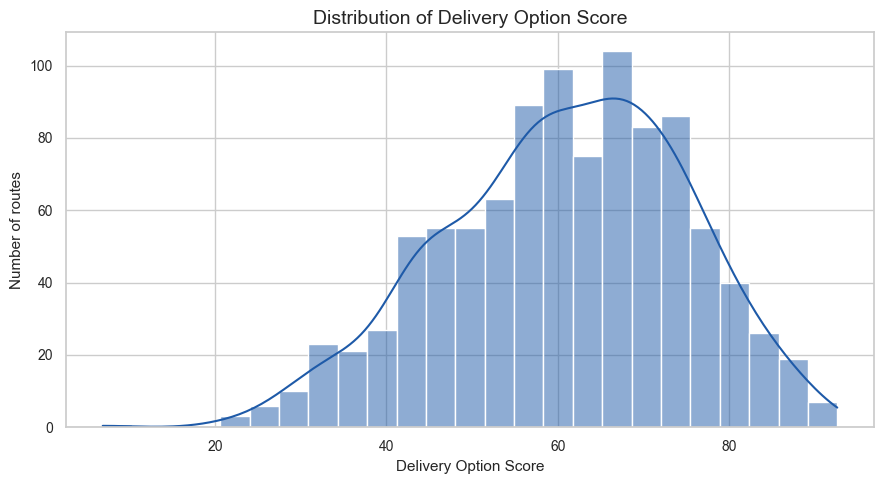

In [220]:
plt.figure(figsize=(9, 5))

sns.histplot(
    score_df["delivery_option_score"],
    bins=25,
    kde=True,
    color=project_palette["blue"]
)

plt.title("Distribution of Delivery Option Score")
plt.xlabel("Delivery Option Score")
plt.ylabel("Number of routes")

plt.tight_layout()
plt.show()


### Score distribution observation

The score distribution shows that most route options are concentrated around the middle of the scoring range.

The average score is 60.80 and the median score is 61.44, so the distribution is centered around the `Average` and `Good` categories.

Only a small number of routes reach the highest scores.  
This matches the category results, where only 5 routes are classified as `Excellent`.

This makes the score useful for ranking and filtering delivery options.

### Top 10 delivery options by score

This chart shows the top 10 route options ranked by Delivery Option Score.


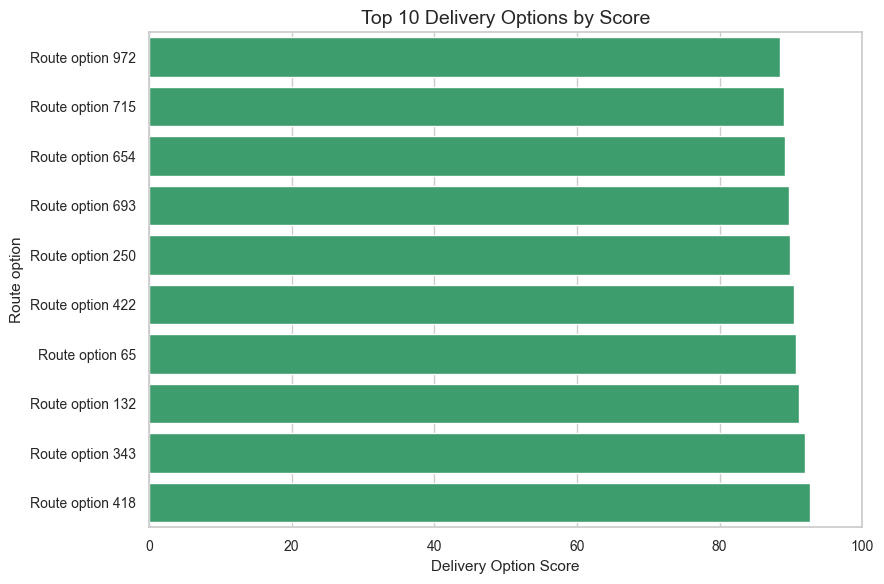

In [221]:
top_10_plot = top_delivery_options.sort_values(
    "delivery_option_score",
    ascending=True
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_10_plot,
    x="delivery_option_score",
    y="route_label",
    color=project_palette["green"]
)

plt.title("Top 10 Delivery Options by Score")
plt.xlabel("Delivery Option Score")
plt.ylabel("Route option")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


### Top 10 score observation

The top 10 chart gives a clear ranking of the best delivery options.

The first five route options are classified as `Excellent`, and the next five are classified as `Very good`.

The best route is `Route option 418`, with a score of 92.62.  
The tenth route is still strong, with a score of 88.50.

This chart is useful for the final presentation because it shows the practical output of the scoring process: a ranked list of route options.

### Score components heatmap

This heatmap shows how the top 10 route options perform across the six score components.


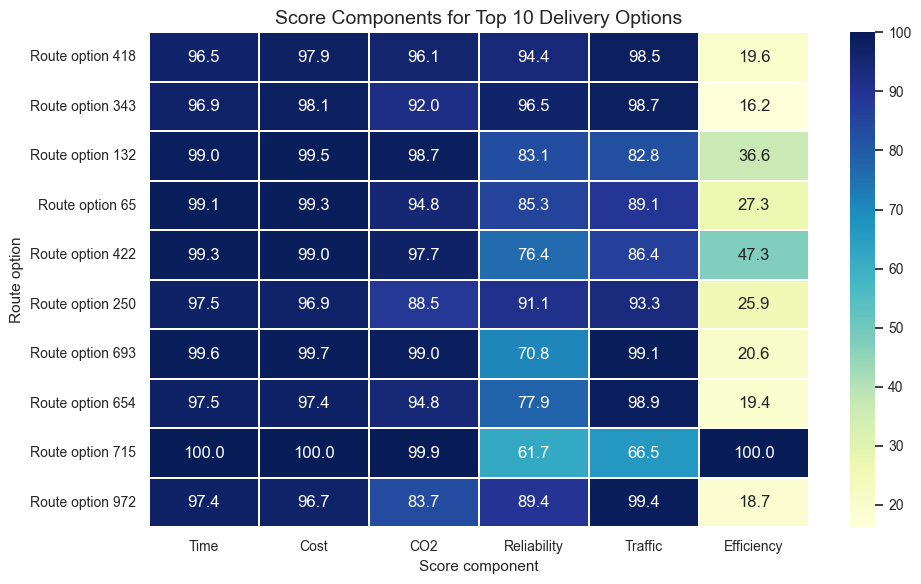

In [222]:
component_heatmap_data = (
    top_delivery_options
    .set_index("route_label")[component_score_columns]
    .rename(columns={
        "time_score": "Time",
        "cost_score": "Cost",
        "co2_score": "CO2",
        "reliability_score": "Reliability",
        "traffic_score": "Traffic",
        "efficiency_score": "Efficiency"
    })
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    component_heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Score Components for Top 10 Delivery Options")
plt.xlabel("Score component")
plt.ylabel("Route option")

plt.tight_layout()
plt.show()


### Score components heatmap observation

The heatmap explains why the top routes received high scores.

For the best route, `Route option 418`, the component scores are strong in several areas: time, cost, estimated CO2, reliability and traffic.

The best route has a time score of 96.53, a cost score of 97.88, a CO2 score of 96.09, a reliability score of 94.44, and a traffic score of 98.50.

Its efficiency score is lower, around 19.63, but efficiency has only a 5% weight in the final score.

This makes the score more transparent because the final result is not a black box.  
Each route can be explained through its component scores.

### Time and cost trade-off with final score

This scatter plot compares route cost and route time, while the color shows the final Delivery Option Score.


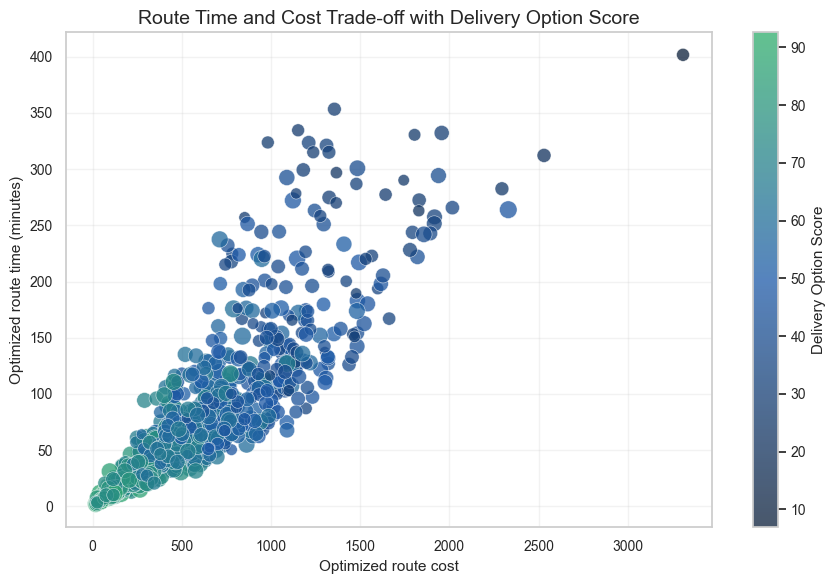

In [223]:
score_cmap = LinearSegmentedColormap.from_list(
    "score_cmap",
    [
        project_palette["navy"],
        project_palette["blue"],
        project_palette["green"]
    ]
)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    score_df["optimized_route_cost"],
    score_df["optimized_route_time_min"],
    c=score_df["delivery_option_score"],
    cmap=score_cmap,
    s=score_df["route_reliability_index"] * 180,
    alpha=0.75,
    edgecolors="white",
    linewidths=0.4
)

colorbar = plt.colorbar(scatter)
colorbar.set_label("Delivery Option Score")

plt.title("Route Time and Cost Trade-off with Delivery Option Score")
plt.xlabel("Optimized route cost")
plt.ylabel("Optimized route time (minutes)")

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


### Route time and cost trade-off observation

This scatter plot shows how optimized route cost and optimized route time are related to the final Delivery Option Score.

Most of the highest-scoring routes are concentrated in the lower-left area of the chart.
This means that routes with lower cost and shorter route time usually receive better scores.

A large part of the stronger options appear below around 1,000 in optimized route cost and below around 150 minutes in optimized route time.
Routes with very high cost or route time above 300 minutes tend to have lower scores and appear darker in the chart.

The size of each point represents the route reliability index, so larger points indicate more reliable route options.

Overall, this visualization shows that the score follows a logical pattern: it rewards routes that balance time, cost, estimated CO2, reliability, traffic and efficiency.

### Best route component profile

This radar chart shows the component profile of the best-ranked route option.


In [224]:
best_route = score_df.loc[score_df["delivery_option_score"].idxmax()].copy()

best_route_profile = pd.DataFrame({
    "component": [
        "Time",
        "Cost",
        "CO2",
        "Reliability",
        "Traffic",
        "Efficiency"
    ],
    "score": [
        best_route["time_score"],
        best_route["cost_score"],
        best_route["co2_score"],
        best_route["reliability_score"],
        best_route["traffic_score"],
        best_route["efficiency_score"]
    ]
})

fig = px.line_polar(
    best_route_profile,
    r="score",
    theta="component",
    line_close=True,
    range_r=[0, 100],
    title="Best Route Component Profile"
)

fig.update_traces(fill="toself")
fig.show()

best_route_profile


,component,score
0,Time,96.527691
1,Cost,97.881629
2,CO2,96.093003
3,Reliability,94.435076
4,Traffic,98.495250
5,Efficiency,19.634592


### Best route profile observation

The radar chart shows the component profile of the best-ranked route option.

`Route option 418` performs very strongly in time, cost, estimated CO2, reliability and traffic.

Its lowest component is efficiency, with a score of around 19.63.  
However, because efficiency has a small weight in the model, the route still receives the highest final score.

This is useful for presentation because it shows that even the best route is not perfect in every component.  
It is selected because it has the best overall balance.

## 5.6 Additional score views and decision matrix

In this part, I add a few extra views to make the Delivery Option Score easier to present.

The previous charts explain the score distribution, the top routes and the score components.  
Here, I add score summary cards, a score category chart, an alternative time-cost-score scatter plot and a decision matrix.

These outputs do not replace the original scoring logic.  
They make the result more practical and easier to explain in the final presentation.


### Score summary cards

The score summary cards give a quick overview of the final score results.

They are useful for a dashboard-style view because they show the average score, the best score, the lowest score and the best route option in one place.


In [225]:
# Score summary cards

best_score = score_df["delivery_option_score"].max()
average_score = score_df["delivery_option_score"].mean()
lowest_score = score_df["delivery_option_score"].min()
best_route_index = score_df["delivery_option_score"].idxmax()
best_route_label = f"Route option {best_route_index + 1}"

score_cards = [
    (
        "Average delivery option score",
        average_score,
        "out of 100",
        "General quality of the route options"
    ),
    (
        "Best delivery option score",
        best_score,
        "out of 100",
        "Highest balanced score in the dataset"
    ),
    (
        "Lowest delivery option score",
        lowest_score,
        "out of 100",
        "Weakest balanced option in the dataset"
    ),
    (
        "Best route option",
        best_route_label,
        "route",
        "Route with the highest final score"
    )
]

show_kpi_cards(score_cards)


### Score summary cards observation

The score cards summarize the final scoring result in a simple way.

The average Delivery Option Score is 60.80 out of 100.  
The best score is 92.62, while the lowest score is 6.88.

The best-ranked route is `Route option 418`.

This quick summary is useful for the final presentation because it gives the audience the main score results before showing the detailed charts and decision matrix.

### Score category distribution

This chart shows how all route options are distributed across the score categories.

It helps move from individual route scores to a dataset-level interpretation of the final Delivery Option Score.

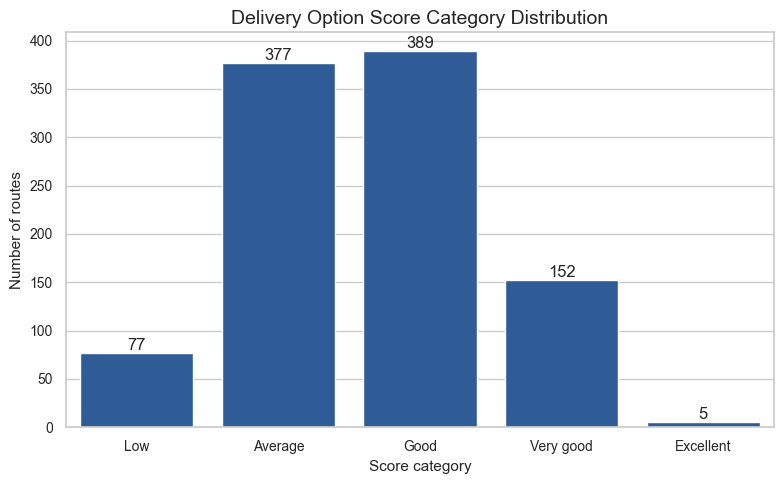

,score_category,routes
3,Low,77
1,Average,377
0,Good,389
2,Very good,152
4,Excellent,5


In [226]:
# Score category distribution chart

score_category_plot = score_category_counts.copy()
score_category_plot["score_category"] = score_category_plot["score_category"].astype(str)

category_order = ["Low", "Average", "Good", "Very good", "Excellent"]
score_category_plot["score_category"] = pd.Categorical(
    score_category_plot["score_category"],
    categories=category_order,
    ordered=True
)

score_category_plot = score_category_plot.sort_values("score_category")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=score_category_plot,
    x="score_category",
    y="routes",
    color=project_palette["blue"]
)

plt.title("Delivery Option Score Category Distribution")
plt.xlabel("Score category")
plt.ylabel("Number of routes")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

score_category_plot


### Score category distribution observation

The score category distribution helps interpret the final score at dataset level.

The largest category is `Good`, with 389 routes.  
The second largest category is `Average`, with 377 routes.

There are 152 routes in `Very good`, 77 routes in `Low`, and only 5 routes in `Excellent`.

This result is useful because it shows that the model is selective.  
It does not classify many routes as excellent, so the top category really represents a small group of high-performing options.


### Alternative time-cost-score scatter plot

This scatter plot gives another view of the relationship between route time, cost, final score and reliability.

The x-axis shows optimized route time, the y-axis shows optimized route cost, the color shows the final Delivery Option Score, and the marker size represents route reliability.

This makes the trade-off easier to see from a decision-making perspective.


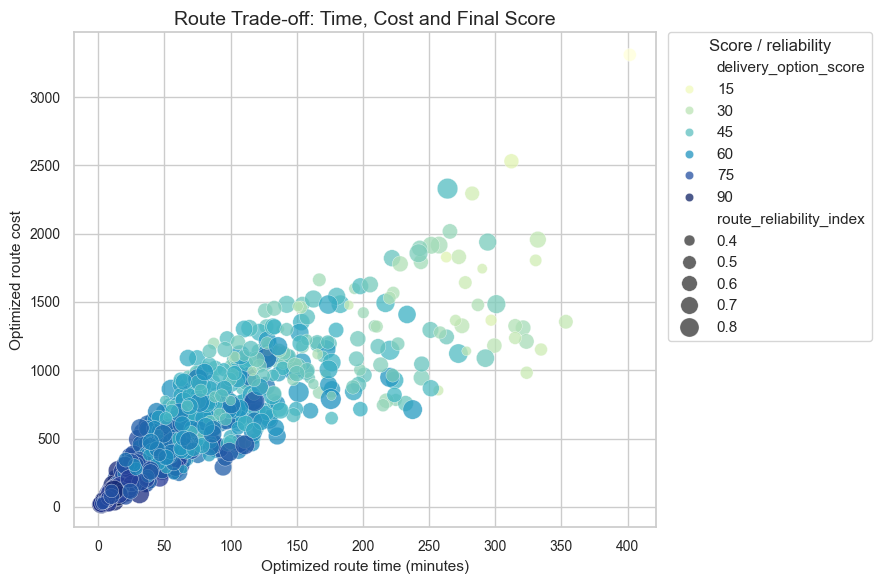

In [227]:
# Alternative time-cost-score scatter plot

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=score_df,
    x="optimized_route_time_min",
    y="optimized_route_cost",
    hue="delivery_option_score",
    size="route_reliability_index",
    palette="YlGnBu",
    sizes=(30, 220),
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3
)

plt.title("Route Trade-off: Time, Cost and Final Score")
plt.xlabel("Optimized route time (minutes)")
plt.ylabel("Optimized route cost")
plt.legend(
    title="Score / reliability",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()


### Route trade-off with score and reliability observation

This scatter plot shows the trade-off between optimized route time, optimized route cost, Delivery Option Score and route reliability.

Each point represents one route option.  
The x-axis shows optimized route time, and the y-axis shows optimized route cost.

The color shows the final Delivery Option Score, while the size of each point shows the route reliability index.

The chart shows that routes with shorter time and lower cost are mostly located in the lower-left area.  
These routes generally receive stronger final scores.

Routes with longer time and higher cost are located toward the upper-right area.  
These routes usually have weaker final scores because they are less efficient from an operational point of view.

The bubble size adds another useful layer.  
Larger bubbles represent routes with higher reliability, so this chart helps compare not only time and cost, but also how reliable each route is.

This visualization supports the main idea of the project: the best delivery option should balance several criteria at the same time, not only one metric.

### Decision matrix

The decision matrix compares different route choices depending on the business priority.

The best overall route is not always the same as the fastest, cheapest, most reliable or most efficient route.

This table makes the score more practical because it shows how different decision needs can lead to different route options.


In [228]:
# Decision matrix

decision_source = score_df.copy().reset_index().rename(columns={"index": "route_index"})
decision_source["route_option_id"] = decision_source["route_index"] + 1

best_overall = decision_source.loc[decision_source["delivery_option_score"].idxmax()]
best_for_speed = decision_source.loc[decision_source["optimized_route_time_min"].idxmin()]
best_for_cost = decision_source.loc[decision_source["optimized_route_cost"].idxmin()]
best_for_low_traffic = decision_source.loc[decision_source["traffic_density_index"].idxmin()]
best_for_reliability = decision_source.loc[decision_source["route_reliability_index"].idxmax()]
best_for_efficiency = decision_source.loc[decision_source["delivery_efficiency_score"].idxmax()]


def decision_row(label, row, reason):
    return {
        "Decision need": label,
        "Route option ID": int(row["route_option_id"]),
        "Route index": int(row["route_index"]),
        "Delivery Option Score": round(row["delivery_option_score"], 2),
        "Time (min)": round(row["optimized_route_time_min"], 2),
        "Cost": round(row["optimized_route_cost"], 2),
        "Estimated CO2 (kgCO2e)": round(row["estimated_co2_kgco2e"], 2),
        "Traffic index": round(row["traffic_density_index"], 3),
        "Reliability index": round(row["route_reliability_index"], 3),
        "Reason": reason
    }


route_decision_matrix = pd.DataFrame([
    decision_row(
        "Best overall balance",
        best_overall,
        "Highest final score after combining all criteria."
    ),
    decision_row(
        "Best for speed",
        best_for_speed,
        "Lowest optimized route time."
    ),
    decision_row(
        "Best for cost",
        best_for_cost,
        "Lowest optimized route cost."
    ),
    decision_row(
        "Best for low traffic",
        best_for_low_traffic,
        "Lowest traffic density index."
    ),
    decision_row(
        "Best for reliability",
        best_for_reliability,
        "Highest route reliability index."
    ),
    decision_row(
        "Best for efficiency",
        best_for_efficiency,
        "Highest delivery efficiency score."
    )
])

display_styled_table(
    route_decision_matrix,
    caption="Route Decision Matrix",
    max_rows=10,
    format_dict={
        "Delivery Option Score": "{:.2f}",
        "Time (min)": "{:.2f}",
        "Cost": "{:.2f}",
        "Estimated CO2 (kgCO2e)": "{:.2f}",
        "Traffic index": "{:.3f}",
        "Reliability index": "{:.3f}"
    }
)

Decision need,Route option ID,Route index,Delivery Option Score,Time (min),Cost,Estimated CO2 (kgCO2e),Traffic index,Reliability index,Reason
Best overall balance,418,417,92.62,15.33,85.07,2.04,0.216,0.863,Highest final score after combining all criteria.
Best for speed,715,714,88.95,1.43,16.70,0.75,0.471,0.669,Lowest optimized route time.
Best for cost,350,349,88.12,2.32,15.29,1.05,0.668,0.729,Lowest optimized route cost.
Best for low traffic,80,79,56.52,153.95,1059.67,27.18,0.204,0.742,Lowest traffic density index.
Best for reliability,158,157,84.48,22.26,143.37,12.63,0.257,0.896,Highest route reliability index.
Best for efficiency,715,714,88.95,1.43,16.70,0.75,0.471,0.669,Highest delivery efficiency score.


,Decision need,Route option ID,Route index,Delivery Option Score,Time (min),Cost,Estimated CO2 (kgCO2e),Traffic index,Reliability index,Reason
0,Best overall balance,418,417,92.62,15.33,85.07,2.04,0.216,0.863,Highest final score after combining all criteria.
1,Best for speed,715,714,88.95,1.43,16.70,0.75,0.471,0.669,Lowest optimized route time.
2,Best for cost,350,349,88.12,2.32,15.29,1.05,0.668,0.729,Lowest optimized route cost.
3,Best for low traffic,80,79,56.52,153.95,1059.67,27.18,0.204,0.742,Lowest traffic density index.
4,Best for reliability,158,157,84.48,22.26,143.37,12.63,0.257,0.896,Highest route reliability index.
5,Best for efficiency,715,714,88.95,1.43,16.70,0.75,0.471,0.669,Highest delivery efficiency score.


### Decision matrix observation

The decision matrix shows why the final score is useful.

Different business priorities can lead to different route choices.

The best overall route is `Route option 418`, with a score of 92.62.  
The fastest route is `Route option 715`, with a time of only 1.43 minutes and a score of 88.95.  
The cheapest route is `Route option 350`, with a cost of 15.29 and a score of 88.12.

The best low-traffic route is different again.  
`Route option 80` has the lowest traffic index, but its final score is only 56.52 because it has a much longer time and higher cost.

The best route for reliability is `Route option 158`, with a score of 84.48.  
The best route for efficiency is again `Route option 715`, which is also the fastest route.

This supports the main message of the project: route planning should not be based on one metric alone.

### Decision matrix score comparison

This chart compares the Delivery Option Score for each decision need in the decision matrix.

It helps present the matrix visually and makes it easier to see how each selected route performs according to the final scoring model.


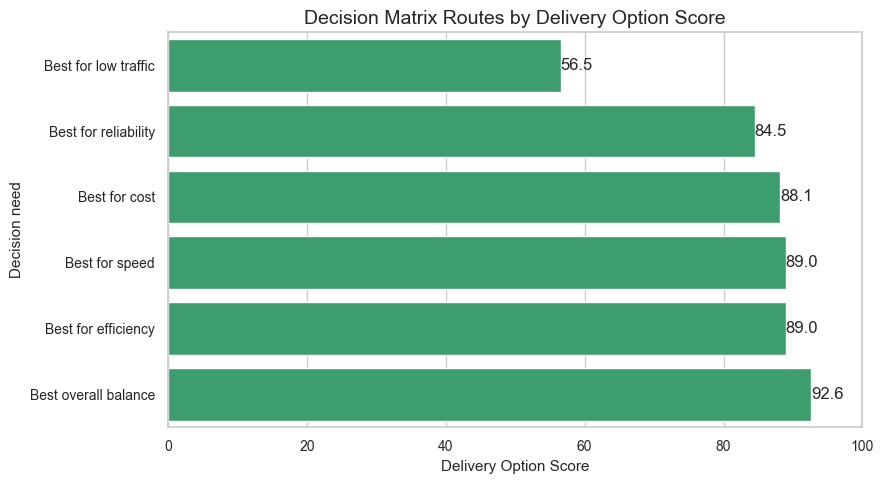

In [229]:
# Decision matrix score comparison

matrix_score_plot = route_decision_matrix.sort_values(
    "Delivery Option Score",
    ascending=True
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=matrix_score_plot,
    x="Delivery Option Score",
    y="Decision need",
    color=project_palette["green"]
)

plt.title("Decision Matrix Routes by Delivery Option Score")
plt.xlabel("Delivery Option Score")
plt.ylabel("Decision need")
plt.xlim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()


### Decision matrix score comparison observation

The decision matrix score comparison shows that the best route for a specific need is not always the best overall route.

`Route option 418` has the highest overall score because it balances the different criteria well.

However, `Route option 715` is better if the only priority is speed, and `Route option 350` is better if the only priority is cost.

The chart also shows that the best low-traffic route has a much lower final score than the best overall route.  
This means that optimizing only one factor can create weaker results in other parts of the delivery decision.

This is important because the Delivery Option Score is a balanced decision-support indicator.  
It helps compare options, but the final business choice can still depend on the main priority.

## 5.7 Save Delivery Option Score outputs

In this step, I save the final score results as CSV files.

These files can be used later in the README, the final presentation, or a future Power BI dashboard.

I save three outputs:

- the full Delivery Option Score results
- the top delivery options
- the decision matrix


In [230]:
# 5.7 Save Delivery Option Score outputs

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Prepare the full Delivery Option Score output

score_df_output = score_df.copy()

score_df_output["route_index"] = score_df_output.index
score_df_output["route_option_id"] = score_df_output["route_index"] + 1
score_df_output["route_label"] = (
    "Route option " + score_df_output["route_option_id"].astype(str)
)

score_output_columns = [
    "route_label",
    "route_index",
    "route_option_id",
    "distance_km",
    "optimized_route_time_min",
    "optimized_route_cost",
    "traffic_density_index",
    "estimated_co2_kgco2e",
    "delivery_efficiency_score",
    "route_reliability_index",
    "time_score",
    "cost_score",
    "co2_score",
    "reliability_score",
    "traffic_score",
    "efficiency_score",
    "delivery_option_score",
    "score_rank",
    "score_category"
]

delivery_score_results_export = (
    score_df_output[score_output_columns]
    .sort_values("delivery_option_score", ascending=False)
    .copy()
)

delivery_score_results_export.to_csv(
    OUTPUT_DIR / "delivery_option_score_results.csv",
    index=False
)

# 2. Prepare and display the Top 10 Delivery Options output

top_delivery_options_export = top_delivery_options[top_score_columns].copy()

_ = display_styled_table(
    top_delivery_options_export,
    caption="Top 10 Delivery Options",
    format_dict={
        "distance_km": "{:.2f}",
        "optimized_route_time_min": "{:.2f}",
        "optimized_route_cost": "{:.2f}",
        "traffic_density_index": "{:.3f}",
        "estimated_co2_kgco2e": "{:.2f}",
        "delivery_efficiency_score": "{:.4f}",
        "route_reliability_index": "{:.3f}",
        "delivery_option_score": "{:.2f}"
    }
)

top_delivery_options_export.to_csv(
    OUTPUT_DIR / "top_delivery_options.csv",
    index=False
)

# 3. Save the decision matrix output

route_decision_matrix_export = route_decision_matrix.copy()

route_decision_matrix_export.to_csv(
    OUTPUT_DIR / "route_decision_matrix.csv",
    index=False
)


# 4. Confirmation message

print("Delivery Option Score outputs saved successfully.")
print("Output folder: data/outputs")
print("- delivery_option_score_results.csv")
print("- top_delivery_options.csv")
print("- route_decision_matrix.csv")


route_label,route_index,route_option_id,distance_km,optimized_route_time_min,optimized_route_cost,traffic_density_index,estimated_co2_kgco2e,delivery_efficiency_score,route_reliability_index,delivery_option_score,score_rank,score_category
Route option 418,417,418,2.91,15.33,85.07,0.216,2.04,0.2449,0.863,92.62,1,Excellent
Route option 343,342,343,4.93,13.78,76.91,0.215,3.45,0.2030,0.875,91.97,2,Excellent
Route option 132,131,132,1.62,5.61,31.61,0.341,1.13,0.4539,0.796,91.12,3,Excellent
Route option 65,64,65,3.55,4.90,38.49,0.291,2.48,0.3390,0.809,90.73,4,Excellent
Route option 422,421,422,2.14,4.12,46.86,0.312,1.50,0.5859,0.756,90.38,5,Excellent
Route option 250,249,250,6.63,11.43,118.36,0.258,4.64,0.3218,0.843,89.83,6,Very good
Route option 693,692,693,1.49,2.90,26.65,0.211,1.04,0.2564,0.723,89.72,7,Very good
Route option 654,653,654,3.57,11.42,100.05,0.213,2.50,0.2415,0.765,89.12,8,Very good
Route option 715,714,715,1.07,1.43,16.70,0.471,0.75,1.2346,0.669,88.95,9,Very good
Route option 972,971,972,8.99,11.82,122.48,0.209,6.29,0.2340,0.833,88.50,10,Very good


Delivery Option Score outputs saved successfully.
Output folder: data/outputs
- delivery_option_score_results.csv
- top_delivery_options.csv
- route_decision_matrix.csv


### Saved score outputs

The table above shows the top delivery options based on the final Delivery Option Score.

The results were also saved into three CSV files:

* `delivery_option_score_results.csv`: full score results for all route options
* `top_delivery_options.csv`: the best route options based on the final score
* `route_decision_matrix.csv`: selected routes for different decision needs, such as speed, cost, traffic, reliability and efficiency

These files make the final results easier to review, export and use in the final project documentation.


## 5.8 Delivery Option Score limitations

The Delivery Option Score is an educational scoring model.

It is useful for this project because it combines the main KPI ideas into one final decision-support output.

However, it has limitations:

- the route planning and carbon datasets are not directly connected
- estimated CO2 is calculated using an average emission factor per kilometer
- the weights are selected for educational purposes
- the score is not a real commercial route optimization algorithm
- external factors such as real-time traffic, driver availability and exact vehicle assignment are not included
- the efficiency score is sensitive to extreme values because it uses min-max normalization

For these reasons, the score should be interpreted as a simple analytical tool, not as a production-ready logistics system.

## 5.9 Final Delivery Option Score interpretation

The Delivery Option Score is the final analytical output of the project.

It combines time, cost, estimated CO2, reliability, traffic and efficiency into one simple score.

The average score is 60.80, and the best score is 92.62.  
Most routes are classified as `Average` or `Good`, while only 5 routes reach the `Excellent` category.

The best overall route is `Route option 418`.  
It is not selected only because of one factor.  
It ranks first because it has a strong balance between short distance, low estimated CO2, good reliability, low traffic and good time-cost performance.

The decision matrix also shows that different priorities can lead to different route choices.  
The fastest route, the cheapest route, the most reliable route and the best overall route are not always the same.

This section connects the full project workflow:

- data cleaning prepared the datasets
- EDA explained the main patterns
- KPI calculation summarized the important indicators
- Delivery Option Score combined the indicators into a practical ranking

The score is simple, transparent and easy to explain.  
This makes it suitable for a final Data Analysis project and for a presentation to a non-technical audience.

The most important conclusion is that a good delivery option should not be selected based on one KPI only.  
It should balance speed, cost, sustainability, reliability and traffic context.


# 6. Final Improvements, Conclusions and Future Work

This final section adds targeted improvements to make the project stronger for the final presentation.

The focus is still simple and explainable:

1. Use a valid Barcelona traffic interpretation by excluding `No data`.
2. Add CO2 emission intensity per kilometre.
3. Add a simple green fleet transition scenario.
4. Add a small congestion impact analysis from the tracking dataset.
5. Add statistical and visual validation for the most important relationships.
6. Summarize the final conclusions, limitations and future work.


## 6.1 Improved Barcelona TRAMS interpretation

In the first version of the traffic analysis, `Status 0` appeared as the most common traffic status.  
However, in the TRAMS dataset, `0` means `No data`, so it should not be interpreted as a real traffic condition.

In this section, I use only valid traffic records to calculate a cleaner Barcelona traffic summary.


In [231]:
# Improved Barcelona TRAMS traffic interpretation

traffic_status_map = {
    0: "No data",
    1: "Very fluid",
    2: "Fluid",
    3: "Dense",
    4: "Very dense",
    5: "Congestion",
    6: "Section closed"
}

trams_clean["actual_status_label"] = trams_clean["estatactual"].map(traffic_status_map)
trams_clean["predicted_status_label"] = trams_clean["estatprevist"].map(traffic_status_map)

trams_valid = trams_clean[trams_clean["estatactual"] != 0].copy()

barcelona_valid_status_summary = (
    trams_valid["actual_status_label"]
    .value_counts()
    .reset_index()
)

barcelona_valid_status_summary.columns = ["traffic_status", "records"]

barcelona_valid_status_summary["share_pct"] = (
    barcelona_valid_status_summary["records"] /
    barcelona_valid_status_summary["records"].sum() * 100
)

barcelona_valid_status_summary


,traffic_status,records,share_pct
0,Fluid,3119539,50.722034
1,Very fluid,2009204,32.668581
2,Dense,599815,9.752671
3,Very dense,238407,3.876370
4,Congestion,118459,1.926080
5,Section closed,64840,1.054264


In [232]:
# Monthly valid traffic and high congestion summary

barcelona_monthly_valid_summary = (
    trams_clean
    .assign(
        is_valid_traffic=lambda df: df["estatactual"] != 0,
        is_high_congestion=lambda df: df["estatactual"].isin([4, 5])
    )
    .groupby("month")
    .agg(
        total_records=("idtram", "count"),
        valid_records=("is_valid_traffic", "sum"),
        high_congestion_records=("is_high_congestion", "sum")
    )
    .reset_index()
)

barcelona_monthly_valid_summary["valid_records_share_pct"] = (
    barcelona_monthly_valid_summary["valid_records"] /
    barcelona_monthly_valid_summary["total_records"] * 100
)

barcelona_monthly_valid_summary["high_congestion_share_of_valid_pct"] = (
    barcelona_monthly_valid_summary["high_congestion_records"] /
    barcelona_monthly_valid_summary["valid_records"] * 100
)

barcelona_monthly_valid_summary


,month,total_records,valid_records,high_congestion_records,valid_records_share_pct,high_congestion_share_of_valid_pct
0,1,2158324,1130748,54563,52.390095,4.825390
1,2,1942864,1017848,63128,52.389050,6.202105
2,3,2136512,1093976,61512,51.203831,5.622792
3,4,2282812,1199952,71209,52.564644,5.934321
4,5,2381232,1293916,79327,54.338091,6.130769
5,6,759696,413824,27127,54.472315,6.555202


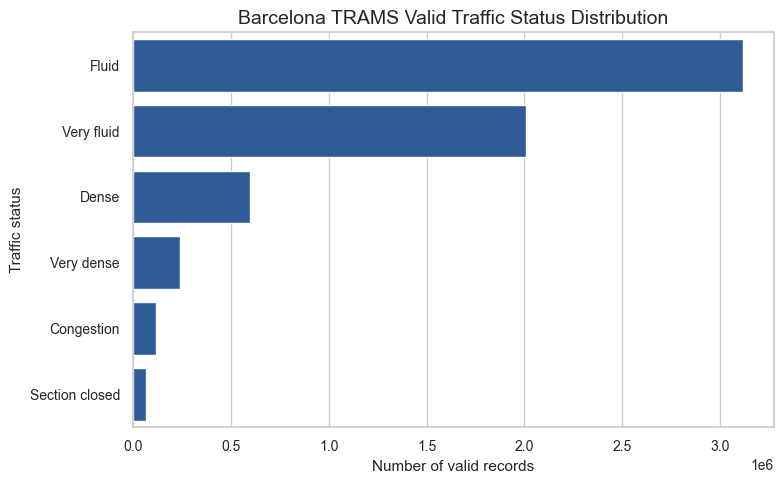

In [233]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=barcelona_valid_status_summary,
    x="records",
    y="traffic_status",
    color=project_palette["blue"]
)

plt.title("Barcelona TRAMS Valid Traffic Status Distribution")
plt.xlabel("Number of valid records")
plt.ylabel("Traffic status")

plt.tight_layout()
plt.show()


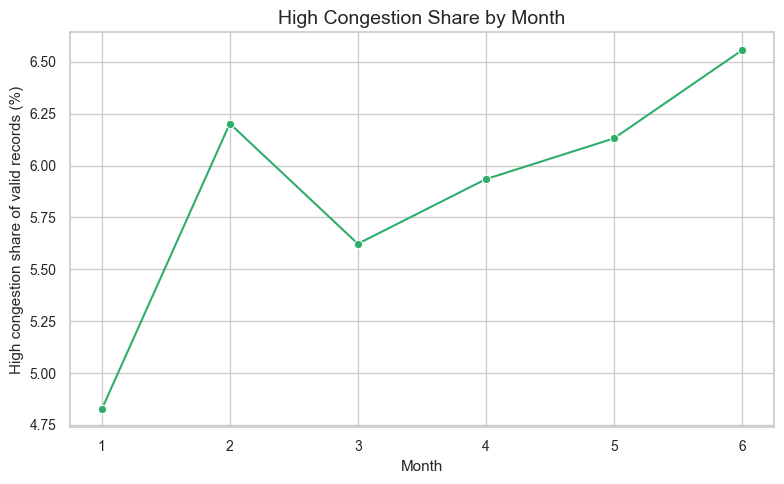

In [234]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=barcelona_monthly_valid_summary,
    x="month",
    y="high_congestion_share_of_valid_pct",
    marker="o",
    color=project_palette["green"]
)

plt.title("High Congestion Share by Month")
plt.xlabel("Month")
plt.ylabel("High congestion share of valid records (%)")
plt.xticks(barcelona_monthly_valid_summary["month"])

plt.tight_layout()
plt.show()


### Barcelona traffic improvement observation

After excluding `No data`, the most common valid traffic status is `Fluid`, with around 50.72% of valid records.

The second most common status is `Very fluid`, with around 32.67% of valid records.

This means that most valid TRAMS records show relatively fluid traffic conditions.  
However, the dataset also includes more difficult conditions such as `Dense`, `Very dense` and `Congestion`.

The high congestion share is around 5.80% of valid records.  
This gives a cleaner city-level indicator of how often Barcelona road sections appear as `Very dense` or `Congestion`.

This analysis is not used as a direct route-level input.  
It is used as real urban context for the importance of traffic-aware delivery planning.

## 6.2 CO2 emission intensity

Total CO2 emissions are useful, but they are strongly affected by distance.  
To compare vehicle types more fairly, I add an emission intensity metric:

`emission_intensity_kgco2e_per_km = Carbon_Emission_kgCO2e / Distance_KM`

This shows how much CO2 is produced per kilometre.


In [235]:
# Add emission intensity per kilometre

carbon_clean["emission_intensity_kgco2e_per_km"] = (
    carbon_clean["carbon_emission_kgco2e"] / carbon_clean["distance_km"]
)

emission_intensity_by_vehicle = (
    carbon_clean
    .groupby("vehicle_type")
    .agg(
        deliveries=("transaction_id", "count"),
        avg_distance_km=("distance_km", "mean"),
        avg_co2_kg=("carbon_emission_kgco2e", "mean"),
        avg_emission_intensity_kgco2e_per_km=("emission_intensity_kgco2e_per_km", "mean"),
        eco_friendly_rate=("is_eco_friendly", "mean")
    )
    .reset_index()
    .sort_values("avg_emission_intensity_kgco2e_per_km")
)

emission_intensity_by_vehicle


,vehicle_type,deliveries,avg_distance_km,avg_co2_kg,avg_emission_intensity_kgco2e_per_km,eco_friendly_rate
0,Cargo Bicycle,1710,7.986725,0.000000,0.000000,1.0
3,Drone Delivery,1664,7.828065,0.064592,0.008221,1.0
4,Electric Van (EV),1750,78.753314,4.059115,0.051534,1.0
6,Motorcycle (Courier),1723,22.287174,2.505052,0.112014,0.0
2,Diesel Van (Euro 6),1731,79.879318,17.115735,0.214802,0.0
1,Diesel Van (Euro 4),1743,81.643660,25.913168,0.316825,0.0
5,Heavy Truck,1679,447.134366,463.138771,1.035397,0.0


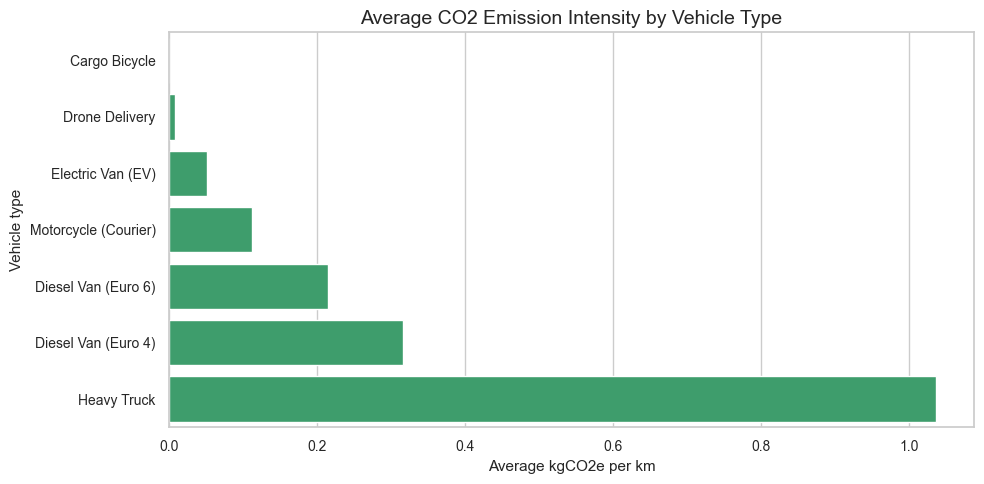

In [236]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=emission_intensity_by_vehicle,
    x="avg_emission_intensity_kgco2e_per_km",
    y="vehicle_type",
    color=project_palette["green"]
)

plt.title("Average CO2 Emission Intensity by Vehicle Type")
plt.xlabel("Average kgCO2e per km")
plt.ylabel("Vehicle type")

plt.tight_layout()
plt.show()


### Emission intensity observation

Emission intensity makes the sustainability comparison clearer because it measures CO2 emissions per kilometre.

Cargo bicycles have zero direct emissions in this dataset.  
Drone delivery and electric vans also have much lower average emissions per kilometre than diesel vans and heavy trucks.

The average emission intensity is around:

- `Cargo Bicycle`: 0.000 kgCO2e/km
- `Drone Delivery`: 0.008 kgCO2e/km
- `Electric Van (EV)`: 0.052 kgCO2e/km
- `Diesel Van (Euro 6)`: 0.215 kgCO2e/km
- `Diesel Van (Euro 4)`: 0.317 kgCO2e/km
- `Heavy Truck`: 1.035 kgCO2e/km

This metric is useful for the final presentation because it shows that sustainability should be evaluated not only by total emissions, but also by emissions per kilometre.

## 6.3 Green fleet transition scenario

To make the sustainability analysis more business-oriented, I add a simple scenario:

**What if 50% of Diesel Van trips were replaced by Electric Van trips?**

This is not a real operational plan. It is a simplified educational scenario to estimate the potential CO2 reduction from moving part of the fleet to greener alternatives.


In [237]:
# Scenario: replace 50% of Diesel Van trips with Electric Van trips

diesel_trips = carbon_clean[
    carbon_clean["vehicle_type"].str.contains("Diesel Van", case=False, na=False)
].copy()

ev_intensity = emission_intensity_by_vehicle.loc[
    emission_intensity_by_vehicle["vehicle_type"] == "Electric Van (EV)",
    "avg_emission_intensity_kgco2e_per_km"
].iloc[0]

replacement_share = 0.50

current_emissions_for_replaced_trips = (
    diesel_trips["carbon_emission_kgco2e"].sum() * replacement_share
)

replaced_distance_km = diesel_trips["distance_km"].sum() * replacement_share

estimated_ev_emissions = replaced_distance_km * ev_intensity

estimated_co2_saved = current_emissions_for_replaced_trips - estimated_ev_emissions

estimated_saving_pct = (
    estimated_co2_saved / current_emissions_for_replaced_trips * 100
)

green_fleet_scenario = pd.DataFrame({
    "scenario": ["Replace 50% of Diesel Van trips with Electric Van"],
    "diesel_trips_total": [len(diesel_trips)],
    "replacement_share_pct": [replacement_share * 100],
    "current_emissions_for_replaced_trips_kgco2e": [current_emissions_for_replaced_trips],
    "estimated_ev_emissions_kgco2e": [estimated_ev_emissions],
    "estimated_co2_saved_kgco2e": [estimated_co2_saved],
    "estimated_saving_pct": [estimated_saving_pct]
})

green_fleet_scenario


,scenario,diesel_trips_total,replacement_share_pct,current_emissions_for_replaced_trips_kgco2e,estimated_ev_emissions_kgco2e,estimated_co2_saved_kgco2e,estimated_saving_pct
0,Replace 50% of Diesel Van trips with Electric Van,3474,50.0,37396.9945,7229.667875,30167.326625,80.667784


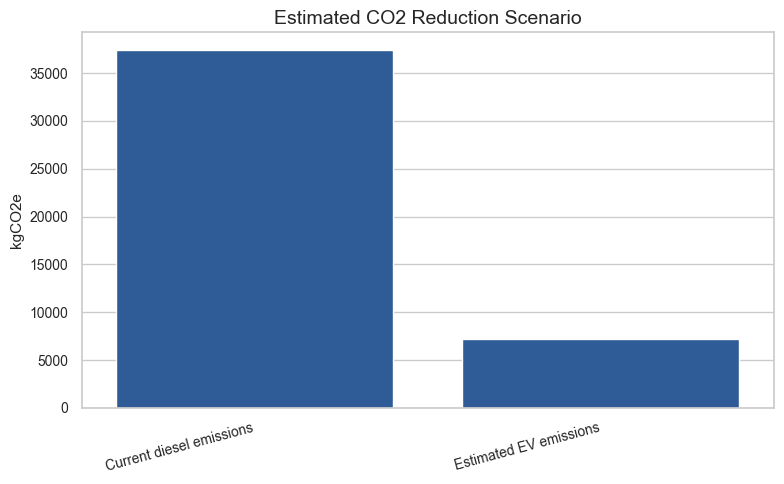

In [238]:
scenario_plot = pd.DataFrame({
    "Scenario": ["Current diesel emissions", "Estimated EV emissions"],
    "kgCO2e": [
        current_emissions_for_replaced_trips,
        estimated_ev_emissions
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=scenario_plot,
    x="Scenario",
    y="kgCO2e",
    color=project_palette["blue"]
)

plt.title("Estimated CO2 Reduction Scenario")
plt.xlabel("")
plt.ylabel("kgCO2e")
plt.xticks(rotation=15, ha="right")

plt.tight_layout()
plt.show()


### Green fleet scenario observation

The green fleet transition scenario estimates what could happen if 50% of Diesel Van trips were replaced by Electric Van trips.

In this simplified scenario, 3,474 Diesel Van trips are considered.

For the replaced trips, the current diesel emissions are around 37,396.99 kgCO2e.  
If these trips were estimated using the Electric Van emission intensity, the emissions would be around 7,229.67 kgCO2e.

This gives an estimated CO2 saving of around 30,167.33 kgCO2e, or about 80.67%.

This result should be interpreted as an educational estimate, not as a final operational recommendation.

The purpose is to show how logistics data can support sustainability decisions and how this type of scenario analysis could be expanded in future work.

## 6.4 Congestion impact from the tracking dataset

The Transportation and Logistics Tracking file includes a small sheet with delivery time with and without congestion.

I use it as a supporting analysis to show how congestion can affect delivery efficiency.


In [239]:
# Read the congestion comparison sheet from the tracking Excel file

tracking_congestion = pd.read_excel(tracking_path, sheet_name="Q5")

tracking_congestion = tracking_congestion.rename(columns={
    "City,,": "city",
    "Delivery_Time_Without_Congestion": "delivery_time_without_congestion",
    "Delivery_Time_With_Congestion": "delivery_time_with_congestion"
})

tracking_congestion["congestion_delay_min"] = (
    tracking_congestion["delivery_time_with_congestion"] -
    tracking_congestion["delivery_time_without_congestion"]
)

tracking_congestion["congestion_delay_pct"] = (
    tracking_congestion["congestion_delay_min"] /
    tracking_congestion["delivery_time_without_congestion"] * 100
)

congestion_impact_summary = (
    tracking_congestion
    .groupby("city")
    .agg(
        avg_without_congestion_min=("delivery_time_without_congestion", "mean"),
        avg_with_congestion_min=("delivery_time_with_congestion", "mean"),
        avg_congestion_delay_min=("congestion_delay_min", "mean"),
        avg_congestion_delay_pct=("congestion_delay_pct", "mean")
    )
    .reset_index()
    .sort_values("avg_congestion_delay_pct", ascending=False)
)

congestion_impact_summary


,city,avg_without_congestion_min,avg_with_congestion_min,avg_congestion_delay_min,avg_congestion_delay_pct
0,Bangalore,76.5,164.2,87.7,114.876142
1,Mumbai,67.6,141.5,73.9,109.509050


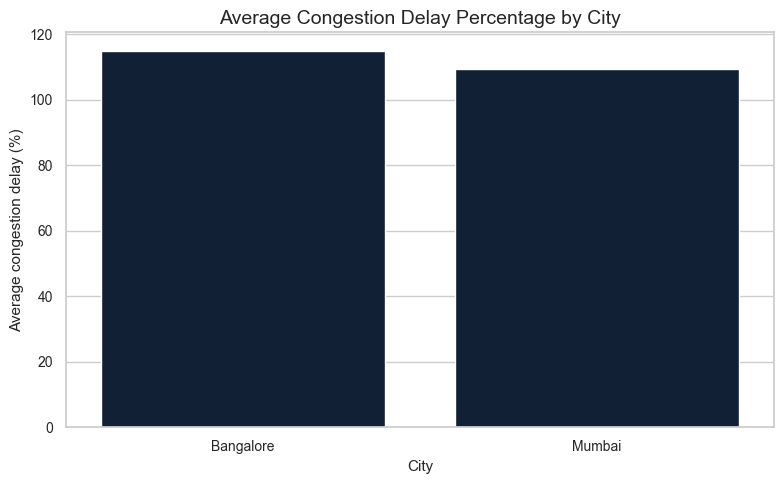

In [240]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=congestion_impact_summary,
    x="city",
    y="avg_congestion_delay_pct",
    color=project_palette["navy"]
)

plt.title("Average Congestion Delay Percentage by City")
plt.xlabel("City")
plt.ylabel("Average congestion delay (%)")

plt.tight_layout()
plt.show()


### Congestion impact observation

The supporting tracking data shows that congestion can strongly increase delivery time.

In the small comparison table, Bangalore has an average congestion delay of around 87.7 minutes, which represents an increase of about 114.88%.

Mumbai has an average congestion delay of around 73.9 minutes, which represents an increase of about 109.51%.

This means that, in this supporting dataset, congestion can more than double delivery time.

This supports the project idea that delivery decisions should consider traffic conditions, not only distance or cost.

## 6.5 Statistical and visual validation

This section adds a small validation layer to the project.

The goal is not to build a complex statistical model.  
The goal is to check whether the most important relationships seen in the charts are also supported by simple statistical summaries.

I use this section to connect the project with the statistical and visualization concepts from the previous sprints:

- Spearman correlation for numerical relationships
- Kruskal-Wallis tests for group differences in CO2 emissions
- IQR outlier checks for skewed variables
- heatmaps for component profiles and interaction patterns
- grouped bar charts for reliability patterns


### 6.5.1 Statistical relationship checks

In this step, I use Spearman correlation to check the direction and strength of important numerical relationships.

I use Spearman correlation because the project data includes skewed distributions and outliers.  
This makes Spearman more suitable than assuming a perfect linear relationship.


In [241]:
# Statistical relationship checks using Spearman correlation

def calculate_spearman(df, x_col, y_col, relationship_name):
    data = df[[x_col, y_col]].dropna()

    rho, p_value = spearmanr(data[x_col], data[y_col])

    return {
        "relationship": relationship_name,
        "x_variable": x_col,
        "y_variable": y_col,
        "records_used": len(data),
        "spearman_rho": rho,
        "p_value": p_value
    }

statistical_relationship_checks = pd.DataFrame([
    calculate_spearman(
        route_clean,
        "distance_km",
        "optimized_route_time_min",
        "Route distance vs optimized route time"
    ),
    calculate_spearman(
        route_clean,
        "traffic_density_index",
        "route_reliability_index",
        "Traffic density vs route reliability"
    ),
    calculate_spearman(
        carbon_clean,
        "distance_km",
        "carbon_emission_kgco2e",
        "Carbon distance vs CO2 emissions"
    ),
    calculate_spearman(
        score_df,
        "optimized_route_time_min",
        "delivery_option_score",
        "Delivery Option Score vs optimized route time"
    ),
    calculate_spearman(
        score_df,
        "optimized_route_cost",
        "delivery_option_score",
        "Delivery Option Score vs optimized route cost"
    ),
    calculate_spearman(
        score_df,
        "estimated_co2_kgco2e",
        "delivery_option_score",
        "Delivery Option Score vs estimated CO2"
    )
])

statistical_relationship_checks["abs_spearman_rho"] = (
    statistical_relationship_checks["spearman_rho"].abs()
)

statistical_relationship_checks = (
    statistical_relationship_checks
    .sort_values("abs_spearman_rho", ascending=False)
    .drop(columns="abs_spearman_rho")
)

display_styled_table(
    statistical_relationship_checks,
    caption="Statistical Relationship Checks",
    format_dict={
        "spearman_rho": "{:.2f}",
        "p_value": "{:.2e}"
    }
)

relationship,x_variable,y_variable,records_used,spearman_rho,p_value
Carbon distance vs CO2 emissions,distance_km,carbon_emission_kgco2e,12000,0.93,0.00e+00
Delivery Option Score vs optimized route cost,optimized_route_cost,delivery_option_score,1000,-0.85,2.97e-275
Delivery Option Score vs estimated CO2,estimated_co2_kgco2e,delivery_option_score,1000,-0.84,3.83e-263
Delivery Option Score vs optimized route time,optimized_route_time_min,delivery_option_score,1000,-0.83,1.51e-252
Route distance vs optimized route time,distance_km,optimized_route_time_min,1000,0.81,1.99e-231
Traffic density vs route reliability,traffic_density_index,route_reliability_index,1000,-0.71,3.33e-156


,relationship,x_variable,y_variable,records_used,spearman_rho,p_value
2,Carbon distance vs CO2 emissions,distance_km,carbon_emission_kgco2e,12000,0.932072,0.000000e+00
4,Delivery Option Score vs optimized route cost,optimized_route_cost,delivery_option_score,1000,-0.846329,2.968124e-275
5,Delivery Option Score vs estimated CO2,estimated_co2_kgco2e,delivery_option_score,1000,-0.836643,3.831628e-263
3,Delivery Option Score vs optimized route time,optimized_route_time_min,delivery_option_score,1000,-0.827613,1.512436e-252
0,Route distance vs optimized route time,distance_km,optimized_route_time_min,1000,0.807906,1.989300e-231
1,Traffic density vs route reliability,traffic_density_index,route_reliability_index,1000,-0.713246,3.326049e-156


### Spearman relationship strength chart

To make the statistical relationship checks easier to present, I also visualize the strength and direction of the Spearman correlations.

This chart helps compare which relationships are stronger and whether they are positive or negative.

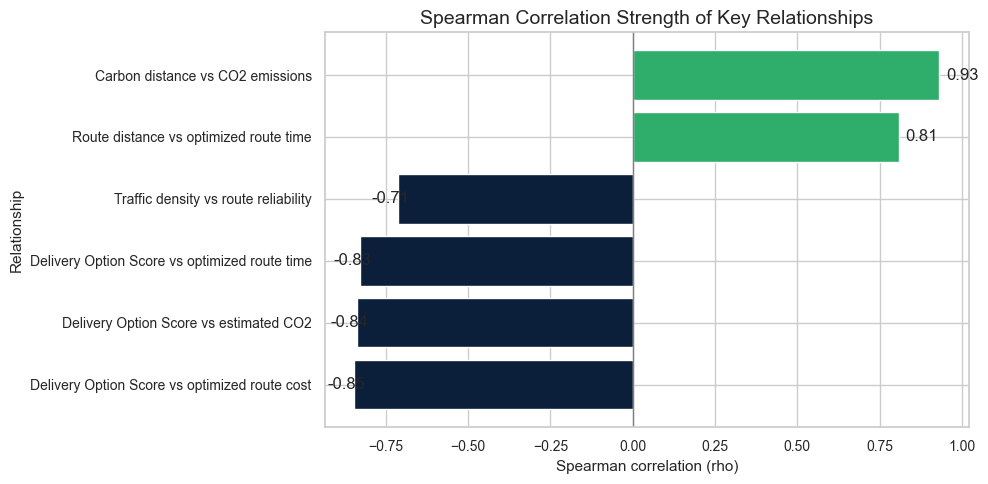

In [242]:
# Spearman relationship strength chart

spearman_chart = statistical_relationship_checks.copy()
spearman_chart = spearman_chart.sort_values("spearman_rho")

bar_colors = [
    project_palette["green"] if value >= 0 else project_palette["navy"]
    for value in spearman_chart["spearman_rho"]
]

plt.figure(figsize=(10, 5))

bars = plt.barh(
    spearman_chart["relationship"],
    spearman_chart["spearman_rho"],
    color=bar_colors
)

plt.axvline(0, color="gray", linewidth=1)
plt.title("Spearman Correlation Strength of Key Relationships")
plt.xlabel("Spearman correlation (rho)")
plt.ylabel("Relationship")

for bar, value in zip(bars, spearman_chart["spearman_rho"]):
    plt.text(
        value + (0.02 if value >= 0 else -0.08),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Spearman relationship strength chart observation

The Spearman chart shows both the strength and the direction of the key relationships.

The strongest positive relationship is between distance and CO2 emissions, with a Spearman correlation of around 0.93.  
This means that longer distances are strongly associated with higher CO2 emissions in the carbon dataset.

Route distance also has a strong positive relationship with optimized route time, around 0.81.  
This confirms that longer routes usually take more time.

Traffic density has a strong negative relationship with route reliability, around -0.71.  
This means that higher traffic density is associated with lower route reliability.

The Delivery Option Score has strong negative relationships with route cost, estimated CO2 and route time.  
The strongest one is with route cost, around -0.85, followed by estimated CO2 around -0.84 and route time around -0.83.

This is useful because it shows that the final score behaves logically.  
Routes with higher time, higher cost or higher estimated CO2 usually receive lower scores.


In [243]:
# Kruskal-Wallis tests for CO2 differences across groups

def calculate_kruskal(df, group_col, value_col, test_name):
    grouped_values = [
        group[value_col].dropna()
        for _, group in df.groupby(group_col)
    ]

    h_statistic, p_value = kruskal(*grouped_values)

    return {
        "test": test_name,
        "group_column": group_col,
        "value_column": value_col,
        "number_of_groups": len(grouped_values),
        "h_statistic": h_statistic,
        "p_value": p_value
    }

kruskal_test_summary = pd.DataFrame([
    calculate_kruskal(
        carbon_clean,
        "vehicle_type",
        "carbon_emission_kgco2e",
        "CO2 emissions by vehicle type"
    ),
    calculate_kruskal(
        carbon_clean,
        "route_type",
        "carbon_emission_kgco2e",
        "CO2 emissions by route type"
    ),
    calculate_kruskal(
        carbon_clean,
        "traffic_conditions",
        "carbon_emission_kgco2e",
        "CO2 emissions by traffic conditions"
    )
])

display_styled_table(
    kruskal_test_summary,
    caption="Kruskal-Wallis Test Summary",
    format_dict={
        "h_statistic": "{:.2f}",
        "p_value": "{:.2e}"
    }
)

test,group_column,value_column,number_of_groups,h_statistic,p_value
CO2 emissions by vehicle type,vehicle_type,carbon_emission_kgco2e,7,11190.48,0.00e+00
CO2 emissions by route type,route_type,carbon_emission_kgco2e,4,10196.09,0.00e+00
CO2 emissions by traffic conditions,traffic_conditions,carbon_emission_kgco2e,4,41.17,6.01e-09


,test,group_column,value_column,number_of_groups,h_statistic,p_value
0,CO2 emissions by vehicle type,vehicle_type,carbon_emission_kgco2e,7,11190.479072,0.000000e+00
1,CO2 emissions by route type,route_type,carbon_emission_kgco2e,4,10196.090671,0.000000e+00
2,CO2 emissions by traffic conditions,traffic_conditions,carbon_emission_kgco2e,4,41.172947,6.009556e-09


### Kruskal-Wallis test table observation

The Kruskal-Wallis tests check whether CO2 emissions differ across important categorical groups.

The tests compare CO2 emissions by vehicle type, route type and traffic condition.

All three tests show very small p-values.  
This means that CO2 emissions are not distributed in the same way across these groups.

This supports the sustainability analysis because vehicle type, route type and traffic condition are meaningful factors for explaining CO2 differences.


### Kruskal-Wallis significance chart

The Kruskal-Wallis test results can also be visualized to make the statistical significance easier to communicate.

I use `-log10(p-value)` because the p-values are extremely small, and this makes the differences easier to see on a chart.

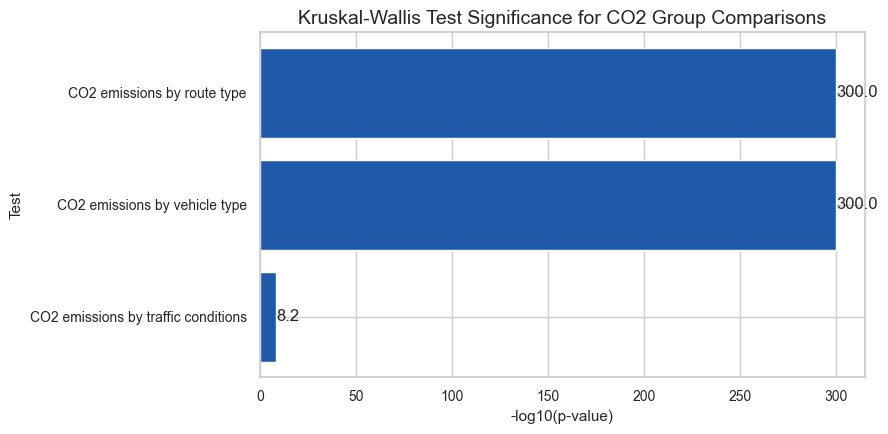

In [244]:
# Kruskal-Wallis significance chart

kruskal_chart = kruskal_test_summary.copy()
kruskal_chart["neg_log10_p_value"] = -np.log10(kruskal_chart["p_value"].clip(lower=1e-300))
kruskal_chart = kruskal_chart.sort_values("neg_log10_p_value")

plt.figure(figsize=(9, 4.5))

bars = plt.barh(
    kruskal_chart["test"],
    kruskal_chart["neg_log10_p_value"],
    color=project_palette["blue"]
)

plt.title("Kruskal-Wallis Test Significance for CO2 Group Comparisons")
plt.xlabel("-log10(p-value)")
plt.ylabel("Test")

for bar, value in zip(bars, kruskal_chart["neg_log10_p_value"]):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Kruskal-Wallis significance chart observation

All three Kruskal-Wallis tests show very strong statistical significance.

This means that CO2 emissions are not distributed in the same way across vehicle types, route types and traffic conditions.

For the final presentation, this is useful because it shows that the sustainability differences seen in the charts are not only visual patterns; they are also statistically supported.

### 6.5.2 IQR outlier check

In this step, I use the IQR method to check outliers in the most important numerical variables.

This is useful because logistics data often includes extreme values.  
Outliers can affect averages, normalization and final scores.

I check outliers for:

- optimized route time
- optimized route cost
- carbon emissions
- delivery efficiency score
- final Delivery Option Score

The goal is not to remove these values automatically.  
The goal is to understand where extreme values exist and how they may affect the analysis.


In [245]:
# IQR outlier check for important project variables

def calculate_iqr_outliers(df, column_name, variable_label):
    data = df[column_name].dropna()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (data < lower_bound) |
        (data > upper_bound)
    ).sum()

    return {
        "variable": variable_label,
        "column_name": column_name,
        "records_used": len(data),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_share_pct": outlier_count / len(data) * 100
    }

iqr_outlier_summary = pd.DataFrame([
    calculate_iqr_outliers(
        route_clean,
        "optimized_route_time_min",
        "Optimized route time"
    ),
    calculate_iqr_outliers(
        route_clean,
        "optimized_route_cost",
        "Optimized route cost"
    ),
    calculate_iqr_outliers(
        carbon_clean,
        "carbon_emission_kgco2e",
        "Carbon emissions"
    ),
    calculate_iqr_outliers(
        route_clean,
        "delivery_efficiency_score",
        "Delivery efficiency score"
    ),
    calculate_iqr_outliers(
        score_df,
        "delivery_option_score",
        "Final Delivery Option Score"
    )
])

display_styled_table(
    iqr_outlier_summary,
    caption="IQR Outlier Summary",
    format_dict={
        "q1": "{:.2f}",
        "q3": "{:.2f}",
        "iqr": "{:.2f}",
        "lower_bound": "{:.2f}",
        "upper_bound": "{:.2f}",
        "outlier_share_pct": "{:.2f}%"
    }
)

variable,column_name,records_used,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_share_pct
Optimized route time,optimized_route_time_min,1000,28.34,99.07,70.74,-77.77,205.18,62,6.20%
Optimized route cost,optimized_route_cost,1000,255.31,776.88,521.56,-527.02,1559.21,24,2.40%
Carbon emissions,carbon_emission_kgco2e,12000,0.09,24.09,24.00,-35.90,60.09,1702,14.18%
Delivery efficiency score,delivery_efficiency_score,1000,0.02,0.08,0.06,-0.08,0.18,113,11.30%
Final Delivery Option Score,delivery_option_score,1000,51.02,71.22,20.19,20.74,101.50,1,0.10%


,variable,column_name,records_used,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_share_pct
0,Optimized route time,optimized_route_time_min,1000,28.337500,99.072500,70.735000,-77.765000,205.175000,62,6.200000
1,Optimized route cost,optimized_route_cost,1000,255.315000,776.875000,521.560000,-527.025000,1559.215000,24,2.400000
2,Carbon emissions,carbon_emission_kgco2e,12000,0.093000,24.091250,23.998250,-35.904375,60.088625,1702,14.183333
3,Delivery efficiency score,delivery_efficiency_score,1000,0.020100,0.083900,0.063800,-0.075600,0.179600,113,11.300000
4,Final Delivery Option Score,delivery_option_score,1000,51.023608,71.215252,20.191643,20.736143,101.502717,1,0.100000


### IQR outlier check table observation

The IQR table shows which variables are most affected by extreme values.

Carbon emissions have the highest outlier share, around 14.18%.  
This matches the earlier EDA, where a small number of high-emission deliveries increased the average.

Delivery efficiency also has a meaningful outlier share, around 11.30%.

Optimized route time and optimized route cost have fewer outliers.

The final Delivery Option Score has almost no outlier problem, around 0.10%.  
This means the final score is much more stable than some of the original input variables.


### Outlier share by variable

To make the outlier check easier to present, I also compare the outlier share of the main variables in one chart.

This gives a simple visual summary of which variables are more affected by extreme values.

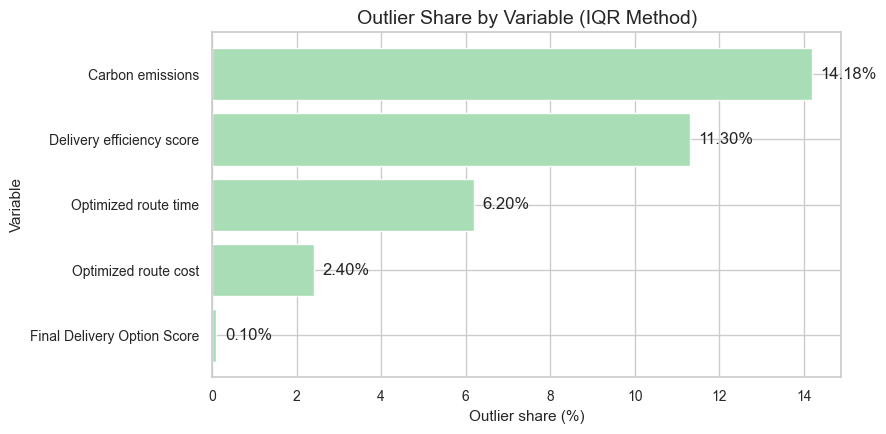

In [246]:
# Outlier share by variable chart

iqr_chart = iqr_outlier_summary.copy()
iqr_chart = iqr_chart.sort_values("outlier_share_pct")

plt.figure(figsize=(9, 4.5))

bars = plt.barh(
    iqr_chart["variable"],
    iqr_chart["outlier_share_pct"],
    color=project_palette["light_green"]
)

plt.title("Outlier Share by Variable (IQR Method)")
plt.xlabel("Outlier share (%)")
plt.ylabel("Variable")

for bar, value in zip(bars, iqr_chart["outlier_share_pct"]):
    plt.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### Outlier share by variable observation

The outlier share chart makes the IQR results easier to compare.

Carbon emissions and delivery efficiency are clearly the most affected by extreme values.

This is important because these two variables need careful interpretation in the project.  
For example, high-emission deliveries can increase the average CO2 value, and extreme efficiency values can affect min-max normalization.

This also helps explain why the normalized efficiency score is lower than the other component scores.

The final Delivery Option Score has almost no outlier problem.  
This is a good sign because the final score combines several components instead of depending on one extreme variable.

This chart is useful for presentation because it shows that the analysis considered data quality and distribution issues, not only average values.


### 6.5.3 Score category component profile

In this step, I compare the average component scores by final score category.

This helps explain what makes a route `Low`, `Average`, `Good`, `Very good` or `Excellent`.


In [247]:
# Score category component profile

score_component_columns = [
    "time_score",
    "cost_score",
    "co2_score",
    "reliability_score",
    "traffic_score",
    "efficiency_score"
]

score_category_order = [
    "Low",
    "Average",
    "Good",
    "Very good",
    "Excellent"
]

score_category_component_profile = (
    score_df
    .groupby("score_category")[score_component_columns]
    .mean()
    .reindex(score_category_order)
)

display_styled_table(
    score_category_component_profile.reset_index(),
    caption="Score Category Component Profile",
    format_dict={
        "time_score": "{:.1f}",
        "cost_score": "{:.1f}",
        "co2_score": "{:.1f}",
        "reliability_score": "{:.1f}",
        "traffic_score": "{:.1f}",
        "efficiency_score": "{:.1f}"
    }
)

score_category,time_score,cost_score,co2_score,reliability_score,traffic_score,efficiency_score
Low,46.9,60.0,11.8,32.4,21.6,0.9
Average,75.6,77.0,29.4,46.0,41.3,2.4
Good,89.0,88.9,62.4,53.0,53.3,6.3
Very good,96.0,95.8,84.9,65.5,68.0,19.2
Excellent,98.2,98.8,95.9,87.2,91.1,29.4


,score_category,time_score,cost_score,co2_score,reliability_score,traffic_score,efficiency_score
0,Low,46.943489,59.972426,11.790983,32.388691,21.649201,0.909038
1,Average,75.612024,76.978373,29.365968,45.991027,41.298008,2.362714
2,Good,88.975151,88.905810,62.432280,52.971904,53.347165,6.347767
3,Very good,95.970984,95.848693,84.907909,65.540960,68.039151,19.229010
4,Excellent,98.171917,98.770567,95.850228,87.150084,91.107497,29.414535


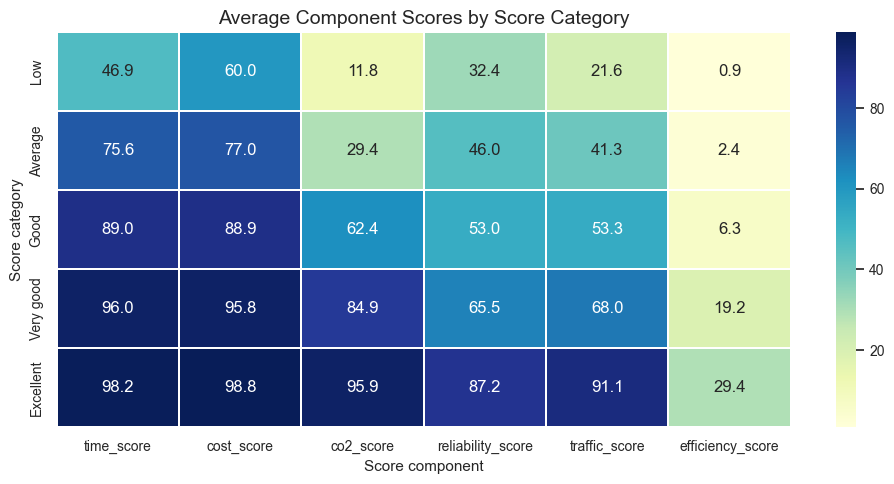

In [248]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    score_category_component_profile,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Average Component Scores by Score Category")
plt.xlabel("Score component")
plt.ylabel("Score category")

plt.tight_layout()
plt.show()


### Score category component profile heatmap observation

The heatmap shows a clear progression from `Low` to `Excellent`.

`Excellent` routes have very strong average scores in time, cost, CO2, reliability and traffic.  
For example, the `Excellent` category has average time, cost and CO2 scores above 95.

The `Low` category has much weaker component scores, especially for CO2, reliability and traffic.

The efficiency score is lower across all categories compared with the other components.  
This is consistent with the earlier outlier and normalization analysis, where the efficiency variable was sensitive to extreme values.

This visualization is useful because it explains why only a small number of routes reach the `Excellent` category.  
A route needs to perform well across several components, not only one.


### 6.5.4 CO2 interaction by vehicle type and traffic condition

In this step, I use a heatmap to compare average CO2 emissions by vehicle type and traffic condition.

This adds an interaction view: instead of looking only at vehicle type or traffic condition separately, I compare them together.


In [249]:
# CO2 interaction by vehicle type and traffic condition

traffic_condition_order = [
    "Low",
    "Normal",
    "High",
    "Severe Congestion"
]

co2_by_vehicle_traffic = (
    carbon_clean
    .pivot_table(
        index="vehicle_type",
        columns="traffic_conditions",
        values="carbon_emission_kgco2e",
        aggfunc="mean"
    )
    .reindex(columns=traffic_condition_order)
)

display_styled_table(
    co2_by_vehicle_traffic.reset_index(),
    caption="Average CO2 by Vehicle Type and Traffic Condition",
    format_dict={
        "Low": "{:.1f}",
        "Normal": "{:.1f}",
        "High": "{:.1f}",
        "Severe Congestion": "{:.1f}"
    }
)

vehicle_type,Low,Normal,High,Severe Congestion
Cargo Bicycle,0.0,0.0,0.0,0.0
Diesel Van (Euro 4),20.6,22.6,30.5,36.1
Diesel Van (Euro 6),14.0,15.3,19.3,24.7
Drone Delivery,0.1,0.1,0.1,0.1
Electric Van (EV),3.7,4.0,4.1,4.5
Heavy Truck,372.2,398.3,539.2,633.2
Motorcycle (Courier),1.9,2.2,2.9,3.6


traffic_conditions,vehicle_type,Low,Normal,High,Severe Congestion
0,Cargo Bicycle,0.000000,0.000000,0.000000,0.000000
1,Diesel Van (Euro 4),20.636066,22.582230,30.511138,36.110652
2,Diesel Van (Euro 6),14.026277,15.304909,19.263423,24.682244
3,Drone Delivery,0.063294,0.063886,0.064780,0.069127
4,Electric Van (EV),3.737350,4.042253,4.133442,4.472881
5,Heavy Truck,372.217778,398.294737,539.176749,633.182104
6,Motorcycle (Courier),1.947133,2.200735,2.908322,3.621563


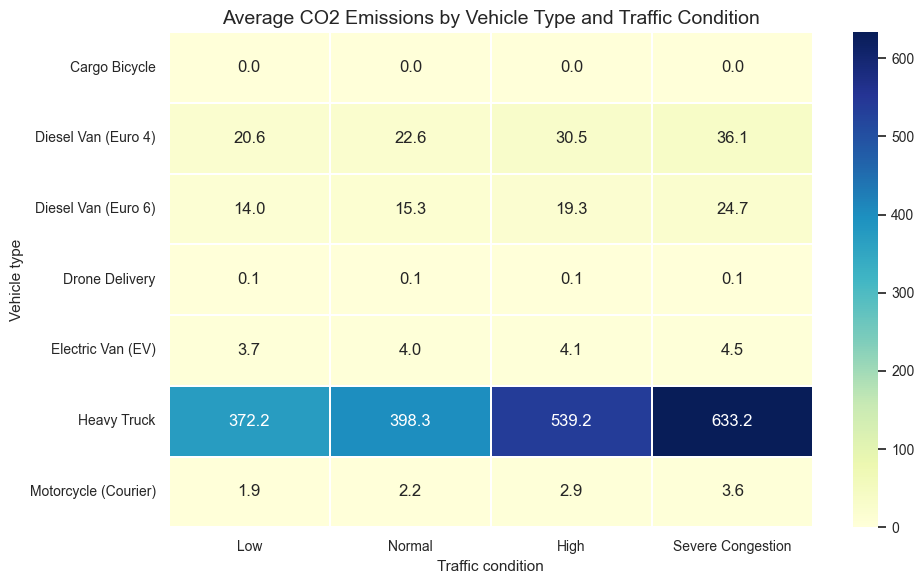

In [250]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    co2_by_vehicle_traffic,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Average CO2 Emissions by Vehicle Type and Traffic Condition")
plt.xlabel("Traffic condition")
plt.ylabel("Vehicle type")

plt.tight_layout()
plt.show()


### CO2 interaction heatmap observation

The heatmap shows that vehicle type and traffic condition both matter for CO2 emissions.

`Heavy Truck` has the highest average emissions in every traffic condition.  
Its average emissions increase from around 372.22 kgCO2e in low traffic to around 633.18 kgCO2e under severe congestion.

Diesel vans also show higher emissions under severe congestion compared with low traffic.

On the other side, cargo bicycles, drone delivery and electric vans stay much lower across all traffic conditions.

This supports the sustainability message of the project: greener vehicle types can strongly reduce emissions, and congestion can make high-emission vehicles even worse.


### 6.5.5 On-time rate by distance group

In this step, I group deliveries by transportation distance and calculate the on-time rate for each group.

This helps check whether delivery distance is connected with reliability.


In [251]:
# On-time rate by distance group

tracking_distance_status = tracking_clean.dropna(
    subset=["transportation_distance_in_km"]
).copy()

if "delivery_status_clean" not in tracking_distance_status.columns:
    tracking_distance_status["delivery_status_clean"] = np.select(
        [
            (tracking_distance_status["is_on_time"] == 1) & (tracking_distance_status["is_delayed"] == 1),
            (tracking_distance_status["is_on_time"] == 1) & (tracking_distance_status["is_delayed"] == 0),
            (tracking_distance_status["is_on_time"] == 0) & (tracking_distance_status["is_delayed"] == 1)
        ],
        [
            "Conflict",
            "On time",
            "Delayed"
        ],
        default="Unknown"
    )

tracking_distance_status["distance_group"] = pd.qcut(
    tracking_distance_status["transportation_distance_in_km"],
    q=4,
    labels=["Short", "Medium", "Long", "Very long"]
)

valid_distance_status = tracking_distance_status[
    tracking_distance_status["delivery_status_clean"].isin(["On time", "Delayed"])
].copy()

on_time_rate_by_distance_group = (
    valid_distance_status
    .groupby("distance_group", observed=True)
    .agg(
        deliveries=("bookingid", "count"),
        on_time_deliveries=("delivery_status_clean", lambda x: (x == "On time").sum()),
        delayed_deliveries=("delivery_status_clean", lambda x: (x == "Delayed").sum()),
        avg_distance_km=("transportation_distance_in_km", "mean")
    )
    .reset_index()
)

on_time_rate_by_distance_group["on_time_rate_pct"] = (
    on_time_rate_by_distance_group["on_time_deliveries"] /
    on_time_rate_by_distance_group["deliveries"] * 100
)

display_styled_table(
    on_time_rate_by_distance_group,
    caption="On-time Rate by Distance Group",
    format_dict={
        "deliveries": "{:.0f}",
        "on_time_deliveries": "{:.0f}",
        "delayed_deliveries": "{:.0f}",
        "avg_distance_km": "{:.2f}",
        "on_time_rate_pct": "{:.2f}%"
    }
)

distance_group,deliveries,on_time_deliveries,delayed_deliveries,avg_distance_km,on_time_rate_pct
Short,1613,482,1131,26.70,29.88%
Medium,1488,378,1110,82.92,25.40%
Long,1532,754,778,391.58,49.22%
Very long,1505,355,1150,1756.46,23.59%


,distance_group,deliveries,on_time_deliveries,delayed_deliveries,avg_distance_km,on_time_rate_pct
0,Short,1613,482,1131,26.696993,29.882207
1,Medium,1488,378,1110,82.918757,25.403226
2,Long,1532,754,778,391.583120,49.216710
3,Very long,1505,355,1150,1756.460133,23.588040


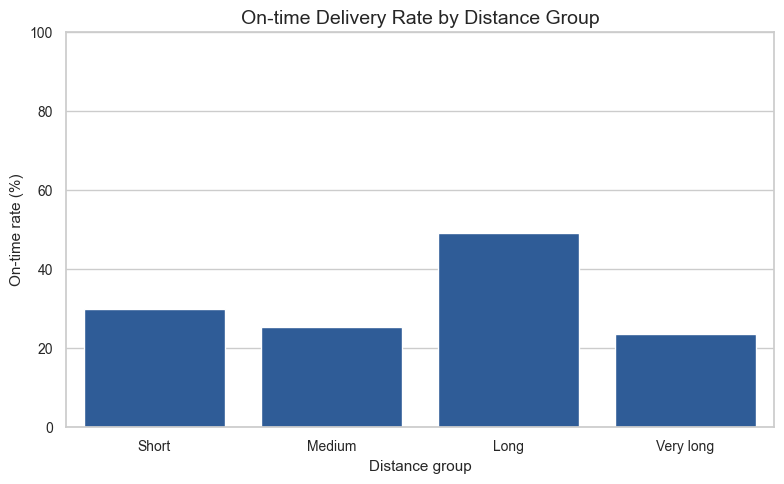

In [252]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=on_time_rate_by_distance_group,
    x="distance_group",
    y="on_time_rate_pct",
    color=project_palette["blue"]
)

plt.title("On-time Delivery Rate by Distance Group")
plt.xlabel("Distance group")
plt.ylabel("On-time rate (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()


### On-time rate by distance group observation

The on-time rate is not simply decreasing as distance increases.

The `Long` distance group has the highest on-time rate, around 49.22%.  
The `Very long` group has the lowest on-time rate, around 23.59%.

The `Short` and `Medium` groups are also relatively low, around 29.88% and 25.40%.

This shows that distance alone does not fully explain delivery reliability.  
Other factors such as route planning, traffic conditions, operation type, vehicle type and logistics process may also affect whether a delivery is on time.

This is useful for the project because it supports the use of a multi-criteria Delivery Option Score instead of relying on only one variable.


## 6.6 Presentation-ready comparative visuals

This section adds a few comparative visuals that are useful for the final presentation.

The idea is not to copy a dashboard layout.  
The goal is to use the project data to create simple comparison views that are easy to explain.

These charts compare:

- the best route against the dataset average
- different route decision priorities
- vehicle emission intensity compared with Electric Van
- remaining emissions and saved emissions in the green fleet scenario

These visuals are mainly useful for storytelling and presentation.

### 6.6.1 Best route vs dataset average

In this comparison, I compare the best-ranked route with the average route in the dataset.

I use component scores because they are already on the same 0-100 scale.

This makes the comparison fair and easier to read.

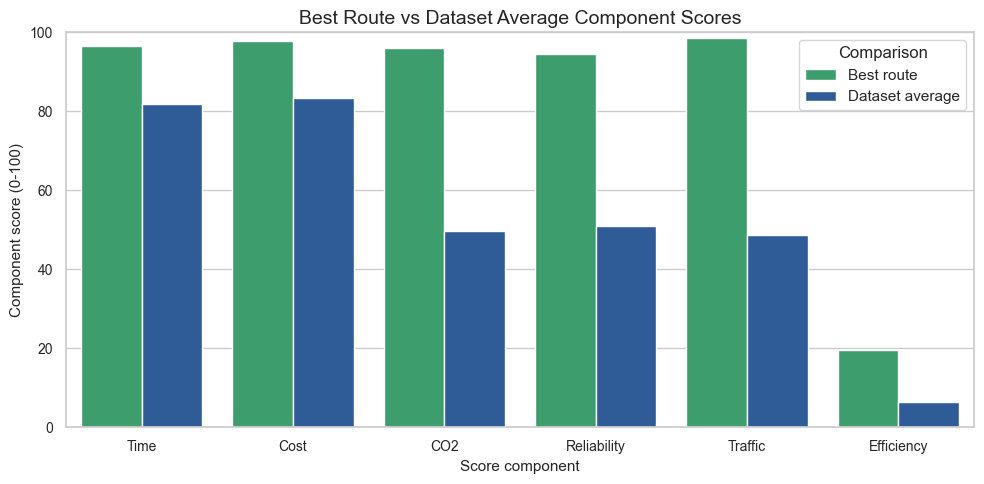

component,best_route,dataset_average
Time,96.5,81.8
Cost,97.9,83.3
CO2,96.1,49.7
Reliability,94.4,50.8
Traffic,98.5,48.8
Efficiency,19.6,6.5


,component,best_route,dataset_average
0,Time,96.527691,81.810165
1,Cost,97.881629,83.285937
2,CO2,96.093003,49.650286
3,Reliability,94.435076,50.836594
4,Traffic,98.495250,48.785873
5,Efficiency,19.634592,6.499903


In [253]:
# Best route vs dataset average component comparison

component_score_columns = [
    "time_score",
    "cost_score",
    "co2_score",
    "reliability_score",
    "traffic_score",
    "efficiency_score"
]

component_label_map = {
    "time_score": "Time",
    "cost_score": "Cost",
    "co2_score": "CO2",
    "reliability_score": "Reliability",
    "traffic_score": "Traffic",
    "efficiency_score": "Efficiency"
}

best_route_idx = score_df["delivery_option_score"].idxmax()
best_route_component_scores = score_df.loc[best_route_idx, component_score_columns]
average_component_scores = score_df[component_score_columns].mean()

best_vs_average_components = pd.DataFrame({
    "component": [component_label_map[col] for col in component_score_columns],
    "best_route": best_route_component_scores.values,
    "dataset_average": average_component_scores.values
})

best_vs_average_long = best_vs_average_components.melt(
    id_vars="component",
    value_vars=["best_route", "dataset_average"],
    var_name="comparison",
    value_name="score"
)

best_vs_average_long["comparison"] = best_vs_average_long["comparison"].map({
    "best_route": "Best route",
    "dataset_average": "Dataset average"
})

plt.figure(figsize=(10, 5))

sns.barplot(
    data=best_vs_average_long,
    x="component",
    y="score",
    hue="comparison",
    palette=[project_palette["green"], project_palette["blue"]]
)

plt.title("Best Route vs Dataset Average Component Scores")
plt.xlabel("Score component")
plt.ylabel("Component score (0-100)")
plt.ylim(0, 100)
plt.legend(title="Comparison")

plt.tight_layout()
plt.show()

display_styled_table(
    best_vs_average_components,
    caption="Best Route vs Dataset Average Component Scores",
    format_dict={
        "best_route": "{:.1f}",
        "dataset_average": "{:.1f}"
    }
)

### Best route vs average observation

The best route performs much better than the dataset average in most score components.

The strongest differences are visible in CO2, reliability and traffic.  
This helps explain why `Route option 418` has the highest final Delivery Option Score.

The efficiency score is still lower than the other components, even for the best route.  
This is consistent with the earlier outlier and normalization analysis.

This chart is useful for presentation because it shows the best route as a balanced option, not only as the fastest or cheapest one.

### 6.6.2 Decision profile comparison

In this comparison, I use the routes from the decision matrix.

The goal is to compare different decision needs, such as best overall, fastest, cheapest, lowest traffic and most reliable.

This helps show that each decision need creates a different route profile.

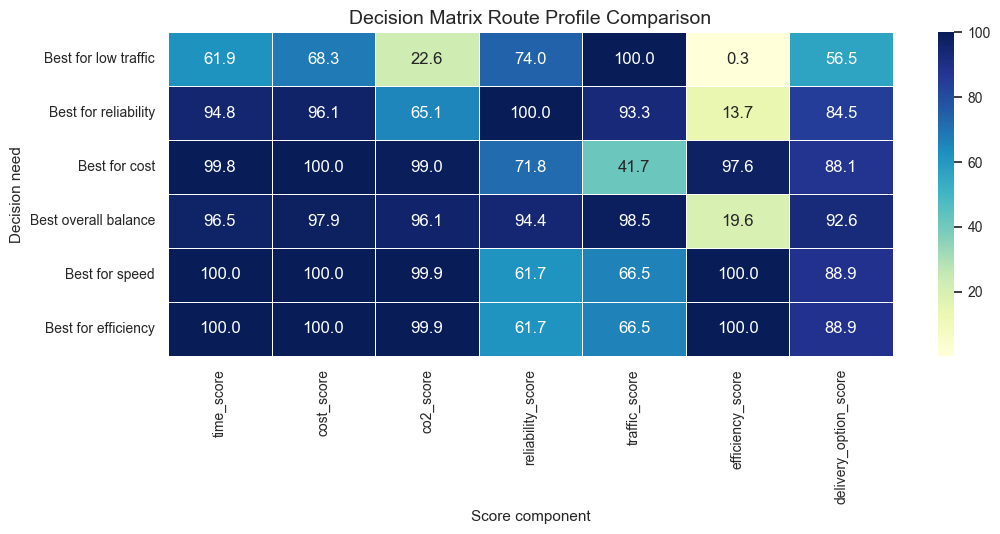

Decision need,route_label,time_score,cost_score,co2_score,reliability_score,traffic_score,efficiency_score,delivery_option_score
Best for low traffic,Route option 80,61.9,68.3,22.6,74.0,100.0,0.3,56.52
Best for reliability,Route option 158,94.8,96.1,65.1,100.0,93.3,13.7,84.48
Best for cost,Route option 350,99.8,100.0,99.0,71.8,41.7,97.6,88.12
Best overall balance,Route option 418,96.5,97.9,96.1,94.4,98.5,19.6,92.62
Best for speed,Route option 715,100.0,100.0,99.9,61.7,66.5,100.0,88.95
Best for efficiency,Route option 715,100.0,100.0,99.9,61.7,66.5,100.0,88.95


,Decision need,route_label,time_score,cost_score,co2_score,reliability_score,traffic_score,efficiency_score,delivery_option_score
0,Best for low traffic,Route option 80,61.899528,68.294860,22.630416,74.030354,100.000000,0.276086,56.516357
1,Best for reliability,Route option 158,94.796533,96.111765,65.130631,100.000000,93.346535,13.714982,84.484720
2,Best for cost,Route option 350,99.777672,100.000000,98.985823,71.838111,41.688862,97.580187,88.117508
3,Best overall balance,Route option 418,96.527691,97.881629,96.093003,94.435076,98.495250,19.634592,92.623384
4,Best for speed,Route option 715,100.000000,99.957195,99.865506,61.720067,66.453837,100.000000,88.947213
5,Best for efficiency,Route option 715,100.000000,99.957195,99.865506,61.720067,66.453837,100.000000,88.947213


In [254]:
# Decision profile heatmap

score_df_for_decision_profile = score_df.copy()
score_df_for_decision_profile["route_index"] = score_df_for_decision_profile.index
score_df_for_decision_profile["route_option_id"] = score_df_for_decision_profile["route_index"] + 1
score_df_for_decision_profile["route_label"] = (
    "Route option " + score_df_for_decision_profile["route_option_id"].astype(str)
)

decision_route_ids = route_decision_matrix["Route option ID"].astype(int).tolist()

decision_profile = (
    score_df_for_decision_profile[
        score_df_for_decision_profile["route_option_id"].isin(decision_route_ids)
    ][[
        "route_option_id",
        "route_label",
        "time_score",
        "cost_score",
        "co2_score",
        "reliability_score",
        "traffic_score",
        "efficiency_score",
        "delivery_option_score"
    ]]
    .merge(
        route_decision_matrix[["Decision need", "Route option ID"]],
        left_on="route_option_id",
        right_on="Route option ID",
        how="left"
    )
)

decision_profile = decision_profile.drop_duplicates(subset=["Decision need"]).copy()

decision_profile_heatmap = decision_profile.set_index("Decision need")[
    [
        "time_score",
        "cost_score",
        "co2_score",
        "reliability_score",
        "traffic_score",
        "efficiency_score",
        "delivery_option_score"
    ]
]

plt.figure(figsize=(11, 5.5))

sns.heatmap(
    decision_profile_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.4
)

plt.title("Decision Matrix Route Profile Comparison")
plt.xlabel("Score component")
plt.ylabel("Decision need")

plt.tight_layout()
plt.show()

display_styled_table(
    decision_profile[[
        "Decision need",
        "route_label",
        "time_score",
        "cost_score",
        "co2_score",
        "reliability_score",
        "traffic_score",
        "efficiency_score",
        "delivery_option_score"
    ]],
    caption="Decision Profile Comparison Table",
    max_rows=10,
    format_dict={
        "time_score": "{:.1f}",
        "cost_score": "{:.1f}",
        "co2_score": "{:.1f}",
        "reliability_score": "{:.1f}",
        "traffic_score": "{:.1f}",
        "efficiency_score": "{:.1f}",
        "delivery_option_score": "{:.2f}"
    }
)

### Decision profile comparison observation

The heatmap shows that each decision need has a different route profile.

The best overall route has strong scores across several components at the same time.  
The fastest route performs very well in time, but it is not automatically the best in every component.

The low-traffic route has a strong traffic profile, but its final score is lower because other components are weaker.

This supports the main idea of the project: route selection should depend on several criteria, not only one priority.

### 6.6.3 Vehicle emission gap compared with Electric Van

In this comparison, I use Electric Van as a reference point.

The goal is to show how much higher or lower each vehicle type is compared with Electric Van in terms of CO2 emission intensity.

This makes the sustainability difference between vehicle types easier to explain.

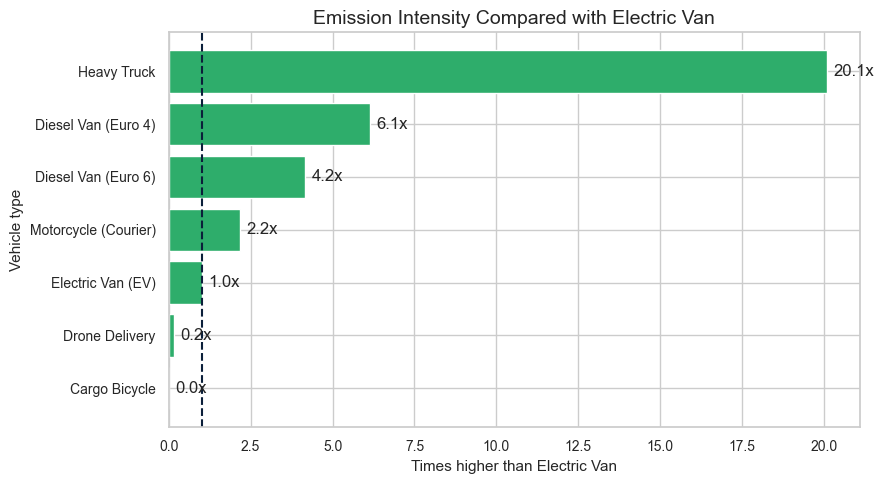

vehicle_type,avg_emission_intensity_kgco2e_per_km,times_vs_electric_van
Cargo Bicycle,0.000,0.0x
Drone Delivery,0.008,0.2x
Electric Van (EV),0.052,1.0x
Motorcycle (Courier),0.112,2.2x
Diesel Van (Euro 6),0.215,4.2x
Diesel Van (Euro 4),0.317,6.1x
Heavy Truck,1.035,20.1x


,vehicle_type,avg_emission_intensity_kgco2e_per_km,times_vs_electric_van
0,Cargo Bicycle,0.000000,0.000000
3,Drone Delivery,0.008221,0.159525
4,Electric Van (EV),0.051534,1.000000
6,Motorcycle (Courier),0.112014,2.173570
2,Diesel Van (Euro 6),0.214802,4.168130
1,Diesel Van (Euro 4),0.316825,6.147830
5,Heavy Truck,1.035397,20.091340


In [255]:
# Vehicle emission intensity gap compared with Electric Van

vehicle_emission_gap = emission_intensity_by_vehicle.copy()

ev_intensity = vehicle_emission_gap.loc[
    vehicle_emission_gap["vehicle_type"] == "Electric Van (EV)",
    "avg_emission_intensity_kgco2e_per_km"
].iloc[0]

vehicle_emission_gap["times_vs_electric_van"] = (
    vehicle_emission_gap["avg_emission_intensity_kgco2e_per_km"] / ev_intensity
)

vehicle_emission_gap = vehicle_emission_gap.sort_values("times_vs_electric_van")

plt.figure(figsize=(9, 5))

bars = plt.barh(
    vehicle_emission_gap["vehicle_type"],
    vehicle_emission_gap["times_vs_electric_van"],
    color=project_palette["green"]
)

plt.axvline(1, color=project_palette["navy"], linestyle="--", linewidth=1.5)
plt.title("Emission Intensity Compared with Electric Van")
plt.xlabel("Times higher than Electric Van")
plt.ylabel("Vehicle type")

for bar, value in zip(bars, vehicle_emission_gap["times_vs_electric_van"]):
    plt.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}x",
        va="center"
    )

plt.tight_layout()
plt.show()

display_styled_table(
    vehicle_emission_gap[[
        "vehicle_type",
        "avg_emission_intensity_kgco2e_per_km",
        "times_vs_electric_van"
    ]],
    caption="Vehicle Emission Intensity Gap Compared with Electric Van",
    max_rows=10,
    format_dict={
        "avg_emission_intensity_kgco2e_per_km": "{:.3f}",
        "times_vs_electric_van": "{:.1f}x"
    }
)

### Vehicle emission gap observation

This chart compares each vehicle type with Electric Van.

Heavy Truck has much higher emission intensity than Electric Van.  
Diesel vans are also clearly higher than Electric Van, especially Diesel Van Euro 4.

Cargo Bicycle and Drone Delivery stay below the Electric Van reference line.

This chart is useful for presentation because it makes the sustainability gap very easy to see.  
It also supports the green fleet scenario, where replacing diesel trips with electric vans creates a large estimated CO2 saving.

### 6.6.4 Green fleet saving split

In this comparison, I separate the green fleet scenario into two parts:

- estimated emissions that remain after switching to Electric Van
- estimated emissions saved by the switch

This gives a clearer view of the potential impact of the scenario.

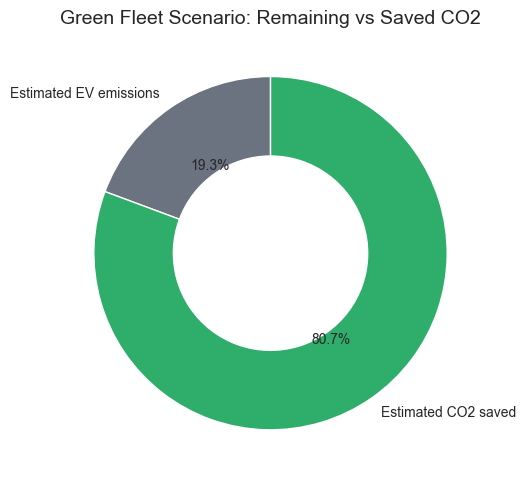

component,kgco2e
Estimated EV emissions,"7,229.67"
Estimated CO2 saved,"30,167.33"


,component,kgco2e
0,Estimated EV emissions,7229.667875
1,Estimated CO2 saved,30167.326625


In [256]:
# Green fleet saving split chart

try:
    green_fleet_transition_scenario = green_fleet_scenario.copy()
except NameError:
    green_fleet_transition_scenario = pd.read_csv(
        OUTPUT_DIR / "green_fleet_transition_scenario.csv"
    )

scenario_row = green_fleet_transition_scenario.iloc[0]

green_saving_split = pd.DataFrame({
    "component": ["Estimated EV emissions", "Estimated CO2 saved"],
    "kgco2e": [
        scenario_row["estimated_ev_emissions_kgco2e"],
        scenario_row["estimated_co2_saved_kgco2e"]
    ]
})

plt.figure(figsize=(7, 5))

plt.pie(
    green_saving_split["kgco2e"],
    labels=green_saving_split["component"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        project_palette["gray"],
        project_palette["green"]
    ],
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 10
    }
)

plt.title("Green Fleet Scenario: Remaining vs Saved CO2")
plt.tight_layout()
plt.show()

display_styled_table(
    green_saving_split,
    caption="Green Fleet Scenario: Remaining vs Saved CO2",
    format_dict={
        "kgco2e": "{:,.2f}"
    }
)

### Green fleet saving split observation

The donut chart shows that most of the affected emissions are saved in this simplified scenario.

The estimated CO2 saving represents around 80.67% of the emissions from the replaced diesel trips.

The table below the chart keeps the exact values visible, so the visual message and the numerical result can be checked together.

This is a strong visual message for the presentation.  
However, it should still be explained as an educational estimate, not as a real operational simulation.

### 6.6.5 Green fleet transition curve

To make the green fleet scenario easier to present, I also create an interactive line chart.

Instead of showing only one scenario, this chart shows what happens when the replacement share increases from 0% to 100%.

This is useful because it shows the direction of change: as more Diesel Van trips are replaced by Electric Van trips, estimated remaining emissions decrease and estimated CO2 savings increase.

In [257]:
# Interactive green fleet transition curve

try:
    green_fleet_transition_scenario = green_fleet_scenario.copy()
except NameError:
    green_fleet_transition_scenario = pd.read_csv(
        OUTPUT_DIR / "green_fleet_transition_scenario.csv"
    )

scenario_row = green_fleet_transition_scenario.iloc[0]

base_replacement_share = scenario_row["replacement_share_pct"] / 100

total_diesel_emissions = (
    scenario_row["current_emissions_for_replaced_trips_kgco2e"] / base_replacement_share
)

total_ev_emissions = (
    scenario_row["estimated_ev_emissions_kgco2e"] / base_replacement_share
)

replacement_shares = [0, 25, 50, 75, 100]

green_fleet_curve = pd.DataFrame({
    "replacement_share_pct": replacement_shares
})

green_fleet_curve["estimated_remaining_emissions_kgco2e"] = (
    total_diesel_emissions * (1 - green_fleet_curve["replacement_share_pct"] / 100)
    + total_ev_emissions * (green_fleet_curve["replacement_share_pct"] / 100)
)

green_fleet_curve["estimated_co2_saved_kgco2e"] = (
    total_diesel_emissions - green_fleet_curve["estimated_remaining_emissions_kgco2e"]
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=green_fleet_curve["replacement_share_pct"],
        y=green_fleet_curve["estimated_remaining_emissions_kgco2e"],
        mode="lines+markers",
        name="Remaining emissions",
        line=dict(color=project_palette["blue"], width=3),
        marker=dict(size=9),
        hovertemplate=(
            "Replacement share: %{x}%<br>"
            "Remaining emissions: %{y:,.0f} kgCO2e"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=green_fleet_curve["replacement_share_pct"],
        y=green_fleet_curve["estimated_co2_saved_kgco2e"],
        mode="lines+markers",
        name="CO2 saved",
        line=dict(color=project_palette["green"], width=3),
        marker=dict(size=9),
        hovertemplate=(
            "Replacement share: %{x}%<br>"
            "CO2 saved: %{y:,.0f} kgCO2e"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title=dict(
        text="Green Fleet Transition Curve",
        x=0.02,
        xanchor="left"
    ),
    width=900,
    height=500,
    template="plotly_white",
    hovermode="x unified",
    margin=dict(l=80, r=40, t=70, b=80),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    xaxis=dict(
        title="Diesel Van trips replaced by Electric Van (%)",
        tickmode="array",
        tickvals=[0, 25, 50, 75, 100],
        range=[-5, 105]
    ),
    yaxis=dict(
        title="Estimated kgCO2e",
        rangemode="tozero",
        tickformat=","
    )
)

fig.show()

display_styled_table(
    green_fleet_curve,
    caption="Green Fleet Transition Curve Data",
    format_dict={
        "replacement_share_pct": "{:.0f}%",
        "estimated_remaining_emissions_kgco2e": "{:,.2f}",
        "estimated_co2_saved_kgco2e": "{:,.2f}"
    }
)

replacement_share_pct,estimated_remaining_emissions_kgco2e,estimated_co2_saved_kgco2e
0%,"74,793.99",0.00
25%,"59,710.33","15,083.66"
50%,"44,626.66","30,167.33"
75%,"29,543.00","45,250.99"
100%,"14,459.34","60,334.65"


,replacement_share_pct,estimated_remaining_emissions_kgco2e,estimated_co2_saved_kgco2e
0,0,74793.989000,0.000000
1,25,59710.325687,15083.663313
2,50,44626.662375,30167.326625
3,75,29542.999062,45250.989938
4,100,14459.335750,60334.653250


### Green fleet transition curve observation

The interactive line chart shows how the green fleet scenario changes as the replacement share increases from 0% to 100%.

As more Diesel Van trips are replaced by Electric Van trips, estimated remaining emissions decrease and estimated CO2 savings increase.

At 50% replacement, the model estimates around 30,167.33 kgCO2e saved.  
This matches the green fleet scenario calculated earlier.

The interactive version is useful because the exact values can be checked by moving over each point.

This chart is also useful for presentation because it shows the scenario as a direction of change, not only as one isolated number.

## 6.7 Save additional improvement outputs

In this step, I save the additional tables created in the final improvement section.  
These files can be used later for the README, presentation or dashboard.


In [258]:
# Save additional outputs

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

barcelona_valid_status_summary.to_csv(
    OUTPUT_DIR / "barcelona_trams_valid_status_summary.csv",
    index=False
)

barcelona_monthly_valid_summary.to_csv(
    OUTPUT_DIR / "barcelona_trams_monthly_valid_summary.csv",
    index=False
)

emission_intensity_by_vehicle.to_csv(
    OUTPUT_DIR / "emission_intensity_by_vehicle.csv",
    index=False
)

green_fleet_scenario.to_csv(
    OUTPUT_DIR / "green_fleet_transition_scenario.csv",
    index=False
)

congestion_impact_summary.to_csv(
    OUTPUT_DIR / "congestion_impact_summary.csv",
    index=False
)

statistical_relationship_checks.to_csv(
    OUTPUT_DIR / "statistical_relationship_checks.csv",
    index=False
)

kruskal_test_summary.to_csv(
    OUTPUT_DIR / "kruskal_test_summary.csv",
    index=False
)

iqr_outlier_summary.to_csv(
    OUTPUT_DIR / "iqr_outlier_summary.csv",
    index=False
)

score_category_component_profile.reset_index().to_csv(
    OUTPUT_DIR / "score_category_component_profile.csv",
    index=False
)

co2_by_vehicle_traffic.reset_index().to_csv(
    OUTPUT_DIR / "co2_by_vehicle_traffic.csv",
    index=False
)

on_time_rate_by_distance_group.to_csv(
    OUTPUT_DIR / "on_time_rate_by_distance_group.csv",
    index=False
)

print("Additional improvement outputs saved successfully in: data/outputs")


Additional improvement outputs saved successfully in: data/outputs


### Saved additional outputs summary

In this step, I create a small summary table of the additional output files saved in section 6.

This makes the notebook easier to understand because it shows what each output file contains and how it can be used later.

These files can be used for the README, the final presentation, or a future dashboard.

In [259]:
# Saved additional outputs summary

output_files_info = [
    {
        "file_name": "barcelona_trams_valid_status_summary.csv",
        "description": "Valid Barcelona TRAMS traffic status distribution after excluding No data",
        "used_for": "Traffic context"
    },
    {
        "file_name": "barcelona_trams_monthly_valid_summary.csv",
        "description": "Monthly valid traffic summary and high congestion share",
        "used_for": "Traffic trend"
    },
    {
        "file_name": "emission_intensity_by_vehicle.csv",
        "description": "Average CO2 emissions per kilometre by vehicle type",
        "used_for": "Sustainability comparison"
    },
    {
        "file_name": "green_fleet_transition_scenario.csv",
        "description": "Estimated CO2 saving from replacing part of Diesel Van trips with Electric Van trips",
        "used_for": "Green fleet scenario"
    },
    {
        "file_name": "congestion_impact_summary.csv",
        "description": "Average congestion delay by city",
        "used_for": "Congestion impact"
    },
    {
        "file_name": "statistical_relationship_checks.csv",
        "description": "Spearman correlation checks for key numerical relationships",
        "used_for": "Statistical validation"
    },
    {
        "file_name": "kruskal_test_summary.csv",
        "description": "Kruskal-Wallis tests for CO2 differences across groups",
        "used_for": "Statistical validation"
    },
    {
        "file_name": "iqr_outlier_summary.csv",
        "description": "IQR outlier summary for important numerical variables",
        "used_for": "Data quality validation"
    },
    {
        "file_name": "score_category_component_profile.csv",
        "description": "Average component scores by Delivery Option Score category",
        "used_for": "Score explanation"
    },
    {
        "file_name": "co2_by_vehicle_traffic.csv",
        "description": "Average CO2 emissions by vehicle type and traffic condition",
        "used_for": "CO2 interaction analysis"
    },
    {
        "file_name": "on_time_rate_by_distance_group.csv",
        "description": "On-time delivery rate by distance group",
        "used_for": "Reliability analysis"
    }
]

outputs_summary = []

for file_info in output_files_info:
    file_path = OUTPUT_DIR / file_info["file_name"]

    if file_path.exists():
        temp_df = pd.read_csv(file_path)
        rows = temp_df.shape[0]
        columns = temp_df.shape[1]
        status = "Saved"
    else:
        rows = None
        columns = None
        status = "Missing"

    outputs_summary.append({
        "file_name": file_info["file_name"],
        "status": status,
        "rows": rows,
        "columns": columns,
        "description": file_info["description"],
        "used_for": file_info["used_for"]
    })

outputs_summary_df = pd.DataFrame(outputs_summary)

display_styled_table(
    outputs_summary_df,
    caption="Saved Additional Outputs Summary",
    max_rows=20
)

file_name,status,rows,columns,description,used_for
barcelona_trams_valid_status_summary.csv,Saved,6,3,Valid Barcelona TRAMS traffic status distribution after excluding No data,Traffic context
barcelona_trams_monthly_valid_summary.csv,Saved,6,6,Monthly valid traffic summary and high congestion share,Traffic trend
emission_intensity_by_vehicle.csv,Saved,7,6,Average CO2 emissions per kilometre by vehicle type,Sustainability comparison
green_fleet_transition_scenario.csv,Saved,1,7,Estimated CO2 saving from replacing part of Diesel Van trips with Electric Van trips,Green fleet scenario
congestion_impact_summary.csv,Saved,2,5,Average congestion delay by city,Congestion impact
statistical_relationship_checks.csv,Saved,6,6,Spearman correlation checks for key numerical relationships,Statistical validation
kruskal_test_summary.csv,Saved,3,6,Kruskal-Wallis tests for CO2 differences across groups,Statistical validation
iqr_outlier_summary.csv,Saved,5,10,IQR outlier summary for important numerical variables,Data quality validation
score_category_component_profile.csv,Saved,5,7,Average component scores by Delivery Option Score category,Score explanation
co2_by_vehicle_traffic.csv,Saved,7,5,Average CO2 emissions by vehicle type and traffic condition,CO2 interaction analysis


,file_name,status,rows,columns,description,used_for
0,barcelona_trams_valid_status_summary.csv,Saved,6,3,Valid Barcelona TRAMS traffic status distribut...,Traffic context
1,barcelona_trams_monthly_valid_summary.csv,Saved,6,6,Monthly valid traffic summary and high congest...,Traffic trend
2,emission_intensity_by_vehicle.csv,Saved,7,6,Average CO2 emissions per kilometre by vehicle...,Sustainability comparison
3,green_fleet_transition_scenario.csv,Saved,1,7,Estimated CO2 saving from replacing part of Di...,Green fleet scenario
4,congestion_impact_summary.csv,Saved,2,5,Average congestion delay by city,Congestion impact
5,statistical_relationship_checks.csv,Saved,6,6,Spearman correlation checks for key numerical ...,Statistical validation
6,kruskal_test_summary.csv,Saved,3,6,Kruskal-Wallis tests for CO2 differences acros...,Statistical validation
7,iqr_outlier_summary.csv,Saved,5,10,IQR outlier summary for important numerical va...,Data quality validation
8,score_category_component_profile.csv,Saved,5,7,Average component scores by Delivery Option Sc...,Score explanation
9,co2_by_vehicle_traffic.csv,Saved,7,5,Average CO2 emissions by vehicle type and traf...,CO2 interaction analysis


### Saved outputs observation

The saved outputs summarize the additional analysis created in section 6.

These files are not raw datasets.  
They are processed outputs that can be reused in the README, final presentation or a future dashboard.

The most important outputs for presentation are:

- `emission_intensity_by_vehicle.csv`
- `green_fleet_transition_scenario.csv`
- `congestion_impact_summary.csv`
- `statistical_relationship_checks.csv`
- `score_category_component_profile.csv`
- `co2_by_vehicle_traffic.csv`

This makes the final project more organized because the main analytical results are saved outside the notebook as reusable CSV files.

## 6.8 Final conclusions

This project analyzes sustainable e-commerce route planning using multiple public datasets.

The main conclusion is that delivery decisions should not be based on one metric only.

A good delivery option should balance:

- delivery time
- cost
- traffic conditions
- route reliability
- CO2 emissions
- operational efficiency

The project first explored and cleaned the data, then used EDA to understand the main patterns.  
After that, KPI tables and KPI visualizations were created to summarize operational, sustainability, reliability and traffic indicators.

The Delivery Option Score created in this notebook is a simplified educational model.  
It helps compare delivery options in a clear way, but it is not a production route optimization algorithm.

The best overall route is `Route option 418`, with a Delivery Option Score of 92.62.  
This route performs well because it balances time, cost, estimated CO2, reliability and traffic.

The final improvement section adds more context to the project:

1. Barcelona TRAMS traffic status is interpreted more accurately by excluding `No data`.
2. CO2 emission intensity is calculated per kilometre.
3. A simple green fleet transition scenario estimates the potential impact of replacing part of Diesel Van trips with Electric Van trips.
4. A congestion impact analysis shows how traffic can increase delivery time.
5. Statistical and visual validation checks the most important relationships in the project.
6. Presentation-ready comparative visuals make the main results easier to explain.

The strongest project outputs are:

1. A clean route planning analysis for time, cost, traffic and reliability.
2. A carbon footprint analysis by vehicle type, route type, traffic condition and distance.
3. A KPI dashboard inside the notebook.
4. A Delivery Option Score that combines operational and sustainability indicators.
5. A decision matrix that separates the fastest, cheapest, lowest-traffic, most reliable, most efficient and most balanced delivery options.
6. A final improvement section with traffic, emission intensity, fleet transition, congestion analysis, statistical validation and comparative visuals.

## 6.9 Limitations and future work

### Limitations

- The datasets come from different sources, so they are analyzed in modules instead of being merged row by row.
- The Delivery Option Score uses simplified weights for educational purposes.
- The estimated CO2 in the score is calculated using an average emission factor per kilometre.
- The carbon reduction scenario is an estimate, not a full operational simulation.
- The Barcelona TRAMS dataset is used as city-level context, not as a route-level delivery input.
- The tracking congestion comparison is based on a small supporting sheet, so it should be interpreted carefully.
- Real carrier prices, real vehicle assignments and real delivery routes are not included.
- Real-time operational constraints such as driver availability, exact vehicle capacity and live traffic routing are not included.

### Future work

Future versions of this project could include:

- Barcelona ITINERARIS data for current and predicted travel time.
- Machine learning models to predict delivery time, route cost or route reliability.
- More detailed CO2 calculation using real vehicle and energy data.
- Real carrier or logistics provider data.
- A Power BI dashboard or interactive dashboard for the final KPIs.
- An interactive decision-support tool for route recommendation.
- More advanced scenario analysis for fleet transition and carbon reduction.
- A route-level merge between traffic, delivery and emissions data if compatible data becomes available.

## 7. Final project output check

As a final technical check, I verify that the main output CSV files were saved correctly.

This check is not part of the main analysis.  
It is used to make sure that the final project outputs exist, have data, and do not contain unwanted `Unnamed` columns.

This helps keep the final notebook and output folder clean before preparing the README and GitHub version.

In [260]:
# Final project output check

required_output_files = [
    "kpi_summary.csv",
    "presentation_kpi_summary.csv",
    "route_examples.csv",
    "delivery_option_score_results.csv",
    "top_delivery_options.csv",
    "route_decision_matrix.csv",
    "barcelona_trams_valid_status_summary.csv",
    "barcelona_trams_monthly_valid_summary.csv",
    "emission_intensity_by_vehicle.csv",
    "green_fleet_transition_scenario.csv",
    "congestion_impact_summary.csv",
    "statistical_relationship_checks.csv",
    "kruskal_test_summary.csv",
    "iqr_outlier_summary.csv",
    "score_category_component_profile.csv",
    "co2_by_vehicle_traffic.csv",
    "on_time_rate_by_distance_group.csv"
]

final_output_check = []

for file_name in required_output_files:
    file_path = OUTPUT_DIR / file_name
    
    if file_path.exists():
        temp_df = pd.read_csv(file_path)
        has_unnamed_column = any(
            str(col).startswith("Unnamed") for col in temp_df.columns
        )
        
        final_output_check.append({
            "file_name": file_name,
            "status": "OK",
            "rows": temp_df.shape[0],
            "columns": temp_df.shape[1],
            "has_unnamed_column": has_unnamed_column
        })
    else:
        final_output_check.append({
            "file_name": file_name,
            "status": "Missing",
            "rows": None,
            "columns": None,
            "has_unnamed_column": None
        })

final_output_check_df = pd.DataFrame(final_output_check)

_ = display_styled_table(
    final_output_check_df,
    caption="Final Project Output Check",
    max_rows=25
)

file_name,status,rows,columns,has_unnamed_column
kpi_summary.csv,OK,36,5,False
presentation_kpi_summary.csv,OK,4,3,False
route_examples.csv,OK,3,7,False
delivery_option_score_results.csv,OK,1000,19,False
top_delivery_options.csv,OK,10,13,False
route_decision_matrix.csv,OK,6,10,False
barcelona_trams_valid_status_summary.csv,OK,6,3,False
barcelona_trams_monthly_valid_summary.csv,OK,6,6,False
emission_intensity_by_vehicle.csv,OK,7,6,False
green_fleet_transition_scenario.csv,OK,1,7,False


### Final output check observation

The final output check confirms whether the main CSV files were created correctly.

If all files have `status = OK` and `has_unnamed_column = False`, the output folder is ready for the README, presentation and GitHub cleanup.

This gives one last technical control before closing the notebook.